# Data Cleaning

In [ ]:
!pip install fuzzywuzzy

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns

## Initial Data Overview

**Tujuan**  

Tujuan tahap ini adalah memahami karakteristik dasar data mentah sebelum dilakukan transformasi atau pembersihan.
Kamu ingin tahu dulu:

- Data kamu “sehat” atau “bermasalah”?
- Apa jenis datanya (numerik, kategorikal, teks, tanggal)?
- Apakah sudah sesuai ekspektasi dari sisi format, nilai, dan ukuran?

Tahap ini penting banget agar kamu tidak asal bersihin data tanpa tahu konteksnya.

**Konsep**  

Initial Data Overview adalah proses eksplorasi awal dataset untuk mendapatkan gambaran tentang:

- Struktur Data – jumlah baris, kolom, tipe data.
- Kualitas Data – apakah ada nilai kosong, data duplikat, atau aneh.
- Distribusi Awal – nilai minimum, maksimum, rata-rata, median, dan standar deviasi.
- Konteks Semantik – apakah nilai-nilai tersebut masuk akal dengan dunia nyata (misal: umur negatif itu aneh).

**Intuisi**

Bayangkan kamu seorang dokter data.
Sebelum kasih obat (data cleaning), kamu harus periksa dulu kondisi pasiennya (Initial Overview).
Ini kayak medical check-up:

- Cek suhu badan → (cek jumlah missing)
- Cek tekanan darah → (cek outlier ekstrem)
- Cek identitas pasien → (cek tipe data dan format)

Jadi, Initial Overview bukan “perbaikan”, tapi “diagnosis” data kamu.

**Implementasi**

```python
# Cek Struktur Dataset
df.info();

# Lihat Sampel Data
df.head();
df.tail();

# Cek Statistik Deskriptif Dasar
df.describe(include = 'all');

# Cek Jumlah Nilai Unik
df.nunique();

# Cek Nilai Kosong dan Proporsinya
(df.isna().sum() / df.shape[0]) * 100 ;

# Cek Duplikasi Data
df.duplicated().sum();

# Cek Konsistensi Logika
(df['age'] < 0).sum()
(df['salary'] < df['tax']).sum()
```

**Hasil**  

Setelah tahap Initial Data Overview, kamu harus sudah tahu:
- Kolom mana yang butuh ubah tipe data
- Kolom mana yang banyak missing
- Kolom mana yang tidak konsisten
- Kolom mana yang numeriknya ekstrem (indikasi outlier)
- Apakah distribusinya normal (cek skew & kurtosis awal)

**Contoh**

In [ ]:
df = sns.load_dataset('titanic')
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


In [ ]:
missing_count = df.isna().sum() / df.shape[0] * 100
missing_count = missing_count[missing_count > 0]
missing_count

,0
age,19.865320
embarked,0.224467
deck,77.216611
embark_town,0.224467


In [ ]:
dist_df = pd.DataFrame()

dist_df['skewness'] = df.skew(numeric_only = True)
dist_df['kurtosis'] = df.kurt(numeric_only = True)
dist_df

,skewness,kurtosis
survived,0.478523,-1.775005
pclass,-0.630548,-1.280015
age,0.389108,0.178274
sibsp,3.695352,17.880420
parch,2.749117,9.778125
fare,4.787317,33.398141
adult_male,-0.420431,-1.827345
alone,-0.420431,-1.827345


In [ ]:
inconsisten_df = pd.DataFrame(columns = ['value'])

for col in df.columns :
  if df[col].nunique() < 10 :
    inconsisten_df.loc[col, 'value'] = df[col].unique().tolist()
  else :
    keterangan = f'Unique lebih dari 10 ({df[col].nunique()})'
    inconsisten_df.loc[col, 'value'] = keterangan

In [ ]:
inconsisten_df

,value
survived,"[0, 1]"
pclass,"[3, 1, 2]"
sex,"[male, female]"
age,Unique lebih dari 10 (88)
sibsp,"[1, 0, 3, 4, 2, 5, 8]"
parch,"[0, 1, 2, 5, 3, 4, 6]"
fare,Unique lebih dari 10 (248)
embarked,"[S, C, Q, nan]"
class,"[Third, First, Second]"
who,"[man, woman, child]"


## Datetime Standardization

**Tujuan**  

Tujuan dari Datetime Standardization adalah memastikan bahwa seluruh data bertipe waktu (datetime) di dataset:

- Memiliki format yang konsisten (misal semua pakai YYYY-MM-DD),
- Bertipe data datetime64[ns] (bukan object),
- Tidak mengandung kesalahan logika (contoh: tanggal pengiriman < tanggal pemesanan),
- Siap digunakan untuk analisis berbasis waktu seperti tren, lag, dan perhitungan durasi.

**Intuisi**

Kalau kamu bayangkan dataset seperti kalender besar, maka setiap baris punya “janji temu waktu” yang harus bisa dibandingkan dan dihitung.

Kalau tanggalnya masih "20/10/2025", "2025-10-20", atau "Oct 20, 2025", komputer tidak tahu itu hari yang sama.

Makanya, kita perlu “menyulap” semua format jadi satu bentuk yang numerik tapi tetap manusiawi, yaitu tipe datetime.

Setelah dikonversi, komputer bisa melakukan:

- Mengurutkan waktu secara akurat,
- Menghitung selisih durasi antar tanggal,
- Mengekstrak fitur waktu (hari, bulan, tahun, dll).

**Kode Format Waktu**  

Kode-kode ini digunakan di parameter format= pada pd.to_datetime() atau fungsi .dt.strftime().
Mereka memberi tahu Python bagaimana cara membaca / menulis format waktu.

- Tahun

  | Kode | Contoh | Arti                   |
  | :--: | :----: | :--------------------- |
  | `%Y` | `2025` | Tahun 4 digit          |
  | `%y` |  `25`  | Tahun 2 digit terakhir |

  $$ \ $$
- Bulan  

  | Kode |   Contoh  | Arti                      |
  | :--: | :-------: | :------------------------ |
  | `%m` |    `10`   | Bulan dalam angka (01–12) |
  | `%b` |   `Oct`   | Singkatan nama bulan      |
  | `%B` | `October` | Nama bulan lengkap        |
  | `%h` |   `Oct`   | Alias dari `%b`           |

  $$ \ $$
- Hari (Day / Date)  

  | Kode |   Contoh   | Arti                                            |
  | :--: | :--------: | :---------------------------------------------- |
  | `%d` |    `20`    | Hari dalam sebulan (01–31)                      |
  | `%j` |    `293`   | Hari ke-n dalam tahun (001–366)                 |
  | `%a` |    `Mon`   | Singkatan nama hari                             |
  | `%A` |  `Monday`  | Nama hari lengkap                               |
  | `%w` |     `1`    | Nomor hari dalam minggu (0 = Minggu, 6 = Sabtu) |
  | `%u` |     `1`    | Nomor hari ISO (1 = Senin, 7 = Minggu)          |
  | `%D` | `10/20/25` | Format pendek ala AS = `%m/%d/%y`               |

  $$ \ $$
- Waktu (Hour, Minute, Second)  

  | Kode |  Contoh  | Arti                       |
  | :--: | :------: | :------------------------- |
  | `%H` |   `14`   | Jam (00–23)                |
  | `%I` |   `02`   | Jam (01–12)                |
  | `%p` |   `AM`   | AM / PM                    |
  | `%M` |   `30`   | Menit (00–59)              |
  | `%S` |   `45`   | Detik (00–59)              |
  | `%f` | `123456` | Mikrodetik (000000–999999) |

  $$ \ $$
- Zona Waktu

  | Kode |  Contoh | Arti                             |
  | :--: | :-----: | :------------------------------- |
  | `%z` | `+0700` | Offset UTC                       |
  | `%Z` |  `WIB`  | Nama zona waktu (misal UTC, WIB) |

  $$ \ $$
- Kombinasi Umum  

  | Tujuan                    | Format              | Contoh                 |
  | :------------------------ | :------------------ | :--------------------- |
  | Standar ISO               | `%Y-%m-%d`          | `2025-10-20`           |
  | Format Indonesia / Eropa  | `%d/%m/%Y`          | `20/10/2025`           |
  | Format AS                 | `%m/%d/%Y`          | `10/20/2025`           |
  | Dengan waktu              | `%Y-%m-%d %H:%M:%S` | `2025-10-20 14:30:00`  |
  | Dengan AM/PM              | `%d-%b-%Y %I:%M %p` | `20-Oct-2025 02:30 PM` |
  | Format log (ISO extended) | `%Y-%m-%dT%H:%M:%S` | `2025-10-20T14:30:00`  |



**Komponen Datetime**  

- Tanggal (Date)  

  |       **Komponen**      | **Kode (Pandas / Python)** | **Contoh Nilai** | **Deskripsi**                                  |
  | --------------------- | ------------------------ | :--------------: | :--------------------------------------------- |
  |          Tahun          |         `.dt.year`         |      `2025`      | Mengambil tahun dari datetime                  |
  |          Bulan          |         `.dt.month`        |       `10`       | Mengambil bulan dalam angka (1–12)             |
  |           Hari          |          `.dt.day`         |       `20`       | Mengambil tanggal (1–31)                       |
  |  Hari ke-n dalam tahun  |       `.dt.dayofyear`      |       `293`      | Posisi hari dalam setahun                      |
  |  Hari ke-n dalam minggu |       `.dt.dayofweek`      |        `0`       | Posisi hari dalam seminggu (Senin=0, Minggu=6) |
  |        Nama hari        |      `.dt.day_name()`      |     `Monday`     | Nama lengkap hari                              |
  | Minggu ke-n dalam tahun |  `.dt.isocalendar().week`  |       `43`       | Nomor minggu ISO (1–53)                        |
  |         Kuartal         |        `.dt.quarter`       |        `4`       | Kuartal tahun (1–4)                            |
  |       Akhir bulan?      |     `.dt.is_month_end`     |      `True`      | Bernilai True jika hari terakhir bulan         |
  |       Awal bulan?       |    `.dt.is_month_start`    |      `False`     | Bernilai True jika hari pertama bulan          |
  |       Akhir tahun?      |      `.dt.is_year_end`     |      `True`      | Bernilai True jika hari terakhir tahun         |
  |       Awal tahun?       |     `.dt.is_year_start`    |      `False`     | Bernilai True jika hari pertama tahun          |

  $$ \ $$
- Waktu (Time)  

  |      **Komponen**      | **Kode (Pandas / Python)** | **Contoh Nilai** | **Deskripsi**                     |
  | :-------------------- | ------------------------ | :--------------: | :-------------------------------- |
  |      Jam (24 jam)      |         `.dt.hour`         |       `14`       | Mengambil jam (0–23)              |
  |          Menit         |        `.dt.minute`        |       `35`       | Mengambil menit (0–59)            |
  |          Detik         |        `.dt.second`        |       `50`       | Mengambil detik (0–59)            |
  |       Mikrodetik       |      `.dt.microsecond`     |     `123456`     | Mengambil mikrodetik (0–999999)   |
  |        Nanodetik       |      `.dt.nanosecond`      |        `0`       | Mengambil nanodetik (0–999999999) |
  | Waktu total dalam hari |         `.dt.time`         |    `14:35:50`    | Memberikan objek `datetime.time`  |
  |          AM/PM         |    `.dt.strftime('%p')`    |       `PM`       | Menghasilkan AM atau PM           |
  
  $$ \ $$
- Zona Waktu (Timezone)
  |         **Komponen**         |     **Kode (Pandas / Python)**    | **Contoh Nilai** | **Deskripsi**                           |
  | :-------------------------- | :------------------------------- | :--------------: | :-------------------------------------- |
  |        Nama zona waktu       |              `.dt.tz`             |  `Asia/Jakarta`  | Menampilkan zona waktu                  |
  |       Offset zona waktu      |        `.dt.strftime('%z')`       |      `+0700`     | Offset UTC                              |
  |      Konversi zona waktu     |      `.dt.tz_convert('UTC')`      |         —        | Ubah zona waktu (jika sudah punya `tz`) |
  |        Set zona waktu        | `.dt.tz_localize('Asia/Jakarta')` |         —        | Menetapkan zona waktu awal              |

  $$ \ $$
- Durasi & Interval Waktu

  |          **Komponen**          |           **Kode (Pandas / Python)**           | **Contoh Nilai** | **Deskripsi**                                              |
  | :---------------------------- | :-------------------------------------------- | :--------------: | :--------------------------------------------------------- |
  |          Selisih waktu         |       `(df['end'] - df['start']).dt.days`      |        `5`       | Menghitung selisih hari                                    |
  |          Selisih detik         | `(df['end'] - df['start']).dt.total_seconds()` |     `432000`     | Selisih dalam detik                                        |
  |        Resampling waktu        |                `.resample('D')`                |         —        | Agregasi berdasarkan periode waktu (harian, mingguan, dll) |
  |       Frekuensi sampling       |                 `.asfreq('M')`                 |         —        | Mengatur frekuensi waktu (bulanan, mingguan, dll)          |



**Implementasi**

## Handle Error / Inconsistent Data

**Konsep**

**Inkonsistensi data** adalah kondisi ketika **nilai atau format data tidak seragam** untuk hal yang sebenarnya sama.
Contohnya:

* `"Male"`, `"male"`, `"M"` → sama-sama berarti “Laki-laki”
* `"Jakrta"` dan `"Jakarta"` → maksudnya sama, tapi penulisannya beda
* `"None"`, `"NaN"`, `"0"` → bisa berarti *tidak ada data (missing)*

Inkonsistensi seperti ini membuat:

* Statistik jadi salah (kategori terpecah)
* Model bingung (anggap tiap variasi sebagai kelas baru)
* Visualisasi berantakan (kategori duplikat)


**Intuisi**


Bayangkan kamu bikin survei tentang gender:

> Ada yang isi “Male”, “male”, “M”, bahkan “m”.

Komputer bakal lihat itu **4 hal berbeda**, padahal maknanya satu.
Jadi sebelum analisis, kamu harus **“menyatukan bahasa” data** biar komputer gak bingung.

**Tujuan**

- Menyatukan representasi data yang sama.
- Menyeragamkan format (huruf, spasi, simbol).
- Mengonversi nilai salah ke bentuk standar atau `NaN`.
- Menjamin setiap kolom punya tipe dan makna yang konsisten.


**Jenis Inkonsistensi Umum**

| **Jenis Kesalahan**       | **Contoh**                                                            |
| :------------------------ | :-------------------------------------------------------------------- |
| Spasi berlebih            | `"  hello "` → `"hello"`                                              |
| Format tak seragam        | `"IT"` vs `"information_technology"`                                  |
| Penulisan tidak konsisten | `"Male"`, `"male"`, `"M"`, `"m"`                                      |
| Salah ketik (typo)        | `"Femle"`, `"FemalE"` → harusnya `"female"`                           |
| Sinonim/kependekan        | `"NY"` vs `"New York"`                                                |
| Nilai tak bermakna        | `"NA"`, `"null"`, `"None"`, `"0"` → semuanya bisa berarti **missing** |
| Huruf besar–kecil berbeda | `"Jakarta"` vs `"jakarta"`                                            |
| Tipe data campur          | `'25'` (string) vs `25` (integer)                                     |


**Solusi 1 - Removing White Spaces**

Menghapus spasi di awal/akhir string untuk mencegah nilai tampak “berbeda”.


In [ ]:
# Data
df = pd.DataFrame({'gender' : ['male', 'female', '  female  ', 'male   ']})

# Kategori Sebelum Standarisasi
before = df.gender.unique()

# Standarisasi Kategori
df['gender'] = df['gender'].str.strip()

# Kategori Setelah Standarisasi
after = df.gender.unique()

before, after

(array(['male', 'female', '  female  ', 'male   '], dtype=object),
 array(['male', 'female'], dtype=object))

**Solusi 2 - Pad Strings (Menstandarkan Panjang Kode)**

Kadang kode numerik seperti **kode pos** perlu format tetap (misalnya 2 digit).


In [ ]:
df = pd.DataFrame({'ketua' : ['Dwi', 'Agus', 'Yopie', 'Darso'],
                   'RT'    : [ 3,         9,      10,       1]})

df['RT'] = df['RT'].astype(str).str.zfill(2)
df

,ketua,RT
0,Dwi,03
1,Agus,09
2,Yopie,10
3,Darso,01


**Solusi 3 - Fix Typos & Variasi Penulisan**

Data kategorikal (gender, kota, pekerjaan, dsb) sering punya ejaan tak seragam.
Ada beberapa cara untuk menanganinya:

- Manual Mapping  
  Langsung petakan nilai lama ke bentuk standar.
- Regular Expression (Pattern Matching)  
  Cocok kalau polanya bisa ditebak.
- Fuzzy Matching (Pencocokan Hampir Sama)  
  Kalau datanya besar dan ada banyak typo acak.

In [ ]:
from fuzzywuzzy import process

df = pd.DataFrame({'gender' : ['male', 'Female', 'female', 'male', 'm', 'M']})

mapping = {
            'm'     : 'male',
            'M'     : 'male',
            'male'  : 'male',
            'fem.'  : 'female',
            'female': 'female',
            'FemalE': 'female',
            'Femle' : 'female'
}

# Manual Mapping
df['gender_mapping'] = df['gender'].str.lower().map(mapping)

# Regular Expression
df['gender_regex'] = df['gender'].str.lower().str.strip()
df['gender_regex'] = df['gender_regex'].replace(to_replace=r'^m$', value='male', regex=True)
df['gender_regex'] = df['gender_regex'].replace(to_replace=r'^f.*', value='female', regex=True)


# Fuzzy Matching
def ubah_typo(value, valid_options):
    match, score = process.extractOne(value, valid_options)
    return match if score > 80 else value

valid_genders = ['male', 'female']

df['gender_fuzzy'] = df['gender'].apply(lambda x: ubah_typo(str(x), valid_genders))
df

,gender,gender_mapping,gender_regex,gender_fuzzy
0,male,male,male,male
1,Female,female,female,female
2,female,female,female,female
3,male,male,male,male
4,m,male,male,male
5,M,male,male,male


**Solusi 4 - Fix Error Data ke NaN**

Nilai seperti `"0"`, `"NA"`, `"None"`, `"inf"` sering berarti “kosong” atau “tidak valid”.


In [ ]:
missing_vals = ['0', 'na', 'n/a', 'none', 'null', 'inf']

df.replace(missing_vals, pd.NA, inplace=True)

**Solusi 5 - Convert Tipe Data**

Supaya kolom numerik benar-benar numerik, bukan string.


In [ ]:
df = pd.DataFrame({'age' : ['1', '10', 9, '11', '0.21']})
before = df['age'].dtype

df['age'] = pd.to_numeric(df['age'], errors='coerce')
after = df['age'].dtype
before, after

(dtype('O'), dtype('float64'))

**Solusi 6 - Audit dengan Visualisasi**

Plot batang bisa bantu menemukan kategori aneh atau nilai tidak umum.

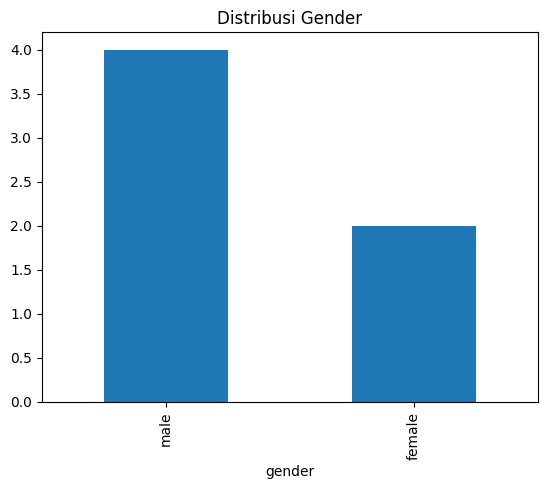

In [ ]:
df = pd.DataFrame({'gender' : ['male', 'female', 'female', 'male', 'male', 'male']})

df['gender'].value_counts().plot(kind='bar', title='Distribusi Gender') ;

**Contoh**

In [ ]:
data = {
    'Gender': ['Male', 'male', 'M', 'F', 'female', 'unknown', None],
    'City'  : ['Jakarta', 'jakrta', 'JKT', 'Bandung', 'bandung', 'Surabaya', 'None'],
    'Age'   : ['25', '30', '28', 'twenty', '40', '35', 'NaN']
}

df = pd.DataFrame(data)

# Normalisasi teks
df['Gender'] = df['Gender'].astype(str).str.strip().str.lower()
df['City'] = df['City'].astype(str).str.strip().str.lower()

# Mapping nilai
gender_map = {'male': 'Male', 'm': 'Male', 'female': 'Female', 'f': 'Female',
              'unknown': None, 'none': None, 'nan': None}
city_map = {'jakarta': 'Jakarta', 'jakrta': 'Jakarta', 'jkt': 'Jakarta',
            'bandung': 'Bandung', 'surabaya': 'Surabaya', 'none': None, 'nan': None}

df['Gender'] = df['Gender'].replace(gender_map)
df['City']   = df['City'].replace(city_map)

# Konversi numerik
df['Age'] = pd.to_numeric(df['Age'], errors='coerce')
df

,Gender,City,Age
0,Male,Jakarta,25.0
1,Male,Jakarta,30.0
2,Male,Jakarta,28.0
3,Female,Bandung,NaN
4,Female,Bandung,40.0
5,None,Surabaya,35.0
6,None,None,NaN


**Catatan**
$$ \ $$

| **Kasus**              | **Penanganan Disarankan**                                       |
| :--------------------- | :-------------------------------------------------------------- |
| Banyak kategori unik   | Gunakan `.nunique()` dan `.value_counts()` untuk audit          |
| Banyak typo acak       | Gunakan fuzzy matching                                          |
| Banyak nilai tak valid | Buat daftar `invalid_values` lalu ubah ke `NaN`                 |
| Setelah ini            | Lanjut ke **Handling Missing Value** untuk mengisi nilai kosong |

$$ \ $$
Penutup:

> Dengan penanganan inkonsistensi ini, data menjadi seragam, terstandar, dan siap untuk tahap berikutnya — baik analisis statistik, eksplorasi, maupun pemodelan machine learning.


## Normality Check (Distribution Validation)

**Tujuan**

- Mengetahui apakah suatu fitur mendekati distribusi normal (Gaussian) atau tidak.
- Menentukan metode imputasi, scaling, dan analisis statistik yang tepat.
- Mendeteksi potensi outlier atau skewness ekstrem yang bisa mengganggu model.

**Konsep**

Distribusi normal adalah bentuk data yang **simetris** terhadap nilai tengah (mean).
Sebagian besar nilai terkumpul di sekitar mean, dan semakin jauh dari mean, data makin jarang.

Visualisasinya seperti lonceng:

```
         *
       *   *
     *       *
   *           *
 *               *
----------------------------
```

Ciri-ciri utama data normal:

* Mean ≈ Median ≈ Mode
* Bentuk kurva simetris
* Skewness ≈ 0
* Kurtosis ≈ 3 (jika pakai kurtosis Pearson)

**Langkah-Langkah Pengecekan**



- **Visual Check (Grafik)**   

  Cara termudah adalah lihat bentuk distribusi.

  - **Histogram + KDE**

    ```python
    import seaborn as sns
    import matplotlib.pyplot as plt

    sns.histplot(df['feature'], kde=True)
    plt.title("Distribusi Feature")
    plt.show()
    ```

    - Kalau bentuknya lonceng simetris → mendekati normal.
    - Kalau miring ke kanan/kiri → **skewed**.  
  $$ \ $$  
  - **Q–Q Plot (Quantile-Quantile Plot)**

    Untuk cek apakah distribusi data sejajar dengan distribusi normal teoretis.

    ```python
    import scipy.stats as stats
    import matplotlib.pyplot as plt

    stats.probplot(df['feature'], dist="norm", plot=plt)
    plt.show()
    ```

    Jika titik-titik sejajar garis diagonal → data normal.
    $$ \ $$
- **Numerical Check (Ukuran Statistik)**

  - **Skewness (Kemiringan)**

    Menunjukkan arah dan tingkat ketidaksimetrian data.
    $$ \ $$
    $$
    \text{Skewness} = \frac{E[(x - \bar{x})^3]}{s^3}
    $$
    $$ \ $$

    * Skewness ≈ 0 → normal
    * Skewness > 0 → miring kanan (right-skewed)
    * Skewness < 0 → miring kiri (left-skewed)

  - **Kurtosis (Keruncingan)**

    Menunjukkan seberapa “tajam” puncak distribusi.
    $$ \ $$
    $$
    \text{Kurtosis} = \frac{E[(x - \bar{x})^4]}{s^4}
    $$
    $$ \ $$

    * Kurtosis ≈ 3 → normal
    * \> 3 → lebih runcing (leptokurtic)
    * < 3 → lebih datar (platykurtic)
    $$ \ $$  
- **Statistical Tests (Uji Normalitas)**

    Kalau mau lebih formal:

    | Nama Uji               | Fungsi Python                | Cocok untuk | Interpretasi                        |
    | ---------------------- | ---------------------------- | ----------- | ----------------------------------- |
    | **Shapiro–Wilk**       | `stats.shapiro(data)`        | n < 5000    | p > 0.05 → normal                   |
    | **Kolmogorov–Smirnov** | `stats.kstest(data, 'norm')` | umum        | p > 0.05 → normal                   |
    | **D’Agostino K²**      | `stats.normaltest(data)`     | besar       | p > 0.05 → normal                   |
    | **Anderson–Darling**   | `stats.anderson(data)`       | umum        | statistic < critical value → normal |

    



**Interpretasi**  
$$ \ $$

| Kondisi Data  | Tindakan yang Disarankan                                               |
| ------------- | ---------------------------------------------------------------------- |
| Normal        | Bisa lanjut ke imputasi mean, standard scaling, analisis parametrik    |
| Skewed Ringan | Pertimbangkan transformasi log/sqrt/Yeo-Johnson                        |
| Skewed Berat  | Gunakan median imputation, robust scaler, atau analisis non-parametrik |

**Catatan**  
* Lakukan **uji distribusi per fitur numerik**.
* Tidak semua fitur harus normal — fokus pada fitur yang ingin dianalisis dengan metode parametrik (misal regresi linear).
* Jangan lupa hilangkan **NaN** dulu sebelum uji statistik:


In [ ]:
Tambahin intuisi dong, kenapa harus pake distribusi normal. Misal banyak model statistik/ml yang dibuat dari data yang normal atau karena model mengharapkan suatu nilai pada data berasal dari percobaan banyak sekali / mendekati infinity

Ahh iya 😄 — kamu benar banget, Aldira.
Kalau kita ingat konteksnya: setelah *Handle Error / Inconsistent Data*, kamu ingin **cek distribusi (normalitas)** sebelum *Handling Missing Value* karena banyak metode imputasi (misalnya mean/median) atau scaling (misalnya standardization) **mengasumsikan data berdistribusi normal**.

Jadi ya, **Cek Distribusi / Normalitas** sangat relevan ditempatkan di situ.
Sekarang aku bantu buatin materinya ya, biar nyambung dengan alur data cleaning kamu 👇

---

## 🧮 **Cek Distribusi (Normalitas Data)**

---

### 🎯 **Tujuan**

1. Mengetahui apakah suatu fitur **mendekati distribusi normal (Gaussian)** atau tidak.
2. Menentukan **metode imputasi, scaling, dan analisis statistik** yang tepat.
3. Mendeteksi potensi **outlier atau skewness ekstrem** yang bisa mengganggu model.

---

### 🧠 **Konsep Dasar**



---

### ⚙️
---

### 2️⃣

---

### 3️⃣
---

### 🔍 **Catatan Penting**

* Lakukan **uji distribusi per fitur numerik**.
* Tidak semua fitur harus normal — fokus pada fitur yang ingin dianalisis dengan metode parametrik (misal regresi linear).
* Jangan lupa hilangkan **NaN** dulu sebelum uji statistik:

  ```python
  data = df['feature'].dropna()
  ```

---

### 🔗 **Hubungan dengan Tahap Berikutnya**

✅ Cek distribusi dilakukan **setelah Handle Error & Inkonsistensi**
✅ Hasilnya digunakan untuk menentukan:

* **Cara imputasi missing value**
* **Jenis feature scaling**
* **Transformasi variabel (misal log, sqrt, Yeo-Johnson)**

---

Kalau kamu mau, langkah berikutnya bisa lanjut ke **Handling Missing Value**, biar alurnya lengkap dari awal sampai scaling.
Mau aku teruskan ke bagian itu, Aldira?


## Handling Missing Value

**Definisi**  

Missing values adalah nilai yang hilang (kosong/Null/NaN) pada dataset. Hal ini terjadi ketika suatu observasi tidak memiliki informasi untuk satu atau lebih variabel.  

**Penyebab**

- Human error → lupa mengisi formulir, data tidak dicatat.
- Teknis → error saat input, kerusakan sistem, gangguan transmisi data.
- Non-response → responden tidak mau menjawab pertanyaan tertentu (misal: gaji).
- Keterbatasan sensor/instrumen → sensor gagal merekam nilai (contoh: suhu tidak terbaca).
- Integrasi data → perbedaan sumber data menyebabkan ada kolom yang tidak cocok.  

**Jenis**  
Bayangkan kita punya dataset dengan dua "lapisan":  
- Data Asli $\to$ nilai sebenarnya (ada yang terisi, ada yang kosong).
- Indikator Missing (apakah sebuah nilai hilang)
  - R = 1 $\to$ Ada
  - R = 0 $\to$ Hilang   

Jadi setiap data bisa kita tulis sebagai pasangan:  
- Nilai (𝑌)  
- Indikator hilang (𝑅)   

Maka kategori missing value dibagi menjadi beberapa jenis, yaitu:
- MCAR (Missing Completely At Random)  
  - Definisi Formal  
    Nilai hilang terjadi sepenuhnya acak, tidak bergantung pada variabel lain ataupun variabel itu sendiri.  
  - Matematika  
    $$P(R|Y,X) = P(R)$$
    Artinya:   
    Peluang data hilang tidak bergantung pada nilai 𝑌 maupun variabel lain 𝑋.
  - Ciri-Ciri
    - Distribusi data dengan missing dan tanpa missing sama.
    - Tidak ada bias sistematis.  
  - Intuisi  
    - Seperti kertas survei yang kehujanan → data yang hilang tidak punya pola, hanya kebetulan saja.  
    - Deteksi  
      Bandingkan distribusi data yang hilang vs yang tidak hilang → kalau sama → MCAR.
  - Tes Statistik  
    Little MCAR Test $\to$ Uji apakah rata-rata data yang missing dan non-missing punya perbedaan signifikan.
  - Dampak  
    Relatif aman → analisis masih representatif meski data hilang.  
  - Solusi  
    - Hapus data (listwise/pairwise deletion)
    - Imputasi sederhana (mean/median/mode)
      - Bisa dipakai kalau data sedikit.
      - Tidak menimbulkan
  $$ \ $$
- MAR (Missing At Random)  
  - Definisi Formal  
    Nilai hilang bergantung pada variabel lain, tapi tidak pada variabel yang hilang itu sendiri.  
  - Matematika  
    $$ P(R|Y,X) = P(R|X)$$  

    Artinya:  
    peluang hilang tergantung pada variabel lain 𝑋, tapi tidak pada nilai 𝑌 itu sendiri.
  - Ciri-ciri  
    - Missing terjadi mengikuti pola dari variabel lain.  
    - Bisa ditangani dengan imputasi menggunakan variabel lain.
  - Intuisi  
    - Responden muda lebih sering melewatkan pertanyaan gaji. Artinya, hilangnya data gaji tergantung pada usia, tapi bukan karena gaji itu sendiri.  
    - Deteksi  
      Buat indikator missing 𝑅 $\to$ Lihat apakah 𝑅 terkait dengan variabel lain 𝑋 $\to$ Kalau iya → MAR.
  - Tes Statistik  
    - Untuk variabel kategorikal → uji Chi-Square antara 𝑅 dan variabel 𝑋.
    - Untuk numerik → uji t-test/ANOVA membandingkan rata-rata variabel 𝑋 pada grup missing vs non-missing.
  - Dampak  
    Tidak sepenuhnya acak → kalau tidak diperbaiki, bisa ada bias.  
  - Solusi  
    - Imputasi berbasis model/relasi antar variabel
      - Regresi $\to$ prediksi nilai hilang pakai variabel lain (contoh: gaji diprediksi dari umur + pendidikan).
      - KNN Imputer $\to$ pakai nilai dari data tetangga terdekat.
      - MICE (Multiple Imputation by Chained Equations) $\to$ buat banyak imputasi lalu gabungkan hasilnya.  
    - Stratifikasi sebelum imputasi  
      Pisahkan kelompok dulu (misalnya berdasarkan umur), baru lakukan imputasi dalam kelompok.
    $$ \ $$
- MNAR (Missing Not At Random)
  - Definisi Formal  
    Nilai hilang bergantung pada nilai itu sendiri.
  - Matematika  
    $$ P(R|Y,X) = P(R|Y)$$  

    Artinya:     
    peluang hilang bergantung langsung pada nilai 𝑌 yang hilang itu sendiri.
  - Ciri-ciri  
    - Missing punya pola tersembunyi terkait dengan dirinya.
    - Sulit dideteksi hanya dari data → butuh asumsi domain knowledge.
  - Intuisi  
    - Orang dengan gaji tinggi sengaja tidak mau mengisi kolom gaji. Jadi, semakin tinggi gajinya, semakin besar kemungkinan data gaji hilang.  
    - Deteksi  
      - Sulit → karena nilai hilang, kita tidak tahu apa isinya!  
      - Harus pakai pengetahuan domain (contoh: "memang orang kaya sering enggan melaporkan gaji").
  - Tes Statistik  
    Lakukan sensitivity analysis → isi missing dengan asumsi berbeda-beda, lalu cek apakah hasil analisis berubah drastis. Kalau berubah banyak → indikasi MNAR.
  - Dampak  
    Paling berbahaya → bias serius kalau salah penanganan.
  - Solusi  
    - Gunakan variabel indikator “missing”
      - Buat kolom tambahan is_missing → model bisa belajar bahwa “missing” punya arti khusus.
      - Cocok untuk model ML seperti tree-based.
    - Imputasi dengan asumsi domain knowledge  
      Contoh: jika orang dengan gaji tinggi tidak mau isi, isi dengan nilai tinggi (misalnya kuartil atas).  
    - Model khusus yang bisa handle MNAR  
      Beberapa metode statistik (misal: selection models atau pattern-mixture models) dibuat khusus untuk MNAR.
    - Sensitivity analysis  
      Isi missing dengan beberapa skenario berbeda (rendah, sedang, tinggi), lalu cek apakah hasil analisis berubah banyak.

### Detection

#### Little MCAR Test

Intuisi
- Bayangkan data kita punya beberapa variabel (X₁, X₂, …, Xₖ).
- Ada missing values di beberapa variabel.
- Kalau benar-benar MCAR, maka distribusi rata-rata dan kovarians dari data yang tersedia (di setiap pola missing) tidak akan berbeda signifikan.  
- Ide Utama:    
  Bandingkan rata-rata tiap pola missing dengan rata-rata keseluruhan. Kalau ada perbedaan signifikan → bukan MCAR.  
$$ \ $$
---

Setup Data

Misalkan kita punya matriks data:

$$X = \begin{bmatrix}
x_{11} & x_{12} & \dots & x_{1p} \\
x_{21} & x_{22} & \dots & x_{2p} \\
\vdots & \vdots & \ddots & \vdots \\
x_{n1} & x_{n2} & \dots & x_{np}
\end{bmatrix}
$$  

Dengan:

- $n$ = jumlah observasi (baris)
- $p$ = jumlah variabel (kolom)
- Beberapa $x_{ij}$ mungkin hilang

Untuk setiap observasi (i), buat vektor indikator missing:  

$$
R_i = (r_{i1}, r_{i2}, \dots, r_{ip})
$$

dengan:
$$ \ $$
$$
r_{ij} =
\begin{cases}
1, & \text{jika } x_{ij} \text{ terobservasi} \\
0, & \text{jika } x_{ij} \text{ hilang}
\end{cases}
$$
$$ \ $$
Observasi dengan pola (R_i) sama → masuk ke satu grup pola missingness.

- Jika MCAR → perbedaan antar grup hanya kebetulan acak.
- Jika bukan MCAR → rata-rata antar grup berbeda signifikan → missing terkait data.
  $$ \$$
---  

Asumsi Multivariat Normal

Asumsikan seluruh data berasal dari distribusi normal multivariat.

Setiap observasi:
$$ \ $$
$$
X_i = (X_{i1}, X_{i2}, \dots, X_{ip})^\top
$$
$$ \ $$
$$ \ $$
$$
X_i \sim \mathcal{N}_p(\mu, \Sigma)
$$
$$ \ $$
Dengan:

- $\mu$ = vektor mean berukuran $(p \times 1)$
- $\Sigma$ = matriks kovarians berukuran $(p \times p)$
  $$ \ $$
---
Estimasi Parameter dengan Maximum Likelihood (MLE)

Karena ada missing, likelihood tiap observasi dihitung dari marginal pdf variabel yang terobservasi. Likelihood menjadi:
$$ \ $$
$$
L(\mu, \Sigma \mid X^{obs}) = \prod_{i=1}^n f(X_i^{obs} \mid \mu, \Sigma)
$$
$$ \ $$
Namun, pdf normal multivariat penuh adalah:
$$ \ $$
$$
f(X_i \mid \mu, \Sigma) =
\frac{1}{(2\pi)^{p/2}|\Sigma|^{1/2}}
\exp!\left(-\tfrac{1}{2}(X_i - \mu)^\top \Sigma^{-1}(X_i - \mu)\right)
$$
$$ \ $$
Jika sebagian variabel hilang → gunakan marginal distribution dengan integrasi:
$$ \ $$
$$
f(X_i^{obs} \mid \mu, \Sigma) = \int f(X_i^{obs}, X_i^{mis} \mid \mu, \Sigma), dX_i^{mis}
$$
$$ \ $$
Contoh jika $(X = (X_1, X_2))$ dan $(X_2)$ hilang:
$$ \ $$
$$
f(X_1 \mid \mu, \Sigma) = \int f(X_1, X_2 \mid \mu, \Sigma), dX_2
$$
$$ \ $$
Integral ini jarang bisa diselesaikan tertutup → dipakai Expectation–Maximization (EM) Algorithm.

$$ \ $$

---
EM Algorithm

- E-step (Expectation):  
  Hitung ekspektasi data yang hilang berdasarkan data yang tersedia.  
  Contoh:   
  Dua variabel $(Y_1, Y_2)$, dengan $(Y_2)$ hilang:
  $$ \ $$
  $$
  \mathbb{E}[Y_{i2} \mid Y_{i1}, \mu, \Sigma] =
  \mu_2 + \frac{\sigma_{12}}{\sigma_{11}} (Y_{i1} - \mu_1)
  $$
  $$ \ $$
  Bentuk statistik:  
  $$ \ $$
  $$
  s_j = \sum_{i=1}^n \hat{x}{ij}, \quad j=1,\dots,p
  $$
  $$ \ $$
  $$
  s{jk} = \sum_{i=1}^n \hat{x}_{ij}\hat{x}_{ik}, \quad j,k=1,\dots,p
  $$

- M-step (Maximization):  
  Perbarui parameter dengan estimasi data lengkap.

  - Mean:
    $$ \ $$
    $$\hat{\mu}_j = \frac{s_j}{n}$$

  - Kovarians:
    $$ \ $$
    $$
    \hat{\sigma}{jk} = \frac{s{jk}}{n} - \hat{\mu}_j \hat{\mu}_k
    $$

- Iterasi:  
  Ulangi E–M hingga konvergen (log-likelihood tidak berubah signifikan).

  Fungsi log-likelihood:
  $$ \ $$
  $$
  \ell(\mu, \Sigma) = \sum_{i=1}^n \log f(X_i^{obs} \mid \mu, \Sigma)
  $$

  Fungsi kerugian (loss):
  $$ \ $$
  $$
  \mathcal{L}(\mu, \Sigma) = -\ell(\mu, \Sigma)
  $$

  $$ \ $$
---
Statistik Uji Little’s MCAR

Setelah parameter $(\hat\mu, \hat\Sigma)$ diperoleh, uji perbedaan mean antar pola missingness.

Misalkan ada (G) pola missingness.

Untuk pola (g): jumlah observasi (n_g), mean vektor (\bar{x}_g).

Statistik uji:
$$ \ $$
$$
\chi^2 = \sum_{g=1}^G n_g , (\bar{x}_g - \hat\mu_g)^\top \hat\Sigma_g^{-1} (\bar{x}_g - \hat\mu_g)
$$
$$ \ $$
Dengan:

- $\hat\mu_g$ = rata-rata yang diharapkan (hasil estimasi MLE dari model lengkap, lewat EM algorithm).
Ini adalah “rata-rata ideal” kalau data kita memang MCAR.
Jadi bagian ini semacam “teori”-nya.
- $\hat\Sigma_g^{-1}$ = sub-matriks kovarians $(\hat\Sigma)$ untuk variabel yang terobservasi pada grup $(g)$   
  - Kovarians itu menunjukkan seberapa menyebar data tiap fitur.
  - Kalau sebarannya besar, artinya deviasi (perbedaan) masih bisa ditoleransi;
  - kalau kecil, sedikit perbedaan saja sudah berarti signifikan.
  - Inverse-nya di sini berfungsi untuk “menormalisasi” perbedaan — biar perbandingannya adil antar variabel.

Derajat bebas:
$$ \ $$
$$
df = \sum_{g=1}^G p_g - p
$$
$$ \ $$
di mana (p_g) = jumlah variabel terobservasi dalam pola (g).

$$ \ $$

---
Keputusan

- Jika $\chi^2$ kecil p-value $> 0.05$ → tidak ada bukti menolak MCAR.
- Jika $\chi^2$ besar p-value $< 0.05$ → tolak MCAR (missing tergantung data → MAR/MNAR).

$$ \ $$


---
Rangkuman  


$$
\chi^2 = \sum_{g=1}^G n_g (\bar{x}_g - \hat{\mu}_g)^\top \hat{\Sigma}_g^{-1} (\bar{x}_g - \hat{\mu}_g)
$$

- $n₍g₎$ → jumlah observasi dalam pola missing ke-g.
   Ini jadi “bobot” seberapa besar pengaruh pola itu dalam keseluruhan uji.

- $(x̄₍g₎ − μ̂₍g₎)$ → selisih rata-rata data dalam pola g dengan rata-rata keseluruhan (estimasi populasi).
   Ini menggambarkan **sejauh apa pola g menyimpang** dari mean populasi.

- $Σ̂₍g₎⁻¹$ → inverse matriks kovarians dari pola g.
   Inverse ini digunakan untuk **“menormalkan” atau menstandarkan jarak**, karena tiap variabel punya skala dan hubungan (korelasi) yang beda.

- **Bagian tengah:**
   
   $$
   (\bar{x}_g - \hat{\mu}_g)^\top \hat{\Sigma}_g^{-1} (\bar{x}_g - \hat{\mu}_g)
   $$
   
   Ini adalah **jarak Mahalanobis**, yaitu ukuran “sejauh mana” rata-rata pola g berbeda dari populasi secara multivariat (memperhitungkan skala & korelasi antar variabel).

- **Intuisi utamanya:**

   * Kalau jarak ini **kecil**, berarti pola g mirip dengan populasi → mendukung bahwa missing data bersifat acak (MCAR).
   * Kalau jarak ini **besar**, berarti pola g punya mean yang berbeda jauh → ada indikasi data tidak MCAR (missing tergantung nilai tertentu).

- **Kesimpulan singkat:**  
   “Statistik Little’s MCAR mengalikan banyaknya data pada pola (n₍g₎) dengan jarak terstandar antara rata-rata pola dan rata-rata populasi. Jarak ini sudah disesuaikan dengan skala dan hubungan antar variabel melalui kovarians inverse. Semakin besar nilai totalnya, semakin kuat bukti bahwa pola missing tidak acak.”
$$ \ $$
---
Implementasi

In [ ]:
!pip install pyampute

In [ ]:
from pyampute.exploration.mcar_statistical_tests import MCARTest

# Contoh dataset
data = {
    'X1': [1, 2, np.nan, 4, 5, np.nan, 7],
    'X2': [2, 3, 4, 5, np.nan, 7, 8],
    'X3': [5, np.nan, 1, 2, 3, 4, 5]
}

df = pd.DataFrame(data)

# Little's MCAR Test
mcar_test = MCARTest(method = 'little')
p_value = mcar_test.little_mcar_test(df)

print(f"P-value dari Little's MCAR test: {p_value}")

if p_value > 0.05 :
  print('MCAR')
else :
  print('Non-MCAR')

P-value dari Little's MCAR test: 0.9102164250022844
MCAR


#### Chi Square Test

Definisi Masalah  

- Misalkan terdapat himpunan data dengan variabel (X) dan pola missing data yang direpresentasikan oleh indikator (M):
  $$ \ $$
  $$
  M_i =
  \begin{cases}
  1, & \text{jika nilai ke-} i \text{ hilang} \\
  0, & \text{jika nilai ke-} i \text{ tersedia}
  \end{cases}
  $$
  $$ \ $$
- Tujuan utama:   
  Menguji **hipotesis nol** bahwa kejadian missing (M) **independen** terhadap variabel lain yang diamati. Jika benar, maka missing bersifat **MCAR (Missing Completely At Random)**.  

Konsep  

- Chi-square test untuk missing data digunakan untuk mengetahui apakah missing data itu tergantung pada variabel lain atau MCAR (Missing Completely At Random).

  - MCAR (Missing Completely At Random) → Data hilang tidak tergantung variabel manapun. Contoh: Kertas survei hilang karena tercecer.
  - MAR (Missing At Random) → Data hilang tergantung variabel lain yang terlihat. Contoh: Orang dengan usia tertentu lebih jarang mengisi kolom pendapatan.
  - MNAR (Missing Not At Random) → Data hilang tergantung nilai itu sendiri. Contoh: Orang dengan pendapatan tinggi sengaja tidak mengisi kolom pendapatan.

- Inti Chi-square untuk missing:  
  Cek apakah proporsi missing berbeda antar kategori variabel lain. Kalau tidak berbeda, kemungkinan data MCAR.  

Proses Matematika  
- Indikator Missing  
  Diberikan variabel observasi (X) dengan kategori (${x_1, x_2, \dots, x_r}$), serta indikator missing $(M \in {0,1})$:
  $$ \ $$
  $$
  M =
  \begin{cases}
  0 & \text{jika data tersedia}, \\
  1 & \text{jika data hilang}.
  \end{cases}
  $$
  $$ \ $$
- Tabel Kontingensi  
  Bentuk tabel frekuensi silang antara kategori (X) (baris) dan status missing (M) (kolom):

  | (X) kategori    | (M=0) (tersedia) | (M=1) (hilang) | Total baris |
  | --------------- | ---------------- | -------------- | ----------- |
  | $x_1$           | $O_{11}$         | $O_{12}$       | $R_1$       |
  | $x_2$           | $O_{21}$         | $O_{22}$       | $R_2$       |
  | $\vdots$        | $\vdots$         | $\vdots$       | $\vdots$    |
  | $x_r$           | $O_{r1}$         | $O_{r2}$       | $R_r$       |
  | **Total kolom** | $C_1$            | $C_2$          | $N$         |
  
  Keterangan:

  * $O_{ij}$ = observed frequency pada kategori baris $i$, kolom $j$.  

  * $R_i = \sum_j O_{ij}$ = total baris ke-$i$.
  * $C_j = \sum_i O_{ij}$ = total kolom ke-$j$.
  * $N = \sum_i \sum_j O_{ij}$ = total keseluruhan.  
  $$ \ $$
- Expected Frequency

  Jika $X$ dan $M$ independen, maka **frekuensi harapan** di sel $(i,j)$ adalah:  
  $$ \ $$
  $$E_{ij} = \frac{R_i \cdot C_j}{N}$$
  $$ \ $$

  Intuisi:   
  - Proporsi baris $(R_i/N)$ dikalikan dengan proporsi kolom $(C_j)$.
  - $E_{ij}$ adalah “berapa banyak yang seharusnya ada di sel itu jika semuanya acak”.  

  Interpretasi:  
  - Kalau observed $(O_{ij})$ jauh dari $(E_{ij})$ → berarti pola nyata tidak cocok dengan independensi.  
  - Kalau mendekati $(E_{ij})$ → berarti data sesuai dengan dugaan independensi.
  $$ \ $$
- Statistik Uji  
  Statistik uji chi-square:
  $$ \ $$
  $$\chi^2 = \sum_{i=1}^{r} \sum_{j=1}^{c} \frac{(O_{ij} - E_{ij})^2}{E_{ij}}$$
  $$ \ $$
  dengan $(c = 2)$ (missing vs tidak missing).  
  $$ \ $$
  Intuisi:  
  - Menghitung total “deviasi” antara kenyataan $O$ dan harapan $E$.
  - Tiap sel menyumbang nilai:
    - Kalau $O_{ij}$ ≈ $E_{ij}$ → kontribusinya kecil.
    - Kalau $O_{ij}$ jauh dari $E_{ij}$ → kontribusinya besar.
  - Dibagi dengan $E_{ij}$ agar proporsional (sel dengan frekuensi besar tidak langsung mendominasi.)

  Interpretasi:

  - $\chi^2$ kecil → kenyataan hampir sama dengan yang diharapkan → variabel independen → missing bisa dianggap MCAR.
  - $\chi^2$ besar → ada sel dengan perbedaan nyata → indikasi variabel dan missing saling terkait → tidak MCAR.

- Derajat Kebebasan
  $$ \ $$
  $$df = (r-1)(c-1) = (r-1)(2-1) = r-1$$
  $$ \ $$

- Hipotesis

  * $H_0$: $X \perp M$ (independensi, missing bersifat MCAR).
  * $H_1$: $X$ dan $M$ tidak independen (missing bergantung pada kategori $X$, → MAR atau MNAR).

- Keputusan

  * Tolak $H_0$ jika $\chi^2 > \chi^2_{1-\alpha, df}$ atau jika p-value < α.
  * Jika gagal menolak $H_0$, tidak ada bukti cukup untuk menyatakan missing tergantung pada variabel (X).

Implementasi

In [ ]:
from scipy.stats import chi2_contingency

data = pd.DataFrame({
                     "Gender": np.random.choice(["Male", "Female"], size = 100),
                     "Age"   : np.random.randint(18, 40, size = 100),
                     "Income": np.random.choice([np.nan, "Low", "Medium", "High"],
                                                size = 100,
                                                p    = [0.4, 0.1, 0.3, 0.2])
      })

# Buat indikator missing
data['Income_ismissing'] = [1 if indicator != 'nan' else 0 for indicator in data['Income']]

# Cek hubungan Missing Income dengan Gender
contingency = pd.crosstab(data['Income_ismissing'],
                          data['Gender'])

# Uji Chi-square
chi2, p, dof, expected = chi2_contingency(contingency)

print(f'P-Value : {p}')
if p > 0.05 :
  print('Gagal tolak H₀ → missing independen dari variabel Gender → mendukung asumsi MCAR.')
else :
  print('Ada indikasi missing tidak acak → bisa MAR atau MNAR.')

P-Value : 0.49944904315214234
Gagal tolak H₀ → missing independen dari variabel Gender → mendukung asumsi MCAR.


---

#### T-test

Definisi Masalah

* Kita ingin tahu apakah **pola missing** pada suatu variabel ((M)) **berhubungan dengan variabel numerik lain** ((X)).
* Misal:   
  Apakah **usia (X)** berbeda rata-ratanya antara orang yang **mengisi pendapatan** vs yang **tidak mengisi pendapatan (missing)**.

Representasi indikator missing:
$$ \ $$
$$M_i =
\begin{cases}
1, & \text{jika nilai ke-} i \text{ hilang} \\
0, & \text{jika nilai ke-} i \text{ tersedia}
\end{cases}
$$
$$ \ $$
Jadi kita membandingkan **rata-rata (X)** antara dua grup:

* Grup 1:  
  $M=1$ (missing)  

* Grup 0:  
  $M=0$ (tidak missing)
$$ \ $$
---
Hipotesis
* $H_0$: $\mu_0 = \mu_1$ → rata-rata variabel $X$ sama pada grup missing dan non-missing.
* $H_1$: $\mu_0 \neq \mu_1$ → rata-rata berbeda → ada indikasi missing tidak MCAR.
$$ \ $$
---
Rumus Matematis (Independent two-sample t-test)

Misalkan:  
* Grup 0 (non-missing)  
  - Rata-rata $(\bar{X}_0)$  

  - Varians $(s_0^2)$  
  - Ukuran sampel $(n_0)$.
* Grup 1 (missing)  
  - Rata-rata $(\bar{X}_1)$  

  - Varians $(s_1^2)$  
  - Ukuran sampel $(n_1)$.  
$$  \ $$
Statistik uji t (versi unequal variance):  
  $$  \ $$
  $$t = \frac{\bar{X}_0 - \bar{X}_1}{\sqrt{\frac{s_0^2}{n_0} + \frac{s_1^2}{n_1}}}$$
  Keterangan:  
  * **Pembilang $(\bar{X}_0 - \bar{X}_1)$**
    → Ini adalah **selisih rata-rata antar dua kelompok** (non-missing vs missing).

    * Kalau hasilnya 0 → rata-rata sama persis.
    * Kalau jauh dari 0 → rata-rata beda jauh.

  * **Penyebut $\left(\sqrt{\frac{s_0^2}{n_0} + \frac{s_1^2}{n_1}}\right)$**
    → Ini adalah **ukuran ketidakpastian selisih rata-rata**.

    * Varians $(s_0^2, \ s_1^2)$ menunjukkan seberapa “berantakan/menyebar” datanya di tiap grup.
    * Dibagi $(n_0, \ n_1)$ → makin banyak data, makin kecil ketidakpastian.
    * Akar kuadrat totalnya → gabungan standar error dari dua grup.
    * Pembilang = “beda yang terlihat”, penyebut = “berapa besar noise/keragaman normal”. Jadi $t$ mengukur apakah beda rata-rata itu jauh lebih besar daripada keragaman wajar atau cuma seukuran ributnya data.  
    - Interpretasi  
      - Formal
        - Kalau t besar → selisih rata-rata lebih dominan dibanding variasi alami data. Artinya perbedaan rata-rata yang kita lihat memang kuat, bisa dianggap mewakili “perbedaan sesungguhnya” di populasi.
        - Kalau t kecil → selisih rata-rata tenggelam oleh variasi. Jadi perbedaan yang tampak bisa saja hanya efek kebetulan dari keributan data (noise), bukan benar-benar menggambarkan perbedaan nyata.
      - Intuisi
        * Kalau t **besar** (positif/negatif), artinya perbedaan rata-rata jauh lebih besar daripada “kebisingan” dalam data → beda signifikan.
        * Kalau t **kecil**, selisih rata-rata tidak lebih besar dari kebisingan → mungkin cuma kebetulan

$$ \ $$
Pooled Variance (kalau diasumsikan varians sama):  

$$ \ $$
$$s_p^2 = \frac{(n_0 - 1)s_0^2 + (n_1 - 1)s_1^2}{n_0 + n_1 - 2}$$
$$ \ $$
* Ini kayak **menggabungkan varian dari dua kelompok** menjadi satu angka rata-rata tertimbang.
* Bobotnya pakai ((n-1)) karena makin banyak data di suatu grup → varian grup itu lebih “dipercaya”.
$$ \ $$
Lalu rumus t jadi:


  $$t = \frac{\bar{X}_0 - \bar{X}_1}{s_p \cdot \sqrt{\frac{1}{n_0} + \frac{1}{n_1}}}$$


  Sama seperti sebelumnya, cuma pakai varian gabungan (lebih stabil kalau varians antar grup mirip).

$$ \ $$
Derajat kebebasan (df, rumus Welch):  

$$
df = \frac{\left( \frac{s_0^2}{n_0} + \frac{s_1^2}{n_1} \right)^2}{\frac{(s_0^2/n_0)^2}{n_0-1} + \frac{(s_1^2/n_1)^2}{n_1-1}}
$$
$$ \ $$
* Ini menentukan **seberapa lebar distribusi t** yang dipakai untuk p-value.
* Kalau data banyak, df makin besar → distribusi t makin mirip normal.
* Kalau data sedikit, distribusi t makin “gemuk” (lebih hati-hati).
$$ \ $$
---
Interpretasi
- Kita cek apakah rata-rata variabel numerik lain berbeda signifikan antara data yang missing dan tidak missing.
- t-statistic besar → berarti selisih rata-rata ≫ keributan data.  
  - Artinya perbedaan yang terlihat kuat.  
  - Ini bikin p-value kecil → kita cenderung menolak hipotesis nol (H₀).
- t-statistic kecil → berarti selisih rata-rata ≈ atau < keributan data  
  - Perbedaan nggak meyakinkan.  
  - Ini bikin p-value besar → kita gagal menolak H₀.  
$ \ $
---
Kesimpulan
- Hipotesis nol (H₀): perbedaan rata-rata antara kelompok missing dan non-missing = 0 → artinya missing benar-benar random (MCAR).
- Hipotesis alternatif (H₁): ada perbedaan rata-rata → artinya missing tidak random (bisa MAR/MNAR).
  
  Jadi:  
  - Kalau perbedaan rata-rata kecil → $t$ kecil → $p$ besar → tidak ada bukti menolak MCAR.
  - Kalau perbedaan rata-rata besar → $t$ besar → $p$ kecil → tolak MCAR, missing ada polanya.
  $$ \ $$
---
Intuisi
- Kalau missing betul-betul random (MCAR) → hilangnya data itu kayak kita ambil sampel acak dari populasi.
  ➝ Rata-rata grup “hilang” dan grup “tidak hilang” kurang lebih sama dengan rata-rata populasi.
  ➝ Jadi, nggak ada bias: hilang atau tidak hilang, distribusinya tetap “adil merata”.

- Kalau missing tidak random → hilangnya data condong ke kategori tertentu.
  ➝ Misalnya, orang muda lebih sering nggak isi pendapatan.
  ➝ Maka rata-rata pendapatan di grup missing bisa beda jauh dari rata-rata pendapatan di grup non-missing.
  ➝ Itu bikin hasil analisis “bergeser” alias bias.

$$ \ $$

---
Implementasi

In [ ]:
from scipy.stats import ttest_ind

# Contoh data
df = pd.DataFrame({
                   "age"   : [25,     30,   45,   50,   40,   33,   29,   60,   48,   36],
                   "income": [5000, 6000, None, 8000, None, 7000, 5500, None, 9000, 6200]
})

# Buat indikator missing (1 = missing, 0 = non-missing)
df['is_missing_income'] = df['income'].isna().astype(int)

# Bagi data berdasarkan missing/non-missing
age_non_missing = df.loc[df['is_missing_income'] == 0, 'age']
age_missing     = df.loc[df["is_missing_income"] == 1, "age"]

# T-test (Welch’s t-test untuk unequal variance)
t_stat, p_value = ttest_ind(age_non_missing, age_missing, equal_var=False)

print("t-statistic:", t_stat)
print("p-value:", p_value)

t-statistic: -1.7764855412078502
p-value: 0.1588359767367837


#### ANOVA

Definisi  

ANOVA (Analysis of Variance) adalah metode statistik untuk membandingkan rata-rata dari lebih dari dua kelompok.
- Tujuan: menguji apakah perbedaan rata-rata antar kelompok cukup besar dibandingkan variasi dalam kelompok.
- Jika variasi antar kelompok ≫ variasi dalam kelompok → ada bukti kuat bahwa rata-rata kelompok tidak sama.

Dalam konteks missing data:

- Kita buat kelompok berdasarkan status missing pada satu variabel target.
- Lalu kita cek apakah variabel numerik lain punya rata-rata berbeda signifikan antar kelompok ini.
- Kalau signifikan → missing tidak random (cenderung MAR/MNAR).  
$$ \ $$
---
Intuisi  

Bayangkan kita punya data tinggi badan ($Y$) dan status missing pada variabel “pendapatan” ($M$).
Kita bagi data jadi 2 kelompok (atau bisa lebih, jika ada pola missing kompleks):
- Grup 0 = pendapatan terisi
- Grup 1 = pendapatan missing

Pertanyaan:   
apakah rata-rata tinggi badan di Grup 0 dan Grup 1 berbeda signifikan?
Kalau ya → berarti hilangnya data pendapatan dipengaruhi tinggi badan.  
$$ \ $$

---
Proses Matematika  
- Hipotesis
  - H₀: Semua rata-rata grup sama (missing benar-benar random, MCAR).
  - H₁: Ada setidaknya satu rata-rata grup berbeda (missing tidak random, MAR/MNAR).

- Hitung rata-rata total (grand mean)
  $$ \ $$
  $$\bar{X} = \frac{\sum_{i=1}^{k} \sum_{j=1}^{n_i} X_{ij}}{N}$$
  $$ \ $$
  Keterangan
  - $k$ = jumlah grup (misal: non-missing, missing X, missing Y, dst.)
  - $n_i$ = ukuran grup ke-$i$
  - $N = \sum n_i$ total data
  - Intuisi:   
    Ini "rata-rata keseluruhan" kalau kita gabung semua grup.
  $$ \ $$
- Hitung variasi antar grup (SSB – Sum of Squares Between)
  $$ \ $$
  $$SSB = \sum_{i=1}^{k} n_i (\bar{X}_i - \bar{X})^2$$
  $$ \ $$
  Keterangan:
  - $\bar{X}_i$ = rata-rata tiap grup.
  - Intuisi:   
    Seberapa jauh rata-rata tiap grup menyimpang dari grand mean → mengukur perbedaan antar grup.
  $$ \ $$
- Hitung variasi dalam grup (SSW – Sum of Squares Within)
  $$ \ $$
  $$SSW = \sum_{i=1}^{k} \sum_{j=1}^{n_i} (X_{ij} - \bar{X}_i)^2$$
  $$ \ $$
  Intuisi:  
  Variasi "alami" dalam tiap grup → seberapa berantakan data di dalam grup.
  $$ \ $$
- Hitung Mean Square
  $$ \ $$
  $$MSB = \frac{SSB}{k-1}, \quad MSW = \frac{SSW}{N-k}$$

  Intuisi:  
  Ubah jumlah variasi jadi "rata-rata variasi" sesuai derajat kebebasan.

- Hitung Statistik F
  $$ \ $$
  $$F = \frac{MSB}{MSW}$$
  $$ \ $$
  Intuisi:   
  - Bandingkan perbedaan antar grup dengan kebisingan alami dalam grup.
  - Kalau $F$ besar → perbedaan antar grup ≫ variasi dalam grup → ada perbedaan nyata.
  $$ \ $$
---
Kalau data benar-benar MCAR

Hilangnya data itu acak, jadi grup missing dan non-missing seharusnya punya rata-rata yang mirip.

Akibatnya:

- Variasi antar-grup (MSB) kecil, karena rata-rata tiap grup ≈ grand mean.
- Variasi dalam-grup (MSW) normal, mencerminkan kebisingan alami data.
- Jadi rasio MSB/MSW ≈ kecil → F-statistic kecil → p-value besar → kita tidak menolak MCAR.

In [ ]:
from scipy.stats import f_oneway
np.random.seed(91)

df = pd.DataFrame({
                    "pendapatan": np.random.normal(50, 10, 20),           # variabel numerik
                    "usia"      : np.random.choice([25, 30, 35, 40], 20), # variabel lain
})

# Bikin missing data buatan
df.loc[[2, 5, 7, 12], "pendapatan"] = np.nan

# Grupkan data: missing vs non-missing
missing     = df.loc[df['pendapatan'].isna(), 'usia']
non_missing = df.loc[~df['pendapatan'].isna(), 'usia']

f_stat, p_value = f_oneway(missing, non_missing)

print("F-statistic:", f_stat)
print("p-value:", p_value)

# Interpretasi
if p_value < 0.05:
    print("Tolak H0: Ada perbedaan rata-rata signifikan antar grup → Missing tidak MCAR")
else:
    print("Gagal tolak H0: Tidak ada bukti perbedaan rata-rata → Missing MCAR mungkin")

F-statistic: 0.09337175792507205
p-value: 0.7634392414599853
Gagal tolak H0: Tidak ada bukti perbedaan rata-rata → Missing MCAR mungkin


#### Practice

Alur
- Jalankan Little’s MCAR Test → kalau gagal tolak H₀ → selesai, anggap MCAR.
- Kalau tolak H₀ → lanjut ke Chi-square / t-test / ANOVA untuk cari variabel mana yang terkait dengan missingness.
- Dari hasil itu, tentukan:
  - Tidak ada asosiasi → MCAR.
  - Ada asosiasi dengan variabel lain → MAR.
  - Ada indikasi tergantung nilai itu sendiri → MNAR.  

Teori  
- Little’s MCAR test → otomatis melihat seluruh pola missing di semua kolom sekaligus (jadi nggak perlu kita bikin kombinasi manual, test ini sudah memperhitungkan semua).
- Chi-square, t-test, ANOVA → biasanya dilakukan per kolom → maksudnya kita pilih 1 kolom yang missing, lalu cek apakah missing di kolom itu berhubungan dengan isi kolom lain.
- Kalau ada banyak kolom, ya memang biasanya dicek satu per satu → karena tiap kolom bisa punya mekanisme missing yang berbeda.
$$ \ $$

Guidline  

- Penelitian terbaru menunjukkan bahwa **proporsi missing data bukan satu-satunya faktor penentu**
- Yang lebih penting adalah **Fraction of Missing Information (FMI)** dan mekanisme missing
- Bahkan dengan missing >50%, multiple imputation masih bisa valid jika mekanisme MAR
$$ \ $$

Matriks Keputusan Missing Data
$$ \ $$

|Jenis|Jumlah Missing|Solusi|
|-----|--------------|------|
|MCAR |          < 5%| Imputasi sederhana atau drop row|
|     |         5-20%| Imputasi sederhana atau MICE|
|     |        20-50%| Evaluasi berdasarkan FMI dan tujuan analisis|
|     |         > 50%| Sensitivity analysis dengan multiple imputation|
|MAR  |          < 5%| Imputasi sederhana|
|     |         5-20%| Model imputation (MICE, RF, KNN)|
|     |        20-50%| Advanced imputation + flag|
|     |         > 50%| Multiple imputation atau Evaluasi FMI sebelum memutuskan drop (rekomendasi)|
|MNAR |          < 5%| Flag indicator + imputasi|
|     |         5-20%| Flag + model berbasis variabel terkait|
|     |        20-50%| Heckman correction tidak selalu diperlukan → **Alternatif**: Pattern mixture models, selection models|
|     |         > 50%| Biasanya drop. Kalau esensial → flag + domain knowledge khusus.|



Masalah - Singular Matrix  

Dalam **Little’s MCAR test**, kita menghitung *likelihood* berdasarkan perbedaan mean dan kovarians antar pola missing.

Khususnya, rumus dasarnya:

$$
\chi^2 = \sum_{p} (x_p - \bar{x})' \Sigma^{-1} (x_p - \bar{x})
$$

Nah, di sini muncul **Σ⁻¹ (inverse covariance matrix)**. Error “singular matrix” berarti $Σ_𝑗$ tidak bisa dibalik (non-invertible).
Padahal dalam rumus, kita perlu $Σ_𝑗^{−1}$,  yaitu inverse dari matriks kovarians. Sebuah matriks menjadi singular kalau:
- Ada kolom yang identik atau hampir identik (redundan),
- Ada kolom dengan varians nol (isinya konstan),
- Atau kombinasi linier antar kolom membuat matriks tidak punya “volume” di ruang vektornya.

Dengan kata lain, matriks kovarians tidak punya cukup informasi unik dari setiap fitur untuk bisa “dibalik”.   


Misal kita memiliki dua fitur punya korelasi sangat tinggi (misal > 0.95),
itu artinya satu fitur hampir merupakan salinan linear dari fitur lain.

Contoh sederhana:
$$ \ $$
$$𝑥_2≈1.02\times 𝑥_1$$
$$ \ $$
Dalam hal ini, matriks kovarians dari $[𝑥1,𝑥2]$ akan punya determinan mendekati nol,
dan hasilnya: singular matrix. Jadi saat Little’s MCAR test mencoba menghitung:
$$ \ $$
$$Σ_𝑗^{−1}$$
$$ \ $$
pada grup tertentu, Python (atau library statistik) gagal — karena tidak mungkin menghitung inverse dari sesuatu yang “pipih” (tidak punya volume).


Maka solusinya adalah menghapus kolom yang menyebabkan multikolinearitas tinggi.
Dengan begitu, Σ menjadi invertible (nonsingular) saat digunakan dalam Little’s MCAR.

Catatan :   
- Kolom yang dihapus tadi boleh dipakai lagi untuk analisis selanjutnya, termasuk untuk imputasi atau modeling.
- Kenapa boleh dipakai lagi?  
  Karena:  
  - Kolom itu bukan error secara substansi, hanya bikin perhitungan Little’s test gagal (secara matematis).
  - Uji Little’s MCAR itu cuma “alat diagnosis”, bukan “penyaring fitur akhir”.
  - Jadi setelah tahu misalnya:
    - hasil Little’s MCAR ⇒ p < 0.05 → data kemungkinan MAR,
    - maka kamu boleh kembalikan kolom yang tadi dihapus,
    - lalu lanjut ke tahap imputasi (misalnya pakai MICE, KNN, Regression Imputation, dsb).

In [ ]:
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

In [ ]:
data = sns.load_dataset("titanic")
df = data.copy()

cat_col = list(df.select_dtypes(['O', bool, 'category']).columns)

for col in cat_col :
  le = LabelEncoder()
  df[col] = df[col].astype('object')
  df.loc[~df[col].isna(), col] = le.fit_transform(y = df.loc[~df[col].isna(), col])

df = df[[col for col in df.columns if df[col].var() > 0]]

# Hapus kolom yang sangat berkorelasi (>0.95)
corr = df.corr(numeric_only = True).abs()

# Ini mengambil segitiga atas (upper triangle) dari matriks korelasi.
upper = corr.where(np.triu(np.ones(corr.shape), k = 1).astype(bool))
to_drop = [column for column in upper.columns if any(upper[column] > 0.95)]

df = df.drop(columns=to_drop + ['embarked'])

cat_col = list(df.select_dtypes(['O', bool, 'category']).columns)

In [ ]:
def group_by_missing(df, col_feature, col_missing):
    is_missing       = df[col_missing].isna()
    group_missing    = df.loc[is_missing,  col_feature].dropna()
    group_nonmissing = df.loc[~is_missing, col_feature].dropna()
    return group_missing, group_nonmissing

def t_test_missing(df, col_feature, col_missing):
    group_missing, group_nonmissing = group_by_missing(df, col_feature, col_missing)

    group_missing = pd.to_numeric(group_missing, errors='coerce').dropna()
    group_nonmissing = pd.to_numeric(group_nonmissing, errors='coerce').dropna()

    if len(group_missing) > 1 and len(group_nonmissing) > 1:
        t_stat, p_val = ttest_ind(group_missing, group_nonmissing, equal_var=False, nan_policy='omit')
        return np.round(p_val, 10)

    return np.nan

def chi_square_missing(df, col_feature, col_missing):
    subset = df.loc[:, [col_feature, col_missing]]
    subset.loc[:, 'missing_flag'] = subset.loc[:, col_missing].isna()
    contingency = pd.crosstab(subset.loc[:, 'missing_flag'],
                              subset.loc[:, col_feature])

    if contingency.shape[0] > 1 and contingency.shape[1] > 1:
        chi2, p_val, _, _ = chi2_contingency(contingency)
        return np.round(p_val, 10)

    return np.nan

def significant_missing_test(df, cat_cols):
    result = pd.DataFrame()
    for col_missing in df.columns[df.isna().any()]:
        for col_feature in df.columns:
            if col_feature == col_missing:
                continue
            if np.issubdtype(df[col_feature].dtype, np.number):
                p_val = t_test_missing(df, col_feature, col_missing)
            elif col_feature in cat_cols:
                p_val = chi_square_missing(df, col_feature, col_missing)
            else:
                continue

            result.loc[col_feature, f'missing({col_missing})'] = (
                                                                  'MCAR' if p_val > 0.1
                                                                  else
                                                                    'MAR' if p_val > 0.05
                                                                  else
                                                                    '-' if p_val == 0
                                                                  else
                                                                    'MNAR')
    return result


In [ ]:
significant_missing_test(df, cat_col)

/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)
/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)
/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)


,missing(age),missing(deck),missing(embark_town)
survived,MNAR,-,-
pclass,MNAR,-,-
sex,MCAR,MNAR,MCAR
sibsp,MCAR,MCAR,-
parch,MNAR,MCAR,-
fare,MNAR,-,-
class,MNAR,-,MNAR
who,MNAR,MNAR,MCAR
adult_male,MNAR,MNAR,MCAR
deck,MCAR,NaN,MCAR


In [ ]:
print("\n📊 Interpretasi:")

print("""
  • Jika terdapat hubungan signifikan (p < 0.05) antara pola missing dan variabel lain → kemungkinan **MAR**.
  • Jika tidak ada hubungan signifikan dengan variabel lain (p > 0.05), tapi hasil Little’s Test signifikan (p < 0.05) → kemungkinan **MNAR**.
""")

print("""
➤ Ringkasan:
  • MCAR : Missing benar-benar acak (tidak tergantung variabel apa pun)
  • MAR  : Missing tergantung variabel lain (hubungan signifikan)
  • MNAR : Missing tergantung nilainya sendiri (tidak signifikan dengan variabel lain, tapi tetap tidak acak)
""")


📊 Interpretasi:

  • Jika terdapat hubungan signifikan (p < 0.05) antara pola missing dan variabel lain → kemungkinan **MAR**.
  • Jika tidak ada hubungan signifikan dengan variabel lain (p > 0.05), tapi hasil Little’s Test signifikan (p < 0.05) → kemungkinan **MNAR**.


➤ Ringkasan:
  • MCAR : Missing benar-benar acak (tidak tergantung variabel apa pun)
  • MAR  : Missing tergantung variabel lain (hubungan signifikan)
  • MNAR : Missing tergantung nilainya sendiri (tidak signifikan dengan variabel lain, tapi tetap tidak acak)



### Handle

#### Remove

---
$$ \ $$
Definisi  

- Penanganan missing value (nilai hilang) adalah salah satu tahap data preprocessing paling penting dalam analisis statistik dan machine learning.
- Salah satu pendekatan paling sederhana adalah metode removal (juga disebut deletion), yaitu menghapus data (baris atau kolom) yang mengandung nilai hilang.
- Pendekatan ini mencakup dua kategori besar:
  - Drop Rows (Observations) → menghapus seluruh baris yang mengandung nilai hilang.
  - Drop Columns (Features) → menghapus fitur yang proporsi missing-nya terlalu tinggi atau tidak relevan.
$$ \ $$
---
$$ \ $$
Jenis
- Complete Case Analysis (Listwise Deletion)  
  - Definisi  
    Metode ini menghapus seluruh baris (observasi) yang memiliki missing value pada variabel apa pun yang digunakan dalam analisis. Artinya, hanya observasi yang benar-benar lengkap di semua variabel yang akan dianalisis.
  - Contoh  
      Misal kita punya 5 kolom: age, income, gender, education, target. Jika baris ke-37 punya income = NaN, maka baris ke-37 dihapus sepenuhnya, walaupun kolom lain lengkap.
- Available Case Analysis (Pairwise Deletion)  
  - Definisi   
    Disebut juga pairwise deletion. Di sini setiap analisis hanya menggunakan data yang tersedia (tidak missing) untuk pasangan variabel yang sedang dihitung.
  - Contoh:  
    Kalau kamu mau menghitung korelasi antara age dan income, maka hanya gunakan baris yang punya nilai untuk keduanya. Tapi kalau kamu menghitung korelasi age dan education, bisa jadi jumlah data yang terpakai berbeda.
$$ \ $$
---
$$ \ $$
Kapan Boleh Hapus Data?

- Gunakan Removal Jika:  
  | Kondisi                                                                  | Penjelasan                                                                            | Jenis Removal                      |
  | ------------------------------------------------------------------------ | ------------------------------------------------------------------------------------- | ---------------------------------- |
  | **Proporsi missing sangat kecil (< 5%)**                                 |Aman karena kehilangan data minimal dan tidak berdampak signifikan.   | 🟩 *Drop Rows*                     |
  | **Data bersifat MCAR (Little’s MCAR test non-signifikan)**               | Nilai hilang benar-benar acak → penghapusan tidak menimbulkan bias.           | 🟩 *Drop Rows*                     |
  | **Tidak mengganggu representasi kelompok minoritas**                     | Jika distribusi kelas/kelompok tetap seimbang setelah penghapusan.                    | 🟩 *Drop Rows*                     |
  | **Kolom dengan missing tinggi tidak penting secara domain**              | Kolom “alamat email” di data pelanggan tidak mempengaruhi model prediksi. | 🟧 *Drop Columns*                  |
  | **Untuk analisis eksploratif awal atau baseline perbandingan** | Tujuannya sekadar melihat pola kasar atau uji awal model.                             | 🟩 *Drop Rows* / 🟧 *Drop Columns* |

  $$ \ $$
- Hindari Removal Jika:  
  | Kondisi                                                     | Penjelasan                                                                   | Jenis Removal                      |
  | ----------------------------------------------------------- | ---------------------------------------------------------------------------- | ---------------------------------- |
  | **Proporsi missing > 10–20% (tergantung ukuran sampel)**    | Menghapus terlalu banyak baris → kehilangan informasi penting.               | 🟥 *Drop Rows*                     |
  | **Data bersifat MAR atau MNAR**                             | Nilai hilang tidak acak → penghapusan bisa menimbulkan bias sistematis.      | 🟥 *Drop Rows*                     |
  | **Missing terjadi pada variabel target atau fitur penting** | Misal target klasifikasi ada yang kosong → lebih baik imputasi, bukan hapus. | 🟥 *Drop Rows* / 🟥 *Drop Columns* |
  | **Data time series atau longitudinal**                      | Menghapus baris bisa merusak urutan waktu dan hubungan antar waktu.          | 🟥 *Drop Rows*                     |
  | **Ukuran sampel kecil**                                     | Kehilangan sedikit baris saja bisa menurunkan kekuatan statistik (power).    | 🟥 *Drop Rows*                     |
$$ \ $$
---
$$ \ $$
Proses Praktis  
- Cek proporsi missing tiap kolom
  - < 5% → aman drop baris
  - 5–30% → pertimbangkan imputasi
  - 30–50% → pertimbangkan drop kolom
  - 50% → hampir selalu dihapus

- Uji jenis missingness  
  - Gunakan Little’s MCAR test atau chi-square/logistic regression pada indikator missing.
  - Jika MCAR → aman dihapus.
  - Jika tidak MCAR → gunakan imputasi model-based.

- Cek distribusi missing di subgrup penting
  - Lakukan uji t/ANOVA/chi-square antara variabel indikator missing dan fitur seperti gender, kelas, dsb.
  - Jika ada asosiasi → hapus bisa menimbulkan bias.

- Hitung efek pada ukuran sampel & power  
Estimasi peningkatan standard error:

  $$ SE ∝ \frac{1}{\sqrt{n}}$$

- Putuskan threshold penghapusan
  - Drop row jika > X% kolom di baris itu kosong.
  - Drop kolom jika > Y% datanya hilang.

- Lakukan split train/test sebelum remove/impute  
  Hindari data leakage dari statistik imputasi.

- Dokumentasikan keputusan  
  Catat persentase missing, hasil uji MCAR/MAR/MNAR, dan alasan penghapusan.
$$ \ $$
---
$$ \ $$
Evaluasi dan Diagnosa
- Analisis Pola Missing
  - Visualisasi: heatmap, matrix plot, atau persentase missing per kolom.
  - Analisis statistik: Little’s MCAR test, chi-square, atau logistic regression.
- Sensitivity Analysis
  - Bandingkan hasil dengan metode imputasi (mean, KNN, MICE, dll).
  - Uji best–worst case scenario untuk memastikan kesimpulan tetap konsisten.
$$ \ $$
---
$$ \ $$
Alternatif dan Rekomendasi

| Alternatif                              | Cocok Untuk | Keterangan                                                                |
| --------------------------------------- | ----------- | ------------------------------------------------------------------------- |
| **Multiple Imputation (MICE)**          | MAR data    | Robust, mempertahankan ketidakpastian, direkomendasikan untuk >5% missing |
| **Maximum Likelihood Estimation**       | MAR data    | Model-based, efisien secara statistik                                     |
| **Inverse Probability Weighting (IPW)** | MAR/MNAR    | Koreksi bias seleksi, berguna dalam analisis kausal                       |
| **Preventive Design**                   | Semua       | Minimalkan missing sejak tahap pengumpulan data                           |   
$$ \ $$

---
$$ \ $$
Tambahan - Sensitivitas Analysis

- Definisi
  - Sensitivity analysis adalah proses membandingkan hasil analisis di beberapa skenario berbeda untuk melihat apakah kesimpulan tetap konsisten.
  - Dalam konteks missing value handling, kamu bandingkan:
    - Hasil analisis dengan remove (drop rows/columns) vs.
    - Hasil analisis dengan imputasi (mean, regression, MICE, dsb) atau
    - Hasil analisis dengan dan tanpa subset data yang missing
  - Kalau hasilnya sama atau hanya beda sedikit → hasilmu tidak sensitif → keputusan remove aman.
  - Tapi kalau hasilnya beda jauh → hasilmu sensitif terhadap keputusan itu → perlu pertimbangan lain (misal gunakan imputasi model-based).  

- Proses Praktis
  - Buat beberapa versi dataset:

    - df_full → dataset lengkap (setelah imputasi atau tanpa drop)
    - df_removed → dataset setelah baris/kolom missing dihapus
    - (opsional) df_partial → dataset dengan subset tertentu dihapus manual (mis. group minoritas)

  - Jalankan analisis/model yang sama di semua dataset.  
    Misal:
    - Regresi logistik / Random Forest
    - Analisis korelasi
    - Uji hipotesis

  - Bandingkan hasil utama:
    - Koefisien model (β), R², akurasi, p-value
    - Pola arah hubungan (positif/negatif)
    - Nilai prediksi atau feature importance
  - Evaluasi perbedaan hasil:
    - Jika perbedaan kecil → model stabil (tidak sensitif) ✅
    - Jika perbedaan besar → hasil sangat bergantung pada data yang dihapus ⚠️
  - (Opsional) Visualisasi  
    Plot perbandingan hasil tiap skenario:  
    Contoh:
    - Garis regresi (sebelum vs sesudah remove)
    - Bar chart akurasi model
    - Scatter plot perubahan koefisien



#### Impute

##### Basic (Mean/Median/Mode)

---
Definisi  

- Basic imputation = mengganti nilai yang hilang dengan satu nilai perwakilan yang statis dari data yang terlihat (biasanya mean, median, atau mode).  
- Mengisi nilai yang hilang tanpa merusak bentuk dan informasi utama distribusi data.

---

Tujuan  

Menjaga jumlah sampel tetap utuh tanpa menambah bias besar, terutama ketika:
- Proporsi missing rendah (umumnya < 5%).
- Data hilang bersifat MCAR (Missing Completely at Random) atau MAR ringan.  

---
Intuisi  
Bayangkan kamu punya 10 orang dengan nilai pendapatan:
[3, 4, 5, 4, 5, NaN, 4, 5, 3, 4]

- Kalau kamu isi NaN dengan rata-rata (mean), kamu bilang:  
  “Saya nggak tahu nilai yang hilang, tapi saya asumsikan nilainya mirip dengan rata-rata orang lain.”

- Kalau kamu isi dengan median, kamu bilang:  
  “Saya nggak tahu nilainya, tapi saya mau ambil nilai tengah supaya nggak terpengaruh nilai ekstrim.”

- Kalau kamu isi dengan modus, kamu bilang:  
  “Saya pilih nilai yang paling sering muncul, karena paling mewakili kelompok ini.”

---
Kriteria

- Mean — untuk data normal (simetris)  
  Mean menjaga “pusat massa” (rata-rata global).  
  Mean didefinisikan sebagai:  

  $$ \ $$
  $$
  \bar{x} = \frac{1}{n}\sum_{i=1}^n x_i
  $$
  $$ \ $$

  Jika satu nilai hilang, dan kita isi dengan mean $(\bar{x})$:
  $$ \ $$
  $$
  \bar{x}*{baru} = \frac{1}{n}\left(\sum_{i=1}^{n-1} x_i + \bar{x}\right)
  $$
  $$ \ $$
  Kita bisa ubah jadi:
  $$ \ $$
  $$
  \bar{x}_{baru} = \frac{1}{n}\left(\sum_{i=1}^{n-1} x_i\right) + \frac{1}{n}\bar{x}
  $$
  $$ \ $$
  
  Karena $(\bar{x})$ sendiri berasal dari nilai-nilai awal, nilai rata-rata **tidak berubah signifikan** — dia **menjaga pusat distribusi** (pusat massa statistiknya tetap sama).
  
  Kekurangan:  
  Namun ini sangat sensitif terhadap outlier → bisa bias kalau data miring.
  
  Efek:  
  Mengecilkan varians (karena nilai imputasi = rata-rata → deviasi nol).
  

- Median — untuk data skewed (miring)  
  Median → Menjaga “posisi tengah” (urutan ranking).  

  Median adalah nilai tengah urutan:
  $$ \ $$
  $$  
  \text{Median} = x_{(\frac{n+1}{2})}
  $$
  $$ \ $$
  Jika kita isi nilai hilang dengan **median yang sama**, urutan relatif **tidak bergeser** — posisi tengah tetap:

  * Median tidak bergantung pada besarnya nilai ekstrem (karena hanya urutan yang penting).
  * Jadi **tidak mengubah bentuk distribusi** (khususnya saat data skewed).
  
  kalau distribusi miring, rata-rata bisa “ketarik” ke ekor, tapi median tetap di tengah urutan — itulah kenapa median menjaga keseimbangan posisi, bukan massa.

- Modus → data kategorikal  
  Mode → Menjaga “frekuensi dominan” (kategori terbanyak)  
  $$ \ $$
  $$\text{Mode} = \arg \max_x f(x)$$
  $$ \ $$
  dengan $f(x)$ = frekuensi kemunculan nilai $x$.

  Kalau kita isi nilai kosong dengan **mode**, maka:

  * Nilai dengan frekuensi tertinggi makin dominan,
  * **Distribusi kategori tidak berubah urutan dominansinya.**

  Artinya, **struktur proporsi antar kategori tetap terjaga.**
---
Implementasi

##### Model/Statistics Base

###### KNN Imputation

**Konsep**  

KNN Imputation mengisi nilai hilang dengan cara **mencari K observasi yang paling mirip**
dan memperkirakan nilai hilang sebagai **rata-rata terboboti dari nilai tetangga**.

- Intuisi: Jika dua observasi serupa pada sebagian besar fitur,  
- maka kemungkinan besar mereka juga serupa pada fitur yang hilang.
$$ \ $$
---
$$ \ $$
**Formulasi Matematis**

- Representasi Data

  Kita punya matriks data:
  $$ \ $$
  $$
  \mathbf{X} =
  \begin{bmatrix}
  x_{11} & x_{12} & \dots & x_{1p} \\
  x_{21} & x_{22} & \dots & x_{2p} \\
  \vdots & \vdots & \ddots & \vdots \\
  x_{n1} & x_{n2} & \dots & x_{np}
  \end{bmatrix}
  $$
  $$ \ $$
  Sebagian $x_{ij}$ hilang → kita ingin memperkirakan $\hat{x}_{ij}$.
  $$ \ $$
- Langkah 1 — Standarisasi  

  Karena skala fitur bisa berbeda-beda, setiap kolom perlu distandarisasi agar ruang Euclidean menjadi isotropik (setiap arah punya bobot yang sama):  
  $$ \$$
  
  $$
  x'_{ik} = \frac{x_{ik} - \mu_k}{\sigma_k}
  $$
  $$ \ $$

  Dengan:  
  - $𝜇_𝑘$ = rata-rata fitur ke-𝑘   
  - $𝜎_𝑘$ = standar deviasi fitur ke-𝑘.
  $$ \ $$
- Langkah 2 — Menghitung Jarak
  
  Untuk observasi 𝑖 yang memiliki nilai hilang, kita hitung jaraknya terhadap observasi 𝑗 lain yang lengkap pada fitur tersebut.

  Gunakan fitur yang sama-sama tidak hilang:  
  $$ \ $$
  $$\mathcal{O}_{ij} = \{k \mid x_{ik} \neq \text{NaN},\ x_{jk} \neq \text{NaN}\}$$
  $$ \ $$
  Lalu jaraknya:
  $$ \ $$
  $$
  d_{ij} = \sqrt{ \sum_{k \in \mathcal{O}_{ij}} (x'_{ik} - x'_{jk})^2 }
  $$
  $$ \ $$

- Langkah 3 — Menentukan K Tetangga Terdekat

  Ambil K observasi dengan jarak terkecil:
  $$ \ $$
  $$
  \text{Neighbor}(i) = \text{arg sort}_K (d_{ij})
  $$
  $$ \ $$

- Langkah 4 — Pembobotan

  Setiap tetangga diberi bobot yang merepresentasikan “tingkat kedekatan”.

  - **Uniform weighting** (semua bobot sama):
    $$ \ $$
    $$
    w_{ij} = 1
    $$
    $$ \ $$
  - **Distance weighting** (semakin dekat → bobot lebih besar):
    $$ \ $$
    $$
    w_{ij} = \frac{1}{d_{ij} + \epsilon}
    $$
    $$ \ $$
  
  Lalu bobot dinormalisasi agar totalnya 1:
  $$ \ $$  
  $$ \tilde{w}_{ij} = \frac{w_{ij}}{\sum_{l \in \text{Neighbor}(i)} w_{il}}$$
  $$ \ $$
  Keterangan:  
  - $w_{il}$ di sini artinya bobot antara observasi i dan tetangga l (dalam penjumlahan semua tetangga dari i).  
  - Tidak semua tetangga sama pentingnya.
  - Tetangga yang lebih dekat (jarak kecil) → lebih mirip → harus lebih berpengaruh.
  - Jadi kita kasih bobot tinggi ke tetangga dekat, kecil ke yang jauh.
  - Lalu, dinormalisasi agar semua bobot jumlahnya = 1, sehingga nanti hasil imputasi berupa rata-rata terboboti yang masuk akal.

  Normalisasi ini menjamin operator imputasi bersifat **konveks**, yaitu $\tilde{w}_{ij} \ge 0$ dan $\sum \tilde{w}_{ij} = 1$, sehingga estimasi tetap berada dalam ruang nilai yang masuk akal.
  $$ \ $$
- Langkah 5 — Estimasi Nilai Hilang (Rumus Inti)

  Nilai hilang $x_{if}$ diestimasi dengan rata-rata terboboti dari tetangga terdekat:
  $$ \ $$
  $$
  \hat{x}_{if} = \sum_{j \in \text{Neighbor}(i)} \tilde{w}_{ij} \cdot x_{jf}
  $$
  $$ \ $$
  Keterangan:  
  - Kita isi nilai hilang i dengan rata-rata nilai tetangganya, tapi tiap tetangga disumbang sesuai bobotnya.
  - Kalau tetangga j sangat mirip dengan i → bobotnya besar → kontribusinya dominan.
  - Secara geometris, kamu bisa bayangkan titik i “diproyeksikan” ke tengah-tengah kelompok tetangganya di ruang data.

  Jika pembobotan berbasis jarak digunakan, maka bentuk eksplisitnya:
  $$ \ $$
  $$
  \hat{x}_{if} =
  \frac{
  \sum_{j \in K} \frac{x_{jf}}{d_{ij} + \epsilon}
  }{
  \sum_{j \in K} \frac{1}{d_{ij} + \epsilon}
  }
  $$
  $$ \ $$
  Secara geometris, $\hat{x}_{if}$ adalah **proyeksi titik (i)** ke *manifold lokal* yang dibentuk oleh tetangga terdekatnya.
  $$ \ $$

- Langkah 6 — Iterasi (Opsional)

  Untuk hasil yang lebih stabil, imputasi dapat dilakukan secara iteratif:

  - Isi nilai hilang sementara dengan mean.
  - Hitung jarak antar observasi.
  - Lakukan imputasi KNN.
  - Ulangi hingga perubahan rata-rata imputasi < δ.

  Secara formal, proses ini mencari *fixed point* dari operator imputasi:
  $$ \ $$
  $$
  \mathbf{X}^{(t+1)} = \mathcal{F}(\mathbf{X}^{(t)})
  $$
  $$ \ $$
  Konvergensi tercapai jika:
  $$
  \lVert \mathbf{X}^{(t+1)} - \mathbf{X}^{(t)} \rVert < \delta
  $$
  $$ \ $$

---
$$ \ $$
Contoh

|obs:|F1 | F2 | F3 |
|----|---|----|----|
|0   |5.1| 3.5| 1.4|
|1   |4.9| 3.0| 1.4|
|2   |4.7| 3.2| NaN|   <-- target imputasi
|3   |6.0| 2.2| 1.5|
|4   |5.4| 3.9| 1.7|
|5   |5.9| 3.0| 1.1|

$$ \ $$
- Langkah A — Statistik dasar (mengabaikan NaN)

  Hitung mean dan population std (ddof=0) per fitur:

  * $\mu_{F1} = \frac{5.1+4.9+4.7+6.0+5.4+5.9}{6} = 5.33333333333$

  * $\sigma_{F1} \approx 0.4853406592827351$

  * $\mu_{F2} = \frac{3.5+3.0+3.2+2.2+3.9+3.0}{6} = 3.13333333333$

  * $\sigma_{F2} \approx 0.5217491947497379$

  * $\mu_{F3} = \frac{1.4+1.4+1.5+1.7+1.1}{5} = 1.42$

  * $\sigma_{F3} \approx 0.19390719429665315$

$$ \ $$
- Langkah B — Standarisasi (tidak mengisi NaN; NaN tetap NaN)

  Formula:
  $$ \ $$
  $$
  x'_{ik} = \frac{x_{ik} - \mu_k}{\sigma_k}
  $$
  $$ \ $$
  Kita butuh baris target (i=2) (nilai (F3) hilang), dan semua baris lain untuk menghitung jarak.
  Standarisasi tiap baris (hanya tunjukkan dua fitur relevan F1,F2 karena F3 target NaN di i=2):

  Contoh perhitungan untuk obs 2 (target):
  $$ \ $$
  * $F1': \frac{4.7 - 5.33333333333}{0.48534065928} \approx -1.312360$
  $$ \ $$
  * $F2': \frac{3.2 - 3.13333333333}{0.52174919475} \approx 0.128086$
  $$ \ $$

  Secara lengkap (angka dibulatkan untuk pembacaan), baris standar:

  * obs0 : $F1' \approx -0.481106,\ F2' \approx 0.707107$
  * obs1 : $F1' \approx -0.879381,\ F2' \approx -0.254541$
  * obs2 : $F1' \approx -1.312360,\ F2' \approx 0.128086  \ $← **target**

  * obs3 : $F1' \approx 1.360044,\  F2' \approx -1.794032$
  * obs4 : $F1' \approx 0.137397,\  F2' \approx 1.486707$
  * obs5 : $F1' \approx 1.175406,\  F2' \approx -0.373327$

  Angka di atas berasal dari perhitungan $(x-\mu)/\sigma$ menggunakan mean/std yang ditunjukkan.  
  $$ \ $$

- Langkah C — Hitung jarak antara target (i=2) dan setiap observasi (j)

  Gunakan hanya fitur yang keduanya tidak NaN. Untuk pasangan dengan target (i=2), fitur yang tersedia bersama adalah F1 dan F2 (karena F3 di target NaN). Jarak Euclidean parsial:

  Rumus:
  $$ \ $$
  $$
  d_{ij} = \sqrt{\sum_{k \in \mathcal{O}_{ij}} (x'_{ik} - x'_{jk})^2}
  $$

  Hasil perhitungan jarak (dipaparkan dengan 13-15 digit yang dipakai kalkulasi):

  * $d_{2,0} \approx 1.0049166771031317$
  * $d_{2,1} \approx 0.5628055581326468$
  * $d_{2,3} \approx 3.2936298653157734$
  * $d_{2,4} \approx 1.9698194534702922$
  * $d_{2,5} \approx 2.5020284416349066$

  Urut dari kecil ke besar: obs 1 (0.5628), obs 0 (1.0049), obs 4, obs 5, obs 3.
  $$ \ $$

- Langkah D — Pilih (K) tetangga terdekat dan pastikan tetangga punya nilai pada fitur target  

  Kita pilih (K=2). Tetangga terdekat yang juga memiliki nilai F3 adalah:

  * neighbor 1 (obs index 1), jarak $d_{2,1} \approx 0.5628055581326468$

  * neighbor 0 (obs index 0), jarak $d_{2,0} \approx 1.0049166771031317$


  Nilai F3 dari tetangga:

  * $x_{1,F3} = 1.4$
  * $x_{0,F3} = 1.4$
  $$ \ $$
- Langkah E — Hitung bobot berbasis jarak (distance weighting) dan normalisasi

  Kita pakai bobot:
  $$ \ $$
  $$
  w_{ij} = \frac{1}{d_{ij} + \epsilon},\quad \epsilon = 10^{-6}
  $$
  $$ \ $$

  Perhitungan raw weights:

  * $w_{2,1} = \frac{1}{0.5628055581326468 + 10^{-6}} \approx 1.77680943043$

  * $w_{2,0} = \frac{1}{1.0049166771031317 + 10^{-6}} \approx 0.995106388103$

  Jumlah raw weights $(w_{il})$:
  $$ \ $$
  $$
  \text{sum} = 1.77680943043 + 0.995106388103 \approx 2.77191581853
  $$
  $$ \ $$

  Normalkan sehingga total = 1:
  $$ \ $$
  $$
  \tilde{w}_{2,1} = \frac{1.77680943043}{2.77191581853} \approx 0.641004109343
  $$
  $$ \ $$
  $$
  \tilde{w}_{2,0} = \frac{0.995106388103}{2.77191581853} \approx 0.358995890658
  $$
  $$ \ $$

  Cek:  

  $0.641004109343 + 0.358995890658 \approx 1.0$  (pembulatan kecil).

- Langkah F — Hitung imputasi sebagai weighted mean

  Rumus:
  $$ \ $$
  $$
  \hat{x}_{2,F3} = \sum_{j \in \text{Neighbors}} \tilde{w}_{2,j} \cdot x_{j,F3}
  $$
  $$ \ $$

  Substitusi angka:
  $$ \ $$
  $$
  \hat{x}_{2,F3}
  = 0.641004109343 \cdot 1.4 + 0.358995890658 \cdot 1.4
  $$
  $$ \ $$

  Hitung kontribusi tiap tetangga:

  * Kontribusi neighbor 1:  
    $0.641004109343 \times 1.4 \approx 0.8974057530802$

  * Kontribusi neighbor 0:  
    $0.358995890658 \times 1.4 \approx 0.5025941469212$

  Penjumlahan:
  $$ \ $$
  $$
  \hat{x}_{2,F3} \approx 0.8974057530802 + 0.5025941469212 = 1.4000000000014 \approx 1.4
  $$
  $$ \ $$

  Perbedaan di akhir ada karena pembulatan; hasil secara tepat = **1.4**.

  **Intuisi kenapa hasil persis 1.4:**   
  
  Kedua tetangga memiliki nilai F3 yang sama (1.4). Jadi apapun bobotnya (selama bobot ter-normalisasi), kombinasi konveks dari dua angka identik tetap 1.4.

  $$ \ $$  
---  
$$ \ $$
Implementasi
- Cara Manual

In [ ]:
# Dataset
data = pd.DataFrame({"Feature1": [2.0, 2.1, 1.9, 3.0],
                     "Feature2": [3.0, 3.1, 2.9, 3.5],
                     "Feature3": [np.nan, 5.0, 4.8, 5.2]},

                    index = ["A", "B", "C", "D"])
data

,Feature1,Feature2,Feature3
A,2.0,3.0,NaN
B,2.1,3.1,5.0
C,1.9,2.9,4.8
D,3.0,3.5,5.2


In [ ]:
# Tentukan sample yang hilang
target = "A"
k = 2

# Hitung jarak Euclidean dari target ke semua tetangga (berdasarkan fitur yang tidak hilang)
features_used = ["Feature1", "Feature2"]

target_vector = data.loc[target, features_used]
neighbors = data.drop(target)

dij  = np.sqrt(np.sum((neighbors[features_used] - target_vector[features_used])**2,
                          axis = 1)
)

# Simpan dalam DataFrame
dist_df = pd.DataFrame({
                        "Sample"  : neighbors.index,
                        "Distance": dij,
                        "Feature3": neighbors["Feature3"].values

}).sort_values("Distance")

# Ambil K tetangga terdekat
top_k = dist_df.head(k)

# Hitung bobot (semakin dekat -> semakin besar bobot)
inv_dist = 1 / top_k["Distance"]
weights  = inv_dist / np.sum(inv_dist)

# Hitung imputasi: rata-rata terboboti dari nilai Feature3
imputed_value = np.sum(weights * top_k["Feature3"])

print("Tetangga terdekat:")
print(top_k.assign(Weight = np.round(weights.values, 3)))


print(f"\nImputed value untuk Feature3 (Sample A): {imputed_value:.3f}")

Tetangga terdekat:
  Sample  Distance  Feature3  Weight
B      B  0.141421       5.0     0.5
C      C  0.141421       4.8     0.5

Imputed value untuk Feature3 (Sample A): 4.900


- Library Scikit-learn

In [ ]:
from sklearn.impute import KNNImputer

print("Data sebelum imputasi:")
print(data, "\n")

# Buat objek imputer
imputer = KNNImputer(
    n_neighbors = 2,      # K = 2 tetangga terdekat
    weights = "distance"  # pakai bobot berbasis jarak
)

# Lakukan imputasi
imputed_array = imputer.fit_transform(data)

# Konversi kembali ke DataFrame
imputed_df = pd.DataFrame(imputed_array, columns=data.columns, index=data.index)

print("Data setelah KNN Imputation:")
print(imputed_df)

Data sebelum imputasi:
   Feature1  Feature2  Feature3
A       2.0       3.0       NaN
B       2.1       3.1       5.0
C       1.9       2.9       4.8
D       3.0       3.5       5.2 

Data setelah KNN Imputation:
   Feature1  Feature2  Feature3
A       2.0       3.0       4.9
B       2.1       3.1       5.0
C       1.9       2.9       4.8
D       3.0       3.5       5.2


###### Linear Regression Imputation

Kita isi nilai yang hilang bukan dengan rata-rata, tapi dengan prediksi dari model regresi linear yang memanfaatkan fitur-fitur lain.  

Misal kita punya 3 variabel:
$$ \ $$
$$
X_1, \quad X_2, \quad X_3
$$
$$ \ $$
Tapi sebagian nilai dari $X_2$ hilang.
Nah, kita bisa **memprediksi $X_2$** dengan regresi linier dari dua variabel lain yang lengkap:

$$ \ $$
$$
\hat{X}_2 = \beta_0 + \beta_1 X_1 + \beta_2 X_3
$$
$$ \ $$

Kita pisahkan dulu data:

- Bagian lengkap (tanpa missing di X₂) → untuk membangun model.
- Bagian hilang (X₂ missing) → untuk mengisi dengan hasil prediksi.

Model dilatih dengan OLS:

$$
\hat{\boldsymbol{\beta}} = (X'X)^{-1} X'X_2
$$

Lalu digunakan untuk mengisi:
$$
\hat{X}_{2,\text{missing}} = X_{\text{missing}} \hat{\boldsymbol{\beta}}
$$

Intuisi
- Kita mengasumsikan bahwa variabel yang hilang $X_2$ bisa “diperkirakan” dari pola hubungannya dengan variabel lain yang masih lengkap (misal $X_1$ dan $X_3$).
- Kalau ternyata $X_2$ punya hubungan linear kuat dengan $X_1$ dan $X_3$,
imputasi dengan regresi ini akan sangat akurat.  

Secara umum:
  $$ \ $$
  $$
  \text{Variabel hilang} = \text{konstanta} + \text{kombinasi linier dari variabel lain}
  $$
  $$ \ $$
  Atau
  $$ \ $$
  $$
  (X_1, X_3)\xrightarrow{\text{Regresi}} X_2
  $$

  Artinya:

  * X₁ dan X₃ menjadi **penjelas/predictor**,
  * X₂ menjadi **target sementara** untuk diimputasi.


In [ ]:
from sklearn.linear_model import LinearRegression

# Contoh data
data = {
    'X1': [2, 4, 6, 8, 10, 12, 14],
    'X2': [5, 9, np.nan, 17, np.nan, 25, 29],
    'X3': [1, 2, 3, 4, 5, 6, 7]
}
df = pd.DataFrame(data)

# Pisahkan data lengkap (X2 tidak hilang)
df_complete = df.dropna(subset=['X2'])
df_missing = df[df['X2'].isna()]

# Latih model regresi untuk memprediksi X2
X_train = df_complete[['X1', 'X3']]
y_train = df_complete['X2']

model = LinearRegression()
model.fit(X_train, y_train)

# Prediksi untuk X2 yang hilang
X_missing = df_missing[['X1', 'X3']]
df.loc[df['X2'].isna(), 'X2'] = model.predict(X_missing)

###### Logistic Regression Imputation

Ketika **fitur yang hilang bersifat kategorikal atau biner**,
kita ingin mengisi nilai hilang (`missing`) dengan cara **probabilistik**, bukan asal isi mode.

Ide utamanya:
- Amati hubungan antara fitur yang hilang (`X₂`) dengan fitur lain (`X₁, X₃`) yang lengkap.
- Gunakan **Logistic Regression** untuk menaksir peluang masing-masing kategori dari `X₂`.
- Lalu isi nilai hilang berdasarkan peluang tersebut.

Jadi, kita memperlakukan “mengisi nilai `X₂`” sebagai **masalah klasifikasi probabilistik**,
bukan sebagai tebakan pasti.


Kita punya tiga fitur:
$$ \ $$
$$
X_1,  X_2,  X_3
$$
$$ \ $$
Misalkan `X₂` ada nilai yang hilang, dan `X₂` hanya bernilai 0 atau 1.

Modelnya:
$$ \ $$
$$
P(X_2 = 1 \mid X_1, X_3) = \pi(X_1, X_3)
$$
$$ \ $$
dengan hubungan logit-nya:
$$ \ $$
$$
\text{logit}(\pi) = \log\left(\frac{\pi}{1 - \pi}\right) = \beta_0 + \beta_1 X_1 + \beta_2 X_3
$$
$$ \ $$

Dari sini:
$$ \ $$
$$
\pi = \frac{1}{1 + e^{-(\beta_0 + \beta_1 X_1 + \beta_2 X_3)}}
$$
$$ \ $$

Nilai $\pi$ menunjukkan **peluang X₂ = 1** berdasarkan kombinasi $X_1$ dan $X_3$.

Langkah dari pengimputasiannya adala sebagai berikut:

- Ambil semua baris yang **punya X₂ lengkap**, lalu latih model logistic regression untuk menaksir $(\hat\beta)$.
- Gunakan model itu untuk **menghitung probabilitas $(\hat p_i = P(X_2=1 \mid X_1, X_3))$** pada baris yang hilang.
- Imputasikan nilai hilang dengan dua opsi:

   * **Deterministik:**
     $$ \ $$
     
  $$
  \tilde X_{2,i} =
  \begin{cases}
  1 & \text{jika } \hat p_i \ge 0.5 \\
  0 & \text{lainnya}
  \end{cases}
  $$  

     $$ \ $$
   * **Stokastik (lebih realistis):**  
     $$ \ $$
     $$
     \tilde X_{2,i} \sim \text{Bernoulli}(\hat p_i)
     $$
     $$ \ $$
     Jadi setiap pengisian “dilakukan dengan undian” berdasar peluang yang diprediksi.  
  
  Perbandingan  

  | Tipe Imputasi        | Konsep                                               | Cara Memutuskan Nilai                                            | Karakteristik                                         |
  | -------------------- | ---------------------------------------------------- | ---------------------------------------------------------------- | ----------------------------------------------------- |
  | **Deterministik**    | Gunakan *nilai paling mungkin* (maximum probability) | Kalau $ \hat{p} > 0.5$, isi 1; kalau $ \hat{p} \le 0.5$, isi 0 | Hasil selalu sama untuk input yang sama (tidak acak)  |
  | **Stokastik (Acak)** | Gunakan *distribusi probabilitas* hasil model        | Ambil sampel dari Bernoulli($ \hat{p}$) → hasil bisa 0 atau 1   | Hasil bisa berbeda tiap kali dijalankan (karena acak) |  

  Contoh  
  Misal logistic regression memberi prediksi:
  $$ \ $$
  $$
  P(X_2 = 1 \mid X_1, X_3) = 0.91
  $$
  $$ \ $$

  - Deterministik:  
    Langsung isi 1, karena 0.91 > 0.5 → ( X_2^{(impute)} = 1 )

  - Stokastik:  
    Kita *sampel acak*:
    $$
    X_2^{(impute)} \sim \text{Bernoulli}(0.91)
    $$

    Jadi:

    * 91% kemungkinan → hasilnya 1
    * 9% kemungkinan → hasilnya 0

    Python-nya:

    ```python
    np.random.binomial(1, 0.91)
    ```

    → kadang 1, kadang (jarang) 0.

**Intuisi Probabilistik**

- Nilai $\hat p_i$ menggambarkan **keyakinan model terhadap kemungkinan kategori**.
- Jadi dibanding sekadar “mengisi mode (0 atau 1)”, logistic regression memperhitungkan konteks lain (`X₁`, `X₃`).
- Kalau dua orang umur & tekanan darahnya mirip dengan perokok,
maka model akan memberi peluang tinggi untuk `X₂=1`,
sehingga imputasi menjadi lebih *kontekstual*.



In [ ]:
np.random.seed(42)

n = 20
X1 = np.random.randn(n)
X3 = np.random.randn(n)

# X2 biner bergantung pada X1 dan X3
logit = 1.5*X1 - 1.0*X3 + 0.3   # log-odds
p = 1 / (1 + np.exp(-logit))    # probabilitas sigmoid
X2 = np.random.binomial(1, p)

# Buat sebagian X2 hilang
mask = np.random.rand(n) < 0.25

X2_missing = X2.astype('float')
X2_missing[mask] = np.nan

df = pd.DataFrame({'X1': X1, 'X2': X2_missing, 'X3': X3})
print(df.head(10))

         X1   X2        X3
0  0.496714  1.0  1.465649
1 -0.138264  NaN -0.225776
2  0.647689  NaN  0.067528
3  1.523030  1.0 -1.424748
4 -0.234153  1.0 -0.544383
5 -0.234137  1.0  0.110923
6  1.579213  1.0 -1.150994
7  0.767435  NaN  0.375698
8 -0.469474  1.0 -0.600639
9  0.542560  NaN -0.291694


In [ ]:
from sklearn.linear_model import LogisticRegression

# Data yang lengkap (untuk melatih model)
train_df = df[df['X2'].notna()]
X_train = train_df[['X1', 'X3']]
y_train = train_df['X2']

# Data yang hilang (untuk diprediksi)
missing_df = df[df['X2'].isna()]
X_missing = missing_df[['X1', 'X3']]

# Latih model Logistic Regression
model = LogisticRegression()
model.fit(X_train, y_train)

p_missing = model.predict_proba(X_missing)[:, 1]  # Probabilitas X2 = 1
print("Probabilitas imputasi:\n", p_missing)

# Deterministik (Langsung ambil kelas mayoritas)
X2_imputed_det = (p_missing >= 0.5).astype(int)

# Stokastik (Sampling Bernoulli)
X2_imputed_stoch = np.random.binomial(1, p_missing)

print("Imputasi Deterministik:\n", X2_imputed_det)
print("Imputasi Stokastik:\n", X2_imputed_stoch)

Probabilitas imputasi:
 [0.79047215 0.81208052 0.77451962 0.85187222 0.76532122]
Imputasi Deterministik:
 [1 1 1 1 1]
Imputasi Stokastik:
 [1 1 1 1 0]


###### MICE

**Ide Dasar**

- MICE itu idenya sederhana tapi jenius:

  > “Kalau ada banyak kolom yang hilang, kita bisa menebak satu kolom dengan bantuan kolom lain — lalu ulang terus sampai hasilnya stabil.”

- Misal kita punya data:
  $$ \ $$
  $$
  X = (X_1, X_2, X_3, ..., X_p)
  $$
  $$ \ $$

  - Beberapa kolom punya nilai yang hilang.
  - Tujuannya:   
    - **menebak nilai hilang di tiap kolom** dengan memanfaatkan hubungan antar kolom.
    - Karena kolom saling bergantung, mereka harus **belajar bergantian**.

$$ \ $$

**Definisi dan Konsep**

* MICE mengisi missing values menggunakan **banyak estimasi** (bukan satu nilai saja) dengan pendekatan **iteratif berbasis regresi antar variabel**.
* Setiap kolom yang hilang menjadi target model regresi dan diprediksi dari kolom lain.
* Proses diulang (chained) hingga hasil stabil (**konvergen**).
* Karena hasil imputasi mengandung ketidakpastian, dibuat **beberapa dataset imputasi** dan digabung dengan **Rubin’s Rules**.

$$ \ $$

**Kapan Digunakan**

| Kondisi                    | Cocokkah pakai MICE?      | Alasan                                                    |
| -------------------------- | ------------------------- | --------------------------------------------------------- |
| Data MCAR                  | ✅ Bisa                    | Tapi overkill, simple imputation pun cukup                |
| Data MAR                   | ✅ Sangat direkomendasikan | MICE dirancang untuk MAR                                  |
| Data MNAR                  | ⚠️ Tidak ideal            | Tidak bisa jika missing bergantung pada nilai itu sendiri |
| Data numerik + kategorikal | ✅ Bisa                    | Bisa pakai model berbeda per variabel                     |
| Missing ≤ 40%              | ✅ Aman                    | Jika terlalu banyak, model jadi tidak stabil              |

$$ \ $$

**Langkah Matematis dan Proses Iteratif**

Untuk setiap kolom yang hilang, buat model seperti:
$$ \ $$
$$
X_j = f_j(X_{-j}) + \varepsilon_j
$$
$$ \ $$
di mana $X_{-j}$ = semua kolom selain kolom ke-$j$.
Model $f_j$ bisa berupa **regresi linear** (numerik) atau **logistik** (kategori).

$$  \ $$

**Tahapan Iteratif**

- **Isi awal:**
   $$ \ $$
   $$
   X^{(0)} = \text{nilai awal (mean, median, atau acak)}
   $$
   $$ \ $$
- **Iterasi pertama:**
   $$ \ $$
   $$
   \begin{aligned}
   X_1^{(1)} &= f_1(X_2^{(0)}, X_3^{(0)}, ..., X_p^{(0)}) \\
   X_2^{(1)} &= f_2(X_1^{(1)}, X_3^{(0)}, ..., X_p^{(0)}) \\
   &\vdots \\
   X_p^{(1)} &= f_p(X_1^{(1)}, ..., X_{p-1}^{(1)})
   \end{aligned}
   $$
   $$ \ $$
- **Iterasi berikutnya:**
   $$ \ $$
   $$
   X_j^{(t+1)} = f_j(X_{-j}^{(t)})
   $$
   $$ \ $$
   Artinya: setiap kolom diisi ulang berdasarkan versi terbaru dari kolom lain.
- Diulang hingga hasil tidak berubah signifikan → **konvergen**.

$$ \ $$

**Hubungan dengan Gibbs Sampling**

Bayangin tiga variabel:
$$ \ $$
$$
X_1, X_2, X_3
$$
$$ \ $$
Setiap variabel disampling dari peluang kondisionalnya:
$$ \ $$
$$
\begin{aligned}
X_1^{(t+1)} &\sim P(X_1 | X_2^{(t)}, X_3^{(t)}) \\
X_2^{(t+1)} &\sim P(X_2 | X_1^{(t+1)}, X_3^{(t)}) \\
X_3^{(t+1)} &\sim P(X_3 | X_1^{(t+1)}, X_2^{(t+1)})
\end{aligned}
$$
$$ \ $$

Gabung jadi rantai transisi:
$$ \ $$
$$
P(X^{(t+1)} | X^{(t)}) = \prod_{i=1}^{p} P(X_i^{(t+1)} | X_{-i}^{(t)})
$$
$$ \ $$
$$ \ $$

**Konvergensi (Bahasa Awam + Matematis)**

Bayangin kamu bikin kue dari 3 bahan: tepung (X₁), gula (X₂), mentega (X₃).
Kamu atur tepung berdasar gula dan mentega, temanmu ubah gula berdasar tepung dan mentega, begitu terus.
Setelah beberapa kali, **semua takaran berhenti berubah** — rasa kuenya pas dan stabil.

Secara matematis, kestabilan itu artinya distribusinya tidak berubah:
$$ \ $$
$$
\int P(x'|x)P(x),dx = P(x')
$$
$$ \ $$
Jika diskrit, cukup dengan penjumlahan:
$$ \ $$
$$
P(x') = \sum_x P(x'|x)P(x)
$$
$$ \ $$
Distribusi yang tidak berubah lagi disebut **distribusi invarian** $P^*(X)$.

Karena setiap $P(X_i|X_{-i})$ disusun dari distribusi gabungan yang sama:
$$ \ $$
$$
P(X_1,X_2,X_3) = P(X_1|X_2,X_3)\cdot P(X_2|X_3)\cdot P(X_3)
$$
$$ \ $$
maka rantai ini akan menuju distribusi gabungan aslinya:
$$ \ $$
$$
P^{(t)} \xrightarrow{t \to \infty} P^*(X) = P(X)
$$
$$ \ $$
Artinya, setelah beberapa iterasi, hasil imputasi **stabil dan merepresentasikan distribusi asli data**.


$$ \ $$

**Rubin’s Rules (Gabung Hasil Imputasi)**

Jika ada ( m ) dataset hasil imputasi:
$$ \ $$
$$
\bar{Q} = \frac{1}{m}\sum_{i=1}^m Q_i, \quad
\bar{U} = \frac{1}{m}\sum_{i=1}^m U_i, \quad
B = \frac{1}{m-1}\sum_{i=1}^m (Q_i - \bar{Q})^2
$$
$$ \ $$

Total varians:
$$ \ $$
$$
T = \bar{U} + \left(1 + \frac{1}{m}\right)B
$$
$$ \ $$
Hasil akhir:   
- estimasi = $\bar{Q}$,   
- varians total = $T$.

$$ \ $$
**Kelebihan**
- Gunakan semua informasi (tidak buang data)
- Cocok untuk data campuran
- Lebih realistis karena mempertahankan variasi alami

$$ \ $$
**Kelemahan**
- Butuh komputasi besar
- Asumsi MAR wajib
- Bisa bias kalau model salah

$$ \ $$
**Implementasi**

In [ ]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

data = {
    'X1': [2, 4, 6, 8, 10, 12, 14],
    'X2': [5, 9, np.nan, 17, np.nan, 25, 29],
    'X3': [1, 2, 3, 4, 5, 6, 7]
}

df = pd.DataFrame(data)

mice = IterativeImputer(random_state=42, max_iter=10)
df_imputed = mice.fit_transform(df)

In [ ]:
df_imputed

array([[ 2.,  5.,  1.],
       [ 4.,  9.,  2.],
       [ 6., 13.,  3.],
       [ 8., 17.,  4.],
       [10., 21.,  5.],
       [12., 25.,  6.],
       [14., 29.,  7.]])

### Model Robust with Missing Value

### Practice

**Persiapkan Dataset**

In [ ]:
# Contoh dataset
data = {
    'X1': [1, 2, np.nan, 4, 5, np.nan, 7],
    'X2': [2, 3, 4, 5, np.nan, 7, 8],
    'X3': [5, np.nan, 1, 2, 3, 4, 5]
}

df = pd.DataFrame(data)

**Cek Jenis Missing Value**

Tujuan:   
Mengetahui kenapa nilai hilang, supaya tahu metode penanganan yang tepat.

Langkah:

Jalankan Little’s MCAR Test  
- Jika p-value > 0.05 → data MCAR (Missing Completely at Random)  
- Jika p-value ≤ 0.05 → data bukan MCAR  
  Jika data bukan MCAR, lanjutkan:
  - Gunakan Chi-Square Test untuk variabel kategorikal
  - Gunakan T-Test / ANOVA untuk variabel numerik

  Tujuan lanjutan:  
  Menentukan apakah data MAR (Missing At Random) atau MNAR (Missing Not At Random)

In [ ]:
from pyampute.exploration.mcar_statistical_tests import MCARTest

# Little's MCAR Test
mcar_test = MCARTest(method = 'little')
p_value = mcar_test.little_mcar_test(df)

print(f"P-value dari Little's MCAR test: {p_value}")

if p_value > 0.05 :
  print('MCAR')
else :
  print('Non-MCAR')

P-value dari Little's MCAR test: 0.9102164250022844
MCAR


|Jenis Missing |  Tipe Data  |  Proporsi Data Hilang  |  Metode yang Disarankan |
|--------------|-------------|------------------------|--------------------------|
MCAR (Missing Completely at Random)  |  Numerik, Kategorikal  |  <5%                   |  Remove (listwise/pairwise), Basic imputation (mean/median/mode)                                                     
MCAR                                 |  Numerik, Kategorikal  |  5-20%                 |  Mean/median/mode imputation, KNN imputation, Linear regression imputation, MICE                                     
MCAR                                 |  Numerik, Kategorikal  |  >20%                  |  KNN imputation, MICE, jika memungkinkan redesign/penambahan data                                                    
MAR (Missing at Random)              |  Numerik, Kategorikal  |  <5%                   |  Basic imputation, KNN imputation, Linear/Logistic regression imputation, MICE                                       
MAR                                  |  Numerik, Kategorikal  |  5-20%                 |  KNN imputation, Linear/Logistic regression imputation, MICE                                                         
MAR                                  |  Numerik, Kategorikal  |  >20%                  |  MICE, Regression imputation; High caution, validasi dengan sensitivity analysis                                     
MNAR (Missing Not at Random)         |  Numerik, Kategorikal  |  <5%                   |  Basic imputation, KNN imputation, MICE (with caution)                                                               
MNAR                                 |  Numerik, Kategorikal  |  5-20%                 |  KNN imputation, Regression imputation (with model adjustment), MICE (if mechanism can be modeled)                   
MNAR                                 |  Numerik, Kategorikal  |  >20%                  |  Sangat hati-hati; MICE (dengan model explicit missing mechanism), sensitivity analysis, pertimbangkan explainable ML

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

for col in df.columns :
  if df[col].isna().sum() / len(df) > 0 :
    proportion = df[col].isna().sum() / len(df)
    print(f"Proporsi data {col} hilang: {proportion}")

Proporsi data X1 hilang: 0.2857142857142857
Proporsi data X2 hilang: 0.14285714285714285
Proporsi data X3 hilang: 0.14285714285714285


Evaluasi Setelah Imputasi (Sensitivity Analysis)

Tujuan:  
Pastikan hasil imputasi tidak mengubah distribusi data secara signifikan.

Langkah:

- Tentukan model analisis yang kamu pedulikan
- Buat beberapa versi dataset imputasi  
  Lakukan imputasi dengan lebih dari satu metode:
  - Mean / Median Imputation
  - Rgression Imputation
  - MICE
  - (opsional: KNN, EM, dll.)  
  
  💡 Minimal 2 metode aja udah cukup buat sensitivity check ringan.
- Jalankan model yang sama di tiap versi dataset
- Bandingkan hasilnya

  | Aspek                                      | Apa yang Dicek                            | Contoh Alat Ukur             |
  | ------------------------------------------ | ----------------------------------------- | ---------------------------- |
  | **Kinerja model**                          | Seberapa berubah hasil prediksi / error   | R², RMSE, AUC, Accuracy      |
  | **Koefisien model (stabilitas parameter)** | Seberapa berubah nilai β antar metode     | Δβ, rasio β                  |
  | **Signifikansi hasil**                     | Apakah variabel penting tetap signifikan? | p-value, confidence interval |
- Interpretasi  
  Kamu simpulkan:  
  - Kalau hasilnya hampir sama antar metode → data robust terhadap imputasi
  - Kalau hasilnya beda jauh → model sensitif terhadap asumsi imputasi

Contoh  
| Metode Imputasi       | R²   | β₁   | β₂   | Kesimpulan            |
| --------------------- | ---- | ---- | ---- | --------------------- |
| Mean Imputation       | 0.78 | 0.45 | 0.22 | baseline              |
| Regression Imputation | 0.80 | 0.47 | 0.23 | mirip → stabil        |
| MICE                  | 0.81 | 0.46 | 0.22 | sangat mirip → robust |

Keterangan:  
- Karena hasilnya mirip → analisis tidak sensitif.
- Kalau ada metode yang beda banget hasilnya, misal R² = 0.68 dan β₁ = 0.30 → ⚠️ sensitif.

Tambahan (untuk analis yang lebih advanced)  
Kalau kamu ingin lebih ilmiah:  
- Rubin’s Rules (dalam MICE) juga sudah bagian dari sensitivity check internal.  
  Karena dia menggabungkan between-imputation variance dan within-imputation variance.
- Scenario analysis: kamu bisa ubah asumsi MAR → MNAR dan lihat efeknya.

## Handling Outlier Data

### Check

#### Z-Score Method

---
Konsep  

- Metode Z-Score mendeteksi outlier dengan cara melihat seberapa jauh nilai suatu observasi dari rata-rata dalam satuan standar deviasi.  
- Intuisi sederhananya:  
  > Jika suatu data terlalu jauh dari pusat distribusi (mean), maka kemungkinan besar data itu “tidak wajar” dibandingkan populasi umumnya.

$$ \ $$

---

Model Matematika

Untuk sebuah variabel numerik $X$:

$$ \ $$
$$
z_i = \frac{x_i - \mu}{\sigma}
$$
$$ \ $$
**Keterangan:**

* $z_i$ = Z-score dari observasi ke-i
* $x_i$ = nilai aktual observasi ke-i
* $\mu$ = mean dari seluruh data
* $\sigma$ = standar deviasi data

Z-score menunjukkan **berapa standar deviasi** nilai tersebut dari rata-rata:

* $z = 0 \to$ tepat di mean
* $z = +1 \to$ 1 standar deviasi di atas mean
* $z = -1 \to$ 1 standar deviasi di bawah mean

$$ \ $$

---
Kriteria Deteksi Outlier
$$ \ $$

| Kriteria | Interpretasi | Persentase data yang wajar (Normal Dist.) |                        |                              |
| -------- | ------------ | ----------------------------------------- | ---------------------- | ---------------------------- |
| \|z\| > 2                                      | Mungkin outlier ringan | ~5% data berada di luar      |
| \| z \| > 3                                      | Outlier kuat           | ~0.27% data berada di luar   |
| \| z \| > 3.5                                    | Sangat ekstrem         | ~0.0004% data berada di luar |  

$$ \ $$
Biasanya, **batas paling sering digunakan adalah 3**.

$$
|z_i| > 3 \Rightarrow \text{data dianggap outlier}
$$
$$ \ $$

---

Asal Usul Kriteria (Mengapa 3?)

Kriteria ini **berasal dari sifat distribusi normal (Gaussian)** dan **Empirical Rule / 68–95–99.7 Rule**, yaitu:

| Rentang Z | Proporsi Data Normal | Makna               |
| --------- | -------------------- | ------------------- |
| ±1σ       | 68.27%               | Mayoritas data      |
| ±2σ       | 95.45%               | Hampir seluruh data |
| ±3σ       | 99.73%               | Hampir semua data   |

$$ \ $$
Artinya:

* Hanya **0.27% data** (≈ 3 dari 1000) yang berada di luar ±3σ.
* Jadi, jika suatu nilai punya z-score lebih besar dari 3 atau kurang dari -3, **kemungkinan besar** ia **bukan bagian dari distribusi normal utama** → **dianggap outlier**.

Sumber aturan ini berasal dari **properti integral distribusi normal standar**, yaitu:
$$ \ $$
$$
P(|Z| > 3) = 1 - P(-3 < Z < 3) \approx 0.0027
$$
$$ \ $$

---

Kapan Z-Score Cocok Digunakan?

- **Cocok jika:**

  * Data **berdistribusi normal atau mendekati normal**
  * Tidak terlalu banyak **skewness (kemencengan)**
  * Skala data **kontinu dan homogen**

- **Kurang cocok jika:**

  * Distribusi data sangat miring (non-normal)
  * Ada banyak outlier ekstrem (karena bisa mengubah mean dan standar deviasi)
  * Data berskala ordinal atau kategorikal

  > Dalam kasus non-normal, biasanya digunakan **Modified Z-Score (berdasarkan median dan MAD)** yang lebih robust.

$$ \ $$

---

Sejarah
- Asal Ilmiah: Gauss dan Probabilitas Kecil   
  
  - Carl Friedrich Gauss (1809) menemukan bahwa kesalahan pengukuran cenderung mengikuti distribusi normal.
  - Dia menghitung probabilitas suatu pengamatan jatuh di luar batas tertentu (dari mean) dan menemukan bahwa:
    - ±1σ → umum
    - ±2σ → jarang
    - ±3σ → amat sangat jarang

  Namun…
  Gauss tidak pernah menulis “pakailah 3σ untuk deteksi outlier”.
  Dia hanya menunjukkan bahwa peluang di luar 3σ sangat kecil, tanpa menetapkan batas baku.

- Momen Keputusan Resmi: Walter A. Shewhart (1920-an)

  - Angka 3σ sebagai batas tetap pertama kali diresmikan oleh Walter A. Shewhart (1924) di Bell Telephone Laboratories.
  - Dia sedang mengembangkan control chart untuk memantau kualitas produksi.Masalahnya:
    - Kalau batas terlalu sempit (mis. ±2σ), sistem akan sering memberi alarm palsu.
    - Kalau terlalu longgar (mis. ±4σ), sistem tidak peka terhadap cacat nyata.

    Lalu Shewhart menguji secara empiris di pabrik:

    > Berapa deviasi yang masih wajar untuk fluktuasi proses normal?

    Hasilnya:

    - Fluktuasi alami jarang melewati ±3σ,
    - Dan kalau sampai melewati, hampir selalu ada gangguan nyata di mesin atau material.

    Maka Shewhart menyimpulkan:

    >“Batas ±3σ adalah keseimbangan yang paling efisien antara sensitivitas dan stabilitas.”— W.A. Shewhart, 1924, Bell System Technical Journal

    Itulah momen pertama kali angka 3 dijadikan keputusan formal.
    Sejak itu, “3σ limit” menjadi standar industri dan akhirnya juga standar statistik praktis.

    Berikut adalah landasan probabilistik di balik keputusan tersebut  

    $$ \ $$

    | Batas | Peluang data keluar | Artinya                                            |
    | ----- | ------------------- | -------------------------------------------------- |
    | ±2σ   | 4.55%               | Terlalu sering → banyak false alarm                |
    | ±2.5σ | 1.24%               | Masih sering “ke luar”                             |
    | ±3σ   | 0.27%               | Cukup langka → indikasi kuat ada sesuatu           |
    | ±3.5σ | 0.046%              | Terlalu ketat → baru bereaksi kalau sangat ekstrem |

    $$ \ $$
    Shewhart melihat trade-off ini dan memilih titik di mana:

    - Peluang kejadian alami kecil,
    - Tapi sistem masih cepat bereaksi jika ada anomali nyata.

    Itu alasan angka 3σ bukan “magis”, tapi hasil kompromi empiris antara:

    - Kepekaan (detect error cepat)
    - dan Kestabilan (tidak panik karena variasi alami)
$$ \ $$

---

Implementasi

In [ ]:
data = np.array([-999999,
                 10, 12, 11, 13, 14,
                 15, 16, 999999
                 ])

mean = np.mean(data)
std = np.std(data)

z_scores = (data - mean) / std
outliers = np.where(np.abs(z_scores) > 3)[0]

pd.DataFrame({
    'Value'  : data,
    'Z-Score': z_scores,
    'Outlier': np.abs(z_scores) > 3
})

,Value,Z-Score,Outlier
0,-999999,-2.121342e+00,False
1,10,-2.357025e-07,False
2,12,4.006942e-06,False
3,11,1.885620e-06,False
4,13,6.128265e-06,False
5,14,8.249587e-06,False
6,15,1.037091e-05,False
7,16,1.249223e-05,False
8,999999,2.121299e+00,False


---
$$ \ $$
Masalah

- Z-score hanya valid kalau datanya kira-kira normal  
  Rumus ini mengasumsikan bahwa data menyebar normal (bell-shaped), karena batas “3σ” tadi berasal dari probabilitas distribusi normal.

- Z-score klasik gagal kalau:
  - data skewed (miring),
  - atau sudah mengandung outlier berat yang mengubah mean dan std.
$$ \ $$

---

#### Robust Z-Score (Median + MAD)

---

$$ \ $$
Konsep



#### IQR Method

---
Konsep

- IQR (Interquartile Range) adalah ukuran penyebaran data berbasis median, bukan mean — jadi lebih robust terhadap outlier ekstrem.  
- Ide utamanya adalah kamu ambil data, urutkan, lalu bagi jadi empat bagian (kuartil):

  | Notasi | Arti          | Persentase posisi |
  | ------ | ------------- | ----------------- |
  | Q1     | Kuartil bawah | 25% data pertama  |
  | Q2     | Median        | 50% data          |
  | Q3     | Kuartil atas  | 75% data          |
  
  $$ \ $$
  Kemudian:  
  $$ \ $$
  $$IQR=Q3−Q1$$
  $$ \ $$
  adalah jarak antar kuartil tengah — yaitu sebaran 50% data paling tengah.
$$ \ $$

---

Rumus dan Kriteria Deteksi Outlier

- Setelah kamu punya Q1, Q3, dan IQR, maka batas bawah dan atas ditentukan sebagai:
  $$ \ $$
  $$ \text{Lower Fence} = Q1 - 1.5 \cdot IQR$$
  $$ \text{Upper Fence} = Q3 + 1.5 \cdot IQR$$
  $$ \ $$
  Jika suatu nilai $𝑥_𝑖$ berada di luar batas itu, maka dia dianggap outlier.
  $$ \ $$
- Kriteria Umum yang Disepakati  
  $$ \ $$
  | Nilai (k) | Kategori Outlier    | Penjelasan                                                                           |
  | --------- | ------------------- | ------------------------------------------------------------------------------------ |
  | $k = 1.5$ | **Outlier ringan**  | Nilai di luar 1.5×IQR dari kuartil, biasanya ~99.3% data normal masih di dalamnya    |
  | $k = 3$   | **Outlier ekstrem** | Nilai sangat jauh dari pusat distribusi; hanya muncul ~0.007% dari distribusi normal |

$$ \ $$

---
Sejarah  

- Latar Belakang Historis  
  Metode IQR berasal dari karya John W. Tukey (1977) dalam bukunya “Exploratory Data Analysis (EDA)”. Tukey waktu itu mengkritik praktik statistik klasik yang terlalu mengandalkan asumsi normalitas dan rata-rata (mean). Ia ingin cara yang:  
  - tidak bergantung pada distribusi tertentu,
  - tidak rusak oleh outlier ekstrem,
  - tetap punya batas probabilistik yang wajar seperti Z-score.  
  
  Jadi:  
  Z-score lahir dari dunia parametrik dan teoritis (Carl Friedrich Gauss, 1809), sementara IQR lahir dari dunia empirik dan eksploratif (Tukey, 1977).
  $$ \ $$
- Hubungan IQR dengan Distribusi Normal  
  Kalau data benar-benar normal, kita bisa turunkan hubungan antara IQR dan standar deviasi (σ). Hubungan matematisnya:

  Untuk $X \sim N(0, 1)$:

  $$ \ $$
  $$
  Q1 = -0.6745, \quad Q3 = +0.6745
  $$
  $$ \ $$
  maka:
  $$ \ $$
  $$
  IQR = Q3 - Q1 = 1.3490 \approx 1.35σ
  $$
  $$ \ $$

  Artinya:  
  IQR kira-kira mewakili **jarak 1.35σ** di sekitar median (bukan mean).
  $$ \ $$

- Dari sini, Tukey Turunkan Batasnya

  Tukey ingin batas yang *mirip efeknya dengan z = ±3* di distribusi normal, tapi **berbasis median & kuartil**.
  
  - Batas 1.5 × IQR

    Jika kita konversi ke satuan σ:

    $$ \ $$
    $$
    1.5 \times IQR = 1.5 \times 1.35σ = 2.025σ
    $$
    $$ \ $$

    Jadi, batas bawah dan atas kira-kira:

    $$ \ $$
    $$
    Q1 - 1.5×IQR \approx \mu - 2.7σ
    $$
    $$ \ $$
    $$
    Q3 + 1.5×IQR \approx \mu + 2.7σ
    $$
    $$ \ $$

    (Beda kecil karena median ≈ mean di data normal)

    Pada distribusi normal, probabilitas berada di luar ±2.7σ adalah:

    $$ \ $$
    $$
    P(|Z|>2.7) \approx 0.0070 = 0.7\\%
    $$
    $$ \ $$

    Artinya, **sekitar 99.3% data normal akan tetap di dalam batas ±1.5×IQR**, dan hanya **0.7% yang keluar** — mirip logika Z-score dengan ±3σ (0.27%). Tukey memilih angka **1.5 bukan 2**, karena:

    * 1.5 menghasilkan efek “robust tapi tetap realistis”,
    * 2×IQR malah terlalu ketat (terlalu banyak data wajar jadi outlier).
    $$ \ $$

  - Batas 3 × IQR

    Tukey menambahkan batas kedua untuk **outlier ekstrem**:
    $$ \ $$
    $$
    3 × IQR = 3 × 1.35σ = 4.05σ
    $$
    Sehingga:
    $$
    P(|Z|>4.05) \approx 0.000052 = 0.0052\\%
    $$
    $$ \ $$
    Alias, **hanya 1 dari ~20.000 data normal** yang keluar.

    Jadi ini semacam “zona merah”:

    > kalau nilai keluar dari 3×IQR, secara probabilistik hampir mustahil berasal dari populasi normal.

    $$ \ $$

- Landasan Probabilistik (Analogi dengan Z-score)

  | Konsep     | Basis             | Asumsi         | Proporsi data di dalam batas | Prob. keluar | Keterangan         |
  | ---------- | ----------------- | -------------- | ---------------------------- | ------------ | ------------------ |
  | ±2σ        | Distribusi normal | Parametrik     | ~95.45%                      | 4.55%        | data wajar         |
  | ±3σ        | Distribusi normal | Parametrik     | ~99.73%                      | 0.27%        | batas outlier kuat |
  | Q1±1.5×IQR | Empirik (Tukey)   | Non-parametrik | ~99.3%                       | 0.7%         | outlier ringan     |
  | Q1±3×IQR   | Empirik (Tukey)   | Non-parametrik | ~99.995%                     | 0.005%       | outlier ekstrem    |

  $$ \ $$
  Jadi secara probabilistik, **IQR method adalah analog non-parametrik dari Z-score rule.**
  $$ \ $$
- Filosofi Tukey di Balik Keputusan Ini  
  Tukey tidak “menciptakan batas 1.5 secara eksak dari rumus”, tapi melalui:

  - Eksperimen empiris pada berbagai distribusi (normal, log-normal, gamma),
  - Pencarian keseimbangan antara:

    * **Tingkat deteksi cukup sensitif**, dan
    * **Tidak terlalu banyak false positive** pada data yang hanya sedikit skewed.

  Ia menemukan bahwa:

  > “1.5×IQR adalah batas alami yang menandai pergeseran distribusi yang cukup besar untuk disebut *suspect*.”

  Dengan kata lain — Tukey mencari **aturan universal yang mudah dipakai oleh siapa pun tanpa asumsi apapun**, tapi **secara probabilistik masih sepadan dengan aturan 3σ.**


$$ \ $$

---

Implementasi

In [ ]:
# Contoh data
data = np.array([10, 12, 11, 13, 12, 200, 250, 945, 1500, 100000, 150000])

# Hitung Q1, Q3
Q1 = np.percentile(data, 25)
Q3 = np.percentile(data, 75)

# Hitung IQR
IQR = Q3 - Q1

# Tentukan batas bawah dan atas
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outl_criteria = ((data < lower_bound) | (data > upper_bound))

# Deteksi outlier
outliers = data[outl_criteria]
outliers

array([100000, 150000])

#### Mahalanobis Distance

**Intuisi**

Bayangkan kamu punya data dua dimensi: tinggi dan berat badan.

- Pada data normal, hubungan antara tinggi dan berat itu berkorelasi: orang yang lebih tinggi biasanya juga lebih berat.
- Kalau kamu melihat seseorang dengan berat sangat rendah tapi tinggi sekali, dia mungkin terlihat “aneh” — outlier, tapi anehnya bukan hanya karena “jauhnya dari rata-rata”, melainkan karena dia tidak sejalan dengan pola hubungan antar variabel.

Nah, Z-score tidak bisa menangkap keanehan semacam ini, karena dia melihat jarak dari rata-rata hanya per variabel secara terpisah.

Di sinilah Mahalanobis Distance (MD) masuk:  

> Ia melihat jarak multivariat dari sebuah titik ke pusat distribusi (mean) dengan mempertimbangkan hubungan antar fitur (covariance).  

Jadi dia bisa bilang,

> “Orang ini tinggi banget, tapi karena biasanya orang tinggi juga beratnya segini, jarak ‘nyata’-nya sebenarnya tidak sejauh itu.”

$$ \ $$

**Intuisi Matematis**

Kita mau tahu seberapa “jauh” suatu titik data $x$ dari pusat data $\mu$,
**dengan mempertimbangkan bentuk dan arah distribusi data**.

$$
D_M(x) = \sqrt{(x - \mu)^T \Sigma^{-1} (x - \mu)}
$$

Keterangan:

* $x$ → titik data yang ingin kita ukur.
* $\mu$ → rata-rata vektor seluruh data (pusatnya).
* $\Sigma^{-1}$ → inverse covariance matrix,
  yang “menyesuaikan” jarak agar sesuai arah dan skala penyebaran data.
* $(x - \mu)^T \Sigma^{-1} (x - \mu)$ → menghitung jarak dalam ruang yang sudah diubah agar fitur-fitur tidak saling pengaruh (dalam bentuk *whitened*).

Kalau datanya sudah “dibulatkan” (semua fitur tidak berkorelasi dan skala sama),
maka Mahalanobis Distance akan jadi **Euclidean Distance biasa** di ruang itu.

$$ \ $$
**Perbandingan dengan Z-score**
$$ \ $$
| Aspek                   | Z-score                               | Mahalanobis Distance                                      |
| :---------------------- | :------------------------------------ | :-------------------------------------------------------- |
| Skala                   | Univariate (1 variabel)               | Multivariate (banyak variabel)                            |
| Korelasi antar variabel | Diabaikan                             | Diperhitungkan                                            |
| Kapan dipakai           | Outlier pada satu fitur               | Outlier dari kombinasi fitur                              |
| Intuisi                 | Seberapa jauh dari rata-rata dalam 1D | Seberapa jauh dari pusat distribusi dalam ruang N-dimensi |

$$ \ $$

**Hubungan dengan Distribusi Chi-Square (χ²)**

Nah, sekarang pertanyaannya:

> “Seberapa jauh jarak Mahalanobis itu baru bisa dibilang **aneh**?”

Di sinilah distribusi **chi-square (χ²)** bantu kita.

Kalau datamu **normal multivariat**, maka:
$$ \ $$
$$
D_M^2(x) \sim \chi^2_k
$$
$$ \ $$
dengan $k$ = jumlah fitur (dimensi data).

Artinya, **nilai kuadrat Mahalanobis distance (MD²)** mengikuti distribusi chi-square dengan derajat kebebasan sesuai jumlah fitur.

$$ \ $$

**Menentukan Batas “Wajar” (Threshold)**

Kita bisa menentukan batas “jauh yang masih wajar” menggunakan tingkat kepercayaan (confidence level).

Misal kamu pilih **95% confidence**, artinya:

> 95% data normal masih dianggap wajar,
> sisanya 5% yang paling jauh dianggap mencurigakan (outlier).

Batasnya didapat dari tabel chi-square:
$$ \ $$
$$
\text{Threshold} = \chi^2_{k, 1 - \alpha}
$$
$$ \ $$
* $k$ = jumlah fitur
* $\alpha$ = tingkat kesalahan (misal 0.05 untuk 95%)

$$ \ $$

**Contoh Nyata (2 fitur)**

Misal kamu punya data tinggi dan berat (jadi $k = 2$):

Nilai chi-square untuk 95% confidence:
$$
\chi^2_{2, 0.95} = 5.991
$$

Artinya:

* Kalau $D_M^2(x) \le 5.991$ → masih **aman** (dalam pola data normal).
* Kalau $D_M^2(x) > 5.991$ → titik itu **terlalu jauh secara probabilistik**, alias **outlier**.
$$ \ $$

| MD² (hasil hitung) | Bandingkan dgn 5.991 | Keputusan      |
| -----------------: | :------------------: | :------------- |
|                3.1 |        < 5.991       | Aman           |
|                4.8 |        < 5.991       | Aman           |
|                6.3 |        > 5.991       | Outlier        |
|               10.0 |        > 5.991       | Outlier banget |

$$ \ $$
**Tambahan**  

Mahalanobis distance menghitung jarak bukan di ruang asli (X, Y),
melainkan di ruang yang sudah diputar dan disesuaikan oleh kovarians (Σ).

Ketika data berkorelasi:

- Kovarians punya nilai off-diagonal ≠ 0.
- Saat kamu invers-kan (Σ⁻¹), ruangnya jadi “terdeformasi” — kayak bidang yang miring.

Dalam ruang ini:
- Arah sepanjang korelasi → jarak Mahalanobis kecil (mudah dilalui).
- Arah yang menyimpang dari korelasi → jarak Mahalanobis besar (aneh / outlier).

Ilustrasi  

![Elips Mahalanobis](https://drive.google.com/uc?export=view&id=1i_Ljhvp3D3r_gXeIUIwNsdTslE1OBnur)


In [ ]:
from scipy.stats import chi2
from sklearn.datasets import load_iris
import matplotlib.pyplot as plt

# 1️⃣ Ambil dataset
data = load_iris()
df = pd.DataFrame(data.data, columns=data.feature_names)

# Pakai dua fitur biar bisa divisualisasikan
X = df[['sepal length (cm)', 'sepal width (cm)']].values

# 1. Hitung mean dan covariance matrix
mean = np.mean(X, axis=0)
cov = np.cov(X, rowvar=False)
inv_cov = np.linalg.inv(cov)

# 2. Hitung Mahalanobis Distance untuk tiap titik
diff = X - mean
md = np.sqrt(np.sum(diff @ inv_cov * diff, axis=1))

# 3. Threshold (chi-square dengan k=2, alpha=0.05)
threshold = np.sqrt(chi2.ppf(0.95, df=2))

# 4. Tandai outlier
df['MD'] = md
df['Outlier'] = md > threshold
df[df['Outlier'] == True]

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),MD,Outlier
15,5.7,4.4,1.5,0.4,3.086334,True
33,5.5,4.2,1.4,0.2,2.623788,True
41,4.5,2.3,1.3,0.3,2.530222,True
60,5.0,2.0,3.5,1.0,2.758243,True
117,7.7,3.8,6.7,2.2,2.992097,True
131,7.9,3.8,6.4,2.0,3.195026,True


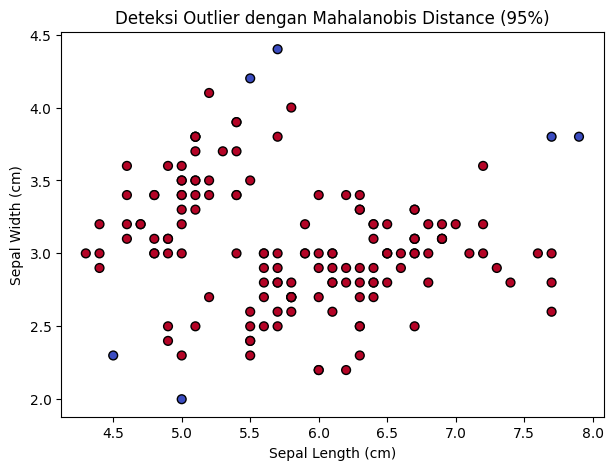

In [ ]:
plt.figure(figsize=(7, 5))
plt.scatter(df['sepal length (cm)'],
            df['sepal width (cm)'],
            c = ~df['Outlier'],
            cmap = 'coolwarm',
            s = 40,
            edgecolors = 'k')

plt.xlabel('Sepal Length (cm)')
plt.ylabel('Sepal Width (cm)')
plt.title('Deteksi Outlier dengan Mahalanobis Distance (95%)') ;

#### Robust Mahalanobis Distance

Intuisi Dasar

Mahalanobis Distance biasa bekerja baik _*kalau datanya bersih dan berdistribusi normal**.
Masalahnya — di dunia nyata, **data sering sudah kotor duluan**: ada beberapa outlier ekstrem yang bikin **rata-rata dan kovarians rusak**.

Bayangin ini:

> Kamu mau cari pusat keramaian orang di taman (rata-rata posisi).
> Tapi ada 2 orang nyasar jauh banget di pinggir taman.
> Kalau kamu tetap hitung rata-rata semua posisi, pusat keramaian kamu malah bergeser ke arah dua orang nyasar itu 😅

Nah, di sinilah **Minimum Covariance Determinant (MCD)** membantu.
Dia mencoba berkata:

> “Aku akan abaikan sebagian kecil data paling mencurigakan,
> lalu hitung pusat dan sebaran dari data yang paling *bersih* — supaya hasilnya stabil dan tidak rusak.”

$$ \ $$
Ide Matematis  

Tujuan MCD adalah mencari **subset data yang paling representatif** (bebas outlier), yaitu subset yang punya **determinant kovarians sekecil mungkin**.

Formulasi Masalah

Misal kamu punya:

* Dataset $X = {x_1, x_2, \dots, x_n}$, masing-masing berdimensi $p$
* Kamu mau pilih subset $H$ yang terdiri dari $h$ titik data, di mana $h < n$

Kita mau cari:
$$ \ $$
$$
(\hat{\mu}_{MCD}, \hat{\Sigma}_{MCD}) = \arg\min_{\mu, \Sigma \text{ dari subset } H} \det(\Sigma_H)
$$
$$ \ $$
di mana:

* $\Sigma_H$ = matriks kovarians yang dihitung dari subset $H$
* $\det(\Sigma_H)$ = *determinant* kovarians (semakin kecil, semakin “kompak” datanya)

Jadi:

> “Ambil subset data sebesar $h$ yang bikin sebarannya sekecil mungkin.”

$$ \ $$

Langkah Umum Algoritma

Secara konsep, proses MCD bisa dijelaskan seperti ini:

- **Ambil subset acak berukuran $h$ dari total $n$ data.**

- Hitung kovarians subset → $\Sigma_H$.

- Hitung determinannya → $\det(\Sigma_H)$.

- Ulangi banyak kali dengan subset berbeda → cari subset dengan **determinant terkecil**.

- Dari subset terbaik → hitung:
   $$ \ $$
   $$
   \hat{\mu}_{MCD} = \frac{1}{h} \sum_{x_i \in H} x_i
   $$
   $$ \ $$
   $$
   \hat{\Sigma}_{MCD} = \frac{1}{h-1} \sum_{x_i \in H} (x_i - \hat{\mu}_{MCD})(x_i - \hat{\mu}_{MCD})^T
   $$

- Akhirnya, gunakan hasil itu untuk hitung **Robust Mahalanobis Distance**:
   $$ \ $$
   $$
   D_{MCD}(x_i) = \sqrt{(x_i - \hat{\mu}_{MCD})^T \hat{\Sigma}_{MCD}^{-1} (x_i - \hat{\mu}_{MCD})}
   $$

$$ \ $$

Kenapa “Minimum Covariance Determinant” (MCD)?

Karena logika MCD adalah:

* Covariance matrix mengukur **bentuk elips sebaran data**.
* Determinant dari covariance matrix = **volume elips** (semakin besar determinant, semakin luas sebaran).
* Dengan mencari subset dengan determinant terkecil → kita sedang mencari **kelompok data paling padat** (tidak terpengaruh outlier).

$$ \ $$

Hubungan ke Mahalanobis Distance

Setelah kita dapat $\hat{\mu}_{MCD}$ dan $\hat{\Sigma}_{MCD}$ yang “bersih”,
jarak Mahalanobis-nya jadi **lebih robust**:
$$ \ $$
$$
D_{MCD}^2(x_i) = (x_i - \hat{\mu}_{MCD})^T \hat{\Sigma}_{MCD}^{-1} (x_i - \hat{\mu}_{MCD})
$$
$$ \ $$

Lalu kita bandingkan dengan $\chi^2_p$ seperti biasa untuk mendeteksi outlier:
$$ \ $$
$$
D_{MCD}^2(x_i) > \chi^2_{p, 0.975} \Rightarrow \text{Outlier}
$$
$$ \ $$

Ringkasan Perbandingan

| Aspek                         | Mahalanobis Biasa          | Robust Mahalanobis (MCD)        |
| ----------------------------- | -------------------------- | ------------------------------- |
| Sensitivitas terhadap outlier | Tinggi                     | Rendah                          |
| Estimasi kovarians            | Semua data                 | Subset “bersih”                 |
| Stabilitas hasil              | Mudah rusak oleh pencilan  | Lebih stabil                    |
| Distribusi data yang cocok    | Multivariate normal bersih | Data nyata dengan noise/outlier |
| Implementasi sklearn          | Manual via `cov` dan `inv` | `EllipticEnvelope`              |

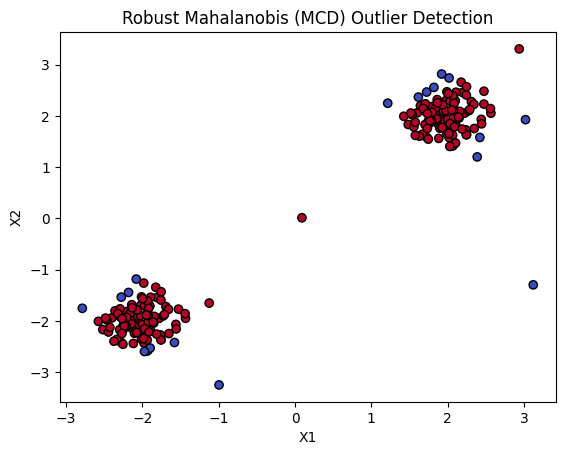

In [ ]:
from sklearn.covariance import EllipticEnvelope

# buat data
rng = np.random.RandomState(42)
X = 0.3 * rng.randn(100, 2)
X_outliers = rng.uniform(low=-4, high=4, size=(10, 2))
X = np.r_[X + 2, X - 2, X_outliers]

# fit model MCD
mcd = EllipticEnvelope(contamination=0.1, support_fraction=0.7, random_state=42)
mcd.fit(X)

# prediksi (-1 = outlier)
labels = mcd.predict(X)

# plot
plt.scatter(X[:, 0], X[:, 1], c=(labels == 1), cmap='coolwarm', edgecolor='k')
plt.title("Robust Mahalanobis (MCD) Outlier Detection")
plt.xlabel("X1")
plt.ylabel("X2")
plt.show()


#### Isolation Forest

### Handle

#### Trimming

**Intuisi Dasar**

> Bayangkan kamu sedang menghitung rata-rata tinggi badan mahasiswa.
Kalau tiba-tiba ada satu data “tinggi = 400 cm”, jelas itu tidak masuk akal — hasil rata-rata langsung rusak.

 Maka muncul ide paling sederhana: hapus saja data yang “aneh”. Karena data itu tidak mewakili populasi sebenarnya, melainkan noise, error pengukuran, atau kasus ekstrem yang memang tidak ingin kamu pelajari.

$$ \ $$

**Konsep Dasar “Remove Outliers”**

> Menghapus observasi (baris) yang terdeteksi sebagai outlier dari dataset agar distribusi data menjadi lebih representatif terhadap populasi utama.

Metode ini tidak memperbaiki data, melainkan menyaring data yang dianggap tidak valid atau tidak relevan.

$$ \ $$
**Proses dan Pendekatan Umum**

Biasanya penghapusan data dilakukan setelah tahap deteksi outlier, misalnya dengan:

- IQR (Interquartile Range)  
  - Data dianggap outlier jika:
    $$ \ $$
    $$x < Q1 - 1.5 \times IQR \ \  \text{ atau } \ \  x > Q3 + 1.5 \times IQR$$
    $$ \ $$
  - Lalu nilai yang memenuhi kondisi itu dihapus.
- Z-Score (lebih dari 3)
  - Data dianggap outlier jika:
    $$ \ $$
    $$ |z| = \frac{|x-μ|}{σ} > 3$$
    $$ \ $$
  - Observasi dengan z-score > 3 dihapus.
- Mahalanobis distance (multivariat):  

  Data dihapus jika:
  $$ \ $$
  $$𝐷^2>𝜒^2_{(𝑝,𝛼)}$$
  $$ \ $$
  di mana 𝑝 = jumlah variabel.

$$ \ $$
**Kapan Boleh Menghapus Outliers**

Metode ini tepat digunakan jika:

- Outlier disebabkan oleh error teknis, seperti kesalahan input (salah satuan, typo, alat rusak)  
  Misalnya berat badan 700 kg → jelas tidak valid.
- Data tersebut tidak mewakili populasi yang sedang diteliti.  
  Misalnya ketika meneliti pendapatan pekerja kantoran terdapat data CEO dengan pendapatan miliaran → tidak relevan dengan populasi target.
- Proporsi outlier sangat kecil (< 5%)  
  Artinya penghapusan tidak mengubah struktur data secara signifikan.
- Ukuran dataset besar.  
  Kehilangan sebagian kecil data tidak mengurangi informasi terlalu banyak.

$$ \ $$
**Kapan Tidak Boleh Menghapus Outliers**

| Kondisi                                     | Penjelasan                                                                                                                     |
| ------------------------------------------- | ------------------------------------------------------------------------------------------------------------------------------ |
| **Data kecil**                           | Hapus sedikit saja bisa kehilangan informasi penting.                                                                          |
| **Outlier membawa makna ilmiah**         | Misalnya data gempa besar, pasien dengan gejala ekstrem, atau harga saham saat krisis — justru itu yang ingin kamu pelajari.   |
| **Distribusi data memang alami ekstrem** | Misal data ekonomi (pendapatan), data biologis (ukuran tubuh), data keuangan. Data ekstrem sering memang bagian dari fenomena. |
| **Model yang tahan outlier lebih cocok** | Jika tujuannya prediksi, bisa gunakan model robust (misal: *Robust Regression*, *Isolation Forest*, *RANSAC*).                 |

$$ \ $$
**Dampak dari Menghapus Outliers**  

- Positif  
  - Distribusi data menjadi lebih normal / simetris.
  - Model statistik jadi lebih stabil.
  - Interpretasi rata-rata & deviasi standar jadi lebih masuk akal.

- Negatif
  - Bisa kehilangan informasi penting.
  - Bisa menggeser populasi target.
  - Bisa menyebabkan bias jika outlier ternyata bagian sah dari data asli.

$$ \ $$
**Implementasi**

#### Transformasi Data

##### Log Transform

**Intuisi**  
Bayangkan kamu punya data penghasilan:

| Penghasilan|
|------------|
|3 juta      |
|4 juta      |
|5 juta      |
|10 juta     |
|100 juta    |

$$ \ $$
Kalau kamu buat histogram, bentuknya sangat miring ke kanan (right-skewed) karena satu orang berpenghasilan 100 juta jauh lebih besar dari lainnya.  

Akibatnya:
- Rata-rata jadi terseret ke kanan (tidak representatif).
- Model regresi bisa berperilaku tidak stabil, karena satu data ekstrem memengaruhi garis fit.

Solusi intuitif:

> “Kalau nilainya besar banget, mari kita ‘tekan’ supaya skala ekstremnya berkurang.”

Nah, fungsi logaritma bekerja seperti itu — dia memampatkan skala besar, tapi menjaga urutan relatif antar data tetap benar.

$$ \ $$
**Konsep**

Log Transform adalah transformasi matematis pada data dengan mengambil logaritma dari nilai aslinya:  
$$ \ $$
$$ x' = \log(x)$$
$$ \ $$
Biasanya digunakan untuk:

- Mengurangi skewness (kemencengan distribusi)
- Menstabilkan varians
- Mengurangi pengaruh outlier
- Meningkatkan linearitas antar variabel

Syarat utama:
> Semua nilai $x>0$ (tidak boleh nol atau negatif).

$$ \ $$
**Rumus**

| Jenis        | Rumus                                      | Keterangan                     |
| ------------ | ------------------------------------------ | ------------------------------ |
| Natural Log  | $x'= \ln(x)$| Basis (e = 2.718...)|
| Log10        | $x' = \log_{10}(x)$| Basis 10                       |
| Log1p        | $x' = \log(1 + x)$ | Aman untuk data yang punya nol |
| General form | $$x' = \log_b(x) = \frac{\ln(x)}{\ln(b)}$$ | Basis bebas (b > 1) |

$$ \ $$
**Mengapa Ini Boleh Secara Matematis**

Secara matematis, log transform adalah transformasi monotonik meningkat:  
$$ \ $$
$$ \text{Jika } x_1 < x_2,  \ \ \text{ maka } \ \  \log(x_1) < \log(x_2)$$
$$ \ $$
Artinya:
- Urutan antar data tetap sama (tidak rusak)
- Semua informasi perbandingan antar data tetap valid
- Skala berubah, tapi relasi ordinal tetap terjaga

Selain itu, logaritma adalah fungsi konveks dan kontinu, jadi transformasi ini:
- Tidak menciptakan “loncatan” atau “lubang” dalam data
- Aman digunakan dalam operasi matematik dan model statistik
$$ \ $$

Efek Secara Matematis + Bukti
- Efek Memampatkan Skala Besar  
  Untuk $𝑥>1$, pertumbuhan log sangat lambat.  
  $$ \ $$
  | x    | log10(x) |
  | ---- | -------- |
  | 10   | 1        |
  | 100  | 2        |
  | 1000 | 3        |

  $$ \ $$
  Perbandingan 10 → 1000 (100x lebih besar) hanya menghasilkan perubahan log sebesar 2 saja. Artinya, data besar “dikecilkan” drastis.
- Efek Meratakan Varians

  Bayangkan kamu punya dua kelompok data penghasilan:

  | Kelompok | Rata-rata (mean) | Varians (ragam) |
  | -------- | ---------------- | --------------- |
  | A        | 2 juta           | 0.5 juta²       |
  | B        | 20 juta          | 50 juta²        |

  $$ \ $$
  Kelompok B (berpenghasilan tinggi) tidak hanya memiliki nilai rata-rata lebih besar, tetapi juga ragam yang jauh lebih besar.

  - Artinya, makin tinggi penghasilan, makin besar pula sebaran nilainya.
  - Fenomena ini disebut heteroskedastisitas — kondisi di mana varians tidak konstan di seluruh rentang data.

  > Log transform “menarik” nilai besar agar jaraknya menyempit, sehingga variasi antar skala menjadi lebih seragam.

  Bukti  
  Misalkan 𝑋 adalah variabel acak positif (misalnya penghasilan individu), dengan rata-rata $𝜇𝑋=𝐸[𝑋]$.  

  Kita definisikan transformasi:
  $$ \ $$
  $$
  Y = f(X) = \log(X)
  $$
  $$ \ $$
  Kita ingin tahu bagaimana **rata-rata dan varians Y** bergantung pada **rata-rata dan varians X**.

  Namun fungsi logaritma bersifat non-linear, sehingga kita tidak bisa langsung menulis:
  $$ \ $$
  $$Var[Y] = f(Var[X])$$
  $$ \ $$
  Untuk itu digunakan Delta Method, yang mendekati efek fungsi non-linear di sekitar nilai rata-rata menggunakan pendekatan deret Taylor orde pertama.
  $$ \ $$
  $$
  f(X) \approx f(\mu_X) + f'(\mu_X) (X - \mu_X)
  $$
  $$ \ $$
  Kita abaikan suku orde tinggi (karena diasumsikan varian kecil).
  
  Dengan pendekatan Taylor:
  $$ \ $$
  $
  Var[Y] = Var[f(X)] \approx Var[f(\mu_X) + f'(\mu_X)(X - \mu_X)]
  $
  $$ \ $$
  
  - Pertama, Gunakan sifat:
    $$ \ $$
    $
    Var(A + B) = Var(A) + Var(B) + 2Cov(A,B)
    $
    $$ \ $$
    Dengan
    - $A = f(\mu_X)$
    - $ B = f'(\mu_X)(X - \mu_X)$  

    Maka
    $$ \ $$
    $
    Var[f(X)] \approx Var[f(\mu_X)] + Var[f'(\mu_X)(X - \mu_X)] + 2Cov(f(\mu_X), f'(\mu_X)(X - \mu_X))
    $
    $$ \ $$
  - Jika salah satu suku adalah **konstanta**, maka:
    $$ \ $$
    $$
    Var(c) = 0, \quad Cov(c, Z) = 0
    $$
    $$ \ $$
    Karena $f(\mu_X)$ dan $f'(\mu_X)$ adalah konstanta, maka:

    $$ \ $$
    $$
    Var[f(X)] \approx Var[f'(\mu_X)(X - \mu_X)]
    $$
    $$ \ $$

  - Jika kita punya konstanta dikali peubah acak $cX$:

    $$ \ $$
    $$
    Var(cX) = c^2 Var(X)
    $$
    $$ \ $$
    Maka
    $$ \ $$
    $$
    Var[f'(\mu_X)(X - \mu_X)] = [f'(\mu_X)]^2 Var[X - \mu_X]
    $$
    $$ \ $$
    Ragam tidak berubah jika dikurangi rata-rata:
    $$ \ $$
    $
    Var(X + c) = \frac{1}{n}\sum [(x_i + c) - (\bar{x} + c)]^2 = \frac{1}{n}\sum (x_i - \bar{x})^2 = Var(X)
    $
    $$ \ $$
    Maka
    $$ \ $$
    $$
    Var(X - \mu_X) = Var(X)
    $$
    $$ \ $$
    Sehingga
    $$ \ $$
    $$
    \boxed{Var[f(X)] \approx [f'(\mu_X)]^2 Var[X]}
    $$
    $$ \ $$
  
  - Persamaan tersebut kemudian diaplikasikan untuk Log Transform
    $$ \ $$
    Jika $f(X) = \log(X)$, maka $f'(X) = 1/X $.
    $$ \ $$
    $$
    Var[\log(X)] \approx \left(\frac{1}{\mu_X}\right)^2 Var[X]
    $$
  
    Interpretasi :    
    
    - Jika $𝜇_𝑋$ besar, maka $\frac{1}{𝜇_𝑋}$	​kecil → varian hasil log lebih kecil.

    - Artinya log transform mengompresi nilai besar, menstabilkan varians di seluruh skala.

    Dengan kata lain:

      - Nilai besar “ditarik ke bawah”.
      - Nilai kecil tidak berubah banyak.
      - Data jadi lebih homoskedastis (varian konstan).

$$ \ $$

**Kegunaan**

$$ \ $$
| Tujuan                            | Penjelasan                                                                               |
| --------------------------------- | ---------------------------------------------------------------------------------------- |
| **1. Menstabilkan varians**       | Variabel dengan rentang besar (misal: pendapatan, populasi, harga saham) bisa dikompres. |
| **2. Menormalkan distribusi**     | Data right-skewed menjadi lebih simetris.                                                |
| **3. Meningkatkan linearitas**    | Banyak hubungan non-linear bisa jadi linear di domain log.                               |
| **4. Memperbaiki performa model** | Model berbasis linear (OLS, Logistic Regression) lebih stabil.                           |
| **5. Mengatasi outliers**         | Nilai besar ekstrem dikompres, sehingga efek outlier menurun.                            |

$$ \ $$
**Mengatasi Outlier dengan Log Transform**

Katakan kamu punya data:
$$ \ $$
$$
x = [1, 2, 3, 4, 100]
$$
$$ \ $$
Z-score tanpa log:
$$ \ $$
$
\mu = 22, \ \ \sigma = 43 \Rightarrow z_{100} = \frac{100-22}{43} \approx 1.8
$
$$ \ $$
Setelah log:
$$ \ $$
$
\log(x) = [0, 0.69, 1.09, 1.39, 4.60]
$
$$ \ $$
$
\mu' = 1.55, \ \ \sigma' = 1.51 \Rightarrow z'_{100} = \frac{4.6 - 1.55}{1.51} = 2.02
$
$$ \ $$
Terlihat:

* **Nilai ekstrem (100)** sudah tidak “mengacaukan” rata-rata.
* Sebaran menjadi lebih *proporsional*.
* Model yang peka terhadap varians (misalnya regresi linear) jadi **lebih robust**.

$$ \ $$

**Kelebihan dan Kekurangan**
$$ \ $$

| Aspek            | Kelebihan                                                                 | Kekurangan                                                            |
| ---------------- | ------------------------------------------------------------------------- | --------------------------------------------------------------------- |
| **Distribusi**   | Menormalkan data right-skewed                                             | Tidak cocok untuk data dengan nilai ≤ 0                               |
| **Varians**      | Menstabilkan varians tinggi                                               | Dapat memperburuk data left-skewed                                    |
| **Interpretasi** | Mengubah skala → hubungan multiplicative jadi additive (mudah dimodelkan) | Interpretasi hasil model jadi “di skala log” (perlu *back-transform*) |
| **Modeling**     | Linear models lebih fit                                                   | Tidak semua model butuh log transform                                 |
| **Outlier**      | Mengurangi efek outlier ekstrem                                           | Tidak menghapus outlier ekstrem total, hanya mengecilkan dampaknya    |

$$ \ $$

**Ringkasan Cepat**
$$ \ $$

| Aspek              | Ringkasan                                                              |
| ------------------ | ---------------------------------------------------------------------- |
| **Tujuan utama**   | Mengurangi skewness, menstabilkan varians, mengurangi pengaruh outlier |
| **Rumus**          | $x' = \log(x)$ atau $\log(1+x) $                                    |
| **Efek matematik** | Kompres nilai besar, ubah hubungan power → linear                      |
| **Syarat**         | $x > 0 $                                                              |
| **Kapan dipakai**  | Saat data right-skewed, rentang nilai besar, atau ada outlier tinggi   |
| **Alternatif**     | Square root transform, Box-Cox transform                               |

$$ \ $$
**Implementasi**

In [ ]:
data = pd.Series([1, 2, 3, 4, 100])

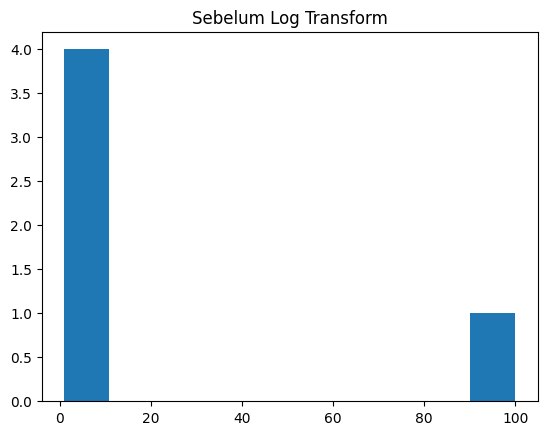

In [ ]:
# Sebelum transformasi
plt.hist(data, bins=10)
plt.title("Sebelum Log Transform")
plt.show()

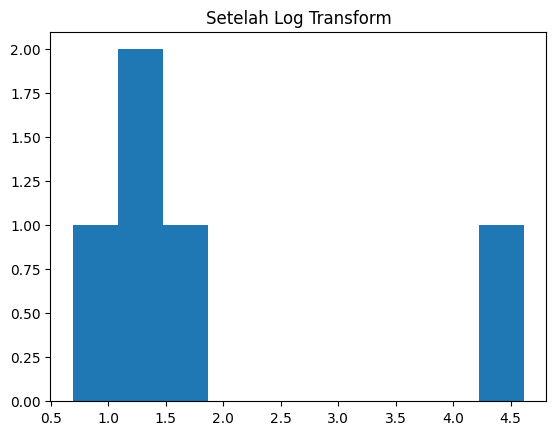

In [ ]:
# Setelah log transform (gunakan log1p untuk aman dari nol)
log_data = np.log1p(data)

plt.hist(log_data, bins=10)
plt.title("Setelah Log Transform")
plt.show()

#####  Square Root Transform

**Konsep**  

**Square root transform** adalah **transformasi non-linear** pada data positif yang didefinisikan sebagai:
$$ \ $$
$$
y' = \sqrt{y}
$$
$$ \ $$
Transformasi ini **mengubah skala data** dengan cara **memampatkan nilai-nilai besar lebih banyak daripada nilai-nilai kecil**.
Artinya, nilai yang ekstrem (outlier) akan "didekatkan" ke pusat distribusi.

$$ \ $$
**Intuisi**

Bayangkan kamu punya data jumlah kejadian (count), misalnya:

| Observasi | Jumlah Kejadian |
| --------- | --------------- |
| A         | 1               |
| B         | 4               |
| C         | 9               |
| D         | 16              |

Tanpa transformasi, jarak antara 1 dan 16 adalah **15**.
Setelah transformasi akar:
$$ \ $$
$$
\sqrt{1}=1,\quad \sqrt{4}=2,\quad \sqrt{9}=3,\quad \sqrt{16}=4
$$
$$ \ $$
Sekarang jaraknya antara 1 dan 16 **hanya 3**. Nilai besar “dikecilkan” jauh lebih banyak dibandingkan nilai kecil.

Artinya:

* Nilai ekstrem (besar) ditarik ke bawah,
* Varians menjadi lebih kecil,
* Distribusi cenderung lebih simetris.

$$ \ $$
**Rumus**  

Jika semua nilai $y_i \ge 0$, maka:
$$ \ $$
$$
y_i' = \sqrt{y_i}
$$
$$ \ $$

Namun jika terdapat nilai 0, sering digunakan bentuk **shifted**:
$$ \ $$
$$
y_i' = \sqrt{y_i + c}
$$
$$ \ $$
dengan $c = 0.5$ atau $c = 1$ untuk menghindari akar nol.

$$ \ $$
**Mengapa Ini “Boleh” Secara Matematis**

Transformasi ini sah secara matematis karena:

- Fungsi monotonik meningkat

  Fungsi $f(y) = \sqrt{y}$ bersifat monoton naik di domain $y \ge 0$. Artinya, urutan data **tidak berubah**, hanya **skala antar nilai** yang berubah.
  $$ \ $$
  $$
  y_1 < y_2 \Rightarrow \sqrt{y_1} < \sqrt{y_2}
  $$
  $$ \ $$

  Sehingga perbandingan dan hubungan tetap terjaga.

- Varians berkurang dengan turunan yang menurun

  Turunan pertama:
  $$ \ $$
  $$
  \frac{d}{dy}\sqrt{y} = \frac{1}{2\sqrt{y}}
  $$
  $$ \ $$
  Semakin besar $y$, semakin kecil turunan tersebut.
  Artinya: perubahan kecil pada $y$ besar hanya sedikit mengubah hasil transformasi — **itulah alasan matematis kenapa nilai besar “diperkecil” pengaruhnya**.

$$ \ $$
**Efek Matematis dan Bukti**

- Efek terhadap varians  
  Misalkan $y$ adalah variabel acak dengan mean $\mu$ dan varians $\sigma^2$.  
  
  Dengan transformasi $y' = \sqrt{y}$, kita dapatkan secara pendekatan (menggunakan **delta method**):
  $$ \ $$
  $$
  Var(y') \approx \left(\frac{d\sqrt{y}}{dy}\bigg|_{y=\mu}\right)^2 \cdot Var(y)
  = \left(\frac{1}{2\sqrt{\mu}}\right)^2 \cdot \sigma^2
  = \frac{\sigma^2}{4\mu}
  $$
  $$ \ $$
  Varians setelah transformasi menjadi **lebih kecil** proporsional terhadap $1/\mu$.

  Bukti:  
  - Kita punya variabel acak (Y) dengan:
    $$ \ $$
    $$
    E[Y] = \mu, \quad Var(Y) = \sigma^2
    $$
    $$ \ $$
    dan kita melakukan transformasi:
    $$ \ $$
    $$
    Y' = f(Y) = \sqrt{Y}
    $$
    $$ \ $$
    Tujuan: cari hubungan antara (Var(Y')) dan (Var(Y)).


  - Untuk fungsi non-linear $f(Y)$, varians transformasi **tidak bisa dihitung langsung** dengan rumus sederhana. Namun, kalau (f) cukup halus dan perubahan (Y) kecil, kita bisa **hampiri (approximate)** dengan deret Taylor orde pertama di sekitar mean (\mu).

    $$ \ $$
    $$
    f(Y) \approx f(\mu) + f'(\mu)(Y - \mu)
    $$
    $$ \ $$
    Lalu ambil varians dari kedua sisi:
    $$ \ $$
    $$
    Var(f(Y)) \approx [f'(\mu)]^2 Var(Y)
    $$
    $$ \ $$

  - Turunan dari fungsi akar

    Untuk $f(Y) = \sqrt{Y}$:
    $$ \ $$
    $$
    f'(Y) = \frac{1}{2\sqrt{Y}}
    $$
    $$ \ $$

    Evaluasi di titik rata-rata $(Y = \mu)$:
    $$ \ $$
    $$
    f'(\mu) = \frac{1}{2\sqrt{\mu}}
    $$
    $$ \ $$

  - Substitusi ke rumus delta method

    Masukkan ke:
    $$ \ $$
    $$
    Var(f(Y)) \approx [f'(\mu)]^2 Var(Y)
    $$
    $$ \ $$
    menjadi:
    $$ \ $$
    $$
    Var(\sqrt{Y}) \approx \left(\frac{1}{2\sqrt{\mu}}\right)^2 \sigma^2 = \frac{\sigma^2}{4\mu}
    $$
    $$ \ $$
- Efek terhadap outlier

  Jika nilai outlier $y_o$ sangat besar, maka:

  $$ \ $$
  $$
  \sqrt{y_o} \ll y_o
  $$
  $$ \ $$
  Jadi jarak ke mean menjadi jauh lebih kecil.
  Contoh:
  $$ \ $$
  $$
  y_{mean}=10, \ \  y_o=100 \Rightarrow
  |y_o - y_{mean}| = 90,\quad |\sqrt{y_o} - \sqrt{y_{mean}}| = |10 - 3.16| \approx 6.84
  $$
  $$ \ $$
  Outlier yang jauh 90 satuan sebelumnya, kini hanya sekitar 6.84 satuan jauhnya.

$$ \ $$
**Interpretasi**

- Varians diperkecil

  Hasil $\frac{\sigma^2}{4\mu}$ menunjukkan bahwa:

  * Varians setelah transformasi akar **lebih kecil** dari varians asli.
  * Semakin besar mean $(\mu)$, semakin **kecil hasilnya**, karena dibagi dengan $4\mu$.

- Kompresi nilai besar

  Karena turunan $f'(y)$ menurun saat $y$ besar, maka:

  * Perubahan kecil pada (Y) besar → perubahan kecil juga di (Y')
  * Akibatnya, penyebaran nilai besar **terkompresi**, varians menurun

$$ \ $$
**Implikasi Matematis**

| Efek                          | Penjelasan                                                                        |
| ----------------------------- | --------------------------------------------------------------------------------- |
| 🔹 Reduksi varians            | Karena faktor $1/(4\mu)$, data dengan mean besar akan sangat berkurang variansnya |
| 🔹 Reduksi skewness           | Nilai ekstrem besar diredam lebih kuat                                            |
| 🔹 Stabilitas model meningkat | Model (misal regresi) lebih stabil karena noise tidak terlalu menyebar            |

$$ \ $$
**Implementasi**


In [ ]:
# Data Mentah
X = np.random.randint(1, 100, 300)

# Data setelah transformasi
sqrt = np.sqrt(X)

var_X = np.var(X)
var_sqrt = np.var(sqrt)
var_X, var_sqrt

(np.float64(839.174788888889), np.float64(5.4404454808355105))

In [ ]:
mean_X = np.mean(X)
mean_sqrt = np.mean(sqrt)
mean_X, mean_sqrt

(np.float64(50.04333333333334), np.float64(6.678539350224556))

Text(0.5, 1.0, 'Sebelum Square Root Transform')

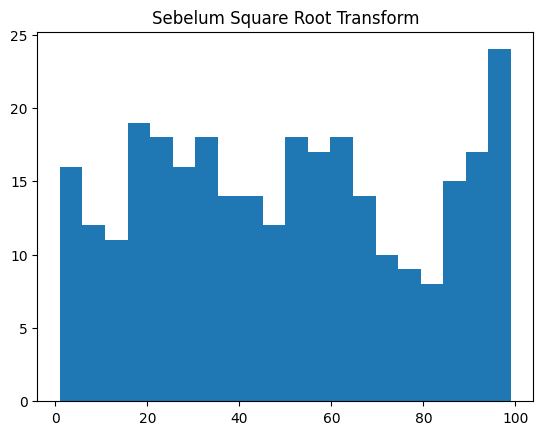

In [ ]:
plt.hist(X, bins=20)
plt.title("Sebelum Square Root Transform")

Text(0.5, 1.0, 'Sesudah Square Root Transform')

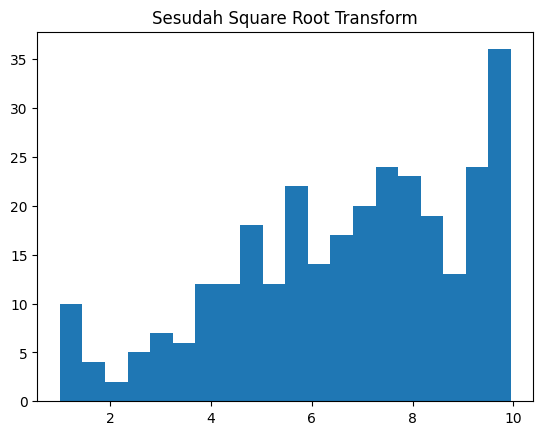

In [ ]:
plt.hist(sqrt, bins=20)
plt.title("Sesudah Square Root Transform")

##### Box-Cox

**Definisi**  

Box–Cox transform adalah transformasi keluarga (family of power transforms) yang digunakan untuk:
- menstabilkan varians,
- membuat distribusi lebih mendekati normal,
- dan memperbaiki linearitas hubungan antar variabel.

Intinya, ini generalisasi dari transformasi seperti log, akar, atau inverse:
semuanya adalah kasus khusus dari Box–Cox.

---

$$ \ $$
**Intuisi**  

- Bayangkan kamu punya data skew ke kanan (seperti data pendapatan, durasi, atau jumlah kejadian).
Kalau kamu coba transformasi:

  - log → agak lebih normal
  - akar → juga bisa
  - kuadrat → malah makin miring ke kanan
  Kamu tidak tahu transformasi mana yang “terbaik”.

- Box–Cox memberikan pendekatan sistematis:

  > “Coba semua transformasi pangkat λ, dan cari yang paling membuat data normal.”

  Dengan kata lain, Box–Cox mencari pangkat terbaik (λ) yang “menormalkan” data secara matematis.

---

$$ \ $$
**Rumus**

Untuk data $y_i > 0$ :
$$ \ $$
$$
y_i^{(\lambda)} =
\begin{cases}
\dfrac{y_i^{\lambda} - 1}{\lambda}, & \text{jika } \lambda \neq 0 \\
\ln(y_i), & \text{jika } \lambda = 0
\end{cases}
$$
$$ \ $$
Penjelasan singkat tiap λ:
$$ \ $$

| λ   | Bentuk                 | Interpretasi     |
| --- | ---------------------- | ---------------- |
| 2   | Kuadrat                | Memperluas data  |
| 1   | Tidak ada transformasi | Data asli        |
| 0.5 | Akar                   | Kompresi sedang  |
| 0   | Logaritma              | Kompresi kuat    |
| -1  | Invers                 | Kompresi ekstrem |

---

$$ \ $$
**Asal Rumus**

- Latar Belakang  
  Dalam banyak data nyata, varians tidak konstan (heteroskedastis) — artinya, data dengan nilai rata-rata (mean) besar cenderung memiliki sebaran (varians) yang juga besar.  
  Misalnya:
  - Data hitungan (jumlah pelanggan, jumlah kasus) → makin besar rata-rata, makin besar variasinya.
  - Data keuangan/lognormal → varians tumbuh lebih cepat dari mean.   

  Masalah ini mengganggu model regresi linear karena asumsi dasar OLS adalah homoskedastisitas (varians konstan).

- Ide Dasar  
  Kita ingin mencari fungsi transformasi 𝑓(𝑌) yang bisa:

  - Menstabilkan varians (agar tidak tergantung pada mean)
  - Membuat data lebih normal (simetris)
  - Memperbaiki linearitas hubungan antarvariabel

  Untuk itu, kita perlu memahami bagaimana varians tergantung pada mean.

- Pola Empiris Mean–Variance  
  Berdasarkan hasil pengamatan, banyak distribusi yang menunjukkan pola power law antara varians dan mean:
  $$ \ $$
   |Distribusi|Bentuk Var(Y)|Hubungan Mean–Variance|p pada Var(Y) = $k \mu^p$|
  | ---------- | ------------------------------ | ---------------------- | ------------------------- |
  | Normal     | Konstan                        | Var(Y)$=k$            | 0                         |
  | Poisson    | Var(Y)$=\mu$                  | Linear                 | 1                         |
  | Gamma      | Var(Y)$= \phi \mu^2$            | Kuadratik              | 2                         |
  | Lognormal  | Var(Y)$ \approx c\mu^2$ (Hampir)| Kuadratik              | 2                         |
  
  $$ \ $$
  Dari tabel ini, Box & Cox menyimpulkan pola umum:
  $$ \ $$
  $$Var(Y) = k \mu^p$$
  $$ \ $$
  pada suatu nilai eksponen 𝑝 yang menggambarkan seberapa kuat hubungan antara varians dan mean.Sampai tahap ini, belum ada λ sama sekali — ini murni hasil pengamatan empiris dari berbagai distribusi.

- Mencari Transformasi $f(Y)$ agar variansnya konstan

  Kita ingin mencari fungsi $f(Y)$ sehingga:
  $$ \ $$
  $$
  Var(f(Y)) = \text{konstan}.
  $$
  $$ \ $$
  Dengan **pendekatan Taylor** (first-order approximation):
  $$ \ $$
  $$ Var(f(Y)) \approx [f'(\mu)]^2 Var(Y)$$
  $$ \ $$
  Agar $Var(f(Y))$ konstan, maka:
  $$ \ $$
  $$f'(\mu)]^2 Var(Y) = \text{konstan}.
  $$
  $$ \ $$
  Masukkan hubungan empiris:
  $$ \ $$
  $$[f'(\mu)]^2 \cdot k \mu^p = c \Rightarrow [f'(\mu)]^2 = \frac{c}{k \mu^p}\Rightarrow f'(\mu) = \sqrt{\frac{c}{k}} \cdot \mu^{-\frac{p}{2}}
  $$
  $$ \ $$
  Konstanta $\frac{c}{k}$ hanyalah bilangan tetap (bergantung pada pilihan skala c,k), sehingga kita dapat menulis hubungan itu sebagai proporsional:
  $$ \ $$
  $$
  f'(\mu) \propto \mu^{-p/2}.
  $$
  $$ \ $$
- Integrasi untuk Mendapatkan Bentuk $𝑓(𝑦)$  
  Sekarang kita integralkan sisi kanan terhadap 𝑦:

  $$ \ $$
  $$
  f(y) = \int y^{-p/2} dy =
  \begin{cases}
  \dfrac{y^{1 - p/2}}{1 - p/2} + C, & p \neq 2 \\
  \ln(y) + C, & p = 2
  \end{cases}
  $$
  $$ \ $$
  Bentuk umum yang diperoleh dapat ditulis ulang sebagai:
  $$ \ $$
  $$
  f(y) = \dfrac{y^{1 - p/2} - 1}{1 - p/2}.
  $$
  $$ \ $$
- Substitusi λ dan Hubungan Akhir  
  Jika kita mendefinisikan:
  
  $$λ = 1 - \frac{p}{2}$$

  $$ \ $$
  maka bentuk di atas berubah menjadi transformasi Box–Cox:
  $$
  f(y) = \dfrac{y^{\lambda} - 1}{\lambda}.
  $$
  $$ \ $$
  Dan jika (λ → 0), maka batasnya menjadi:
  $$ \ $$
  $$\lim_{\lambda \to 0} \dfrac{y^{\lambda} - 1}{\lambda} = \ln(y) $$
  $$ \ $$
  Inilah transisi halus (continuous limit) antara transformasi power dan log.

  Dengan cara ini, Box & Cox berhasil menyatukan berbagai bentuk transformasi (akar, log, identitas) dalam satu rumus umum yang bisa disesuaikan dengan kondisi empiris data.

- Tambahan : Hubungan Eksponen (p) dan (λ)

  Dari substitusi $\lambda = 1 - \frac{p}{2}$, kita bisa menulis ulang hubungan varians–mean menjadi:
  $$ \ $$
  $$
  Var(Y) \propto \mu^{2(1 - \lambda)}.
  $$
  $$ \ $$
  Sehingga:
  $$ \ $$

  | λ   | Bentuk Transformasi | Pola Varians | Contoh Distribusi |
  | --- | ------------------- | ------------ | ----------------- |
  | $1$   | Identitas (Y)       | Konstan      | Normal            |
  | $0.5$ | Akar (√Y)           | $Var∝μ$      | Poisson           |
  | $0$   | Log (ln(Y))         | $Var∝μ^2$    | Lognormal / Gamma |

$$ \ $$

**Algoritma dan Arah Optimasi**
- Siapkan data  
  Kamu punya data positif:
  $$ \ $$
  $$ y_1, \ y_2, \ ... , \ y_n$$
  $$\ $$
  Semua harus positif, karena nanti kalau masuk log (saat λ → 0) gak boleh ada angka ≤ 0.
  $$ \ $$

- Lakukan transformasi untuk berbagai λ  
  Untuk tiap λ (misal dari −5 sampai 5), kita ubah setiap data:

  $$ \ $$
  $$
  y_i^{(\lambda)} =
  \begin{cases}
  \dfrac{y_i^{\lambda} - 1}{\lambda}, & \text{jika } \lambda \neq 0 \\
  \ln(y_i), & \text{jika } \lambda = 0
  \end{cases}
  $$
  $$ \ $$
  Keterangan:  
  - λ itu kayak “tombol distorsi” bentuk data.
  - Kalau λ besar → data “dibuka” (nilai besar makin besar).
  - Kalau λ kecil → data “ditekan” (nilai besar dikecilin).
  - Kalau λ = 0 → jadi log, artinya “menyempilkan nilai besar supaya gak ekstrem”.
  $$ \ $$

- Asumsi Probabilistik  
  Box–Cox menganggap bahwa setelah ditransformasi, data berasal dari distribusi normal:
  $$ \ $$
  $$
  Y_i^{(\lambda)} \sim \mathcal{N}(\mu, \sigma^2)
  $$
  $$ \ $$
  
  Artinya, untuk tiap observasi $t = y_i^{(\lambda)}$, fungsi kepadatan (pdf)-nya adalah:
  
  $$ \ $$
  $$
  p_{Y^{(\lambda)}}(t)
  = \frac{1}{\sqrt{2\pi\sigma^2}}
  \exp\left( -\frac{(t - \mu)^2}{2\sigma^2} \right)
  $$
  $$ \ $$
  **Intuisi:**
  - Kita menganggap data hasil transformasi *sudah normal dan memiliki varians konstan*.
  - Ini sesuai tujuan utama Box–Cox: membuat data mendekati distribusi normal agar bisa digunakan oleh model linear.

- Aturan Perubahan Variabel  

  Kita mau tahu bentuk pdf untuk **data asli** ( y_i ), karena probabilitas total tetap harus dihitung di ruang nilai aslinya. Model statistik (likelihood) bekerja di ruang data asli, bukan di ruang transformasi.

  **Kenapa perlu ini?**
  - Karena kita tahu bentuk pdf dari data hasil transformasi (yang normal), tapi kita ingin menuliskan kembali peluang itu dalam bentuk ( y_i ).
  - Untuk menjaga agar total probabilitas tetap 1, kita gunakan **aturan perubahan variabel**.

  Gunakan aturan perubahan variabel:

  $$ \ $$
  $$
  p_Y(y) = p_{Y^{(\lambda)}}(t) \cdot \left|\frac{dt}{dy}\right|
  $$
  $$ \ $$

  Turunan transformasi:
  $$ \ $$
  $$
  \frac{dt}{dy} =
  \begin{cases}
  y^{\lambda - 1}, & \lambda \neq 0, \\
  \frac{1}{y}, & \lambda = 0
  \end{cases}
  $$
  $$ \ $$

  Jadi:
  $$ \ $$
  $$
  p_Y(y)
  = \frac{1}{\sqrt{2\pi\sigma^2}}
  \exp\left(-\frac{(y^{(\lambda)} - \mu)^2}{2\sigma^2}\right)
  \cdot y^{\lambda - 1}
  $$
  $$ \ $$

  **Intuisi:**  

  * Faktor $y^{\lambda - 1}$ muncul untuk “mengoreksi kepadatan” setelah kita ubah skala data.
  * Tanpa faktor ini, total probabilitas bisa berubah (tidak lagi 1).
  * Ibaratnya, transformasi Box–Cox *meregangkan* atau *memampatkan* ruang data, dan faktor $\left|\frac{dt}{dy}\right|$ memperbaiki kerapatan agar peluang total tetap sama.

- Likelihood Function

  Untuk seluruh data $y_1, y_2, \dots, y_n$:

  $$ \ $$
  $$
  L(\mu, \sigma^2, \lambda)
  = \prod_{i=1}^n p_Y(y_i)
  $$
  $$ \ $$

  Ambil log agar lebih mudah:
  $$ \ $$
  $$
  \log L =
  -\frac{n}{2}\log(2\pi\sigma^2)
  -\frac{1}{2\sigma^2}\sum_{i=1}^n (y_i^{(\lambda)} - \mu)^2+ (\lambda - 1)\sum_{i=1}^n \log(y_i)
  $$
  $$ \ $$
  **Intuisi:**

  * Likelihood ini mengukur **seberapa besar kemungkinan data asli (y)** muncul, **jika setelah ditransformasi** ia mengikuti distribusi normal.
  * Model Box–Cox bekerja di ruang transformasi (di mana normalitas diasumsikan), tapi *mengembalikan probabilitas ke ruang asli* menggunakan faktor koreksi $y^{\lambda-1}$.
  * Tujuannya: cari nilai $\lambda$ yang **memaksimalkan log-likelihood**, yaitu membuat distribusi hasil transformasi *paling mirip normal*.

$$ \ $$

**Ringkasan**  
$$ \ $$

| Tahap              | Apa yang dilakukan                            | Intuisi                                       |
| ------------------ | --------------------------------------------- | --------------------------------------------- |
| Transformasi       | Ubah bentuk data dengan λ                     | Mengontrol tingkat distorsi distribusi        |
| Asumsi Normalitas  | Anggap hasil transformasi normal              | Target: varians konstan & simetris            |
| Perubahan Variabel | Hubungkan pdf ruang transformasi ↔ ruang asli | Menjaga probabilitas total tetap 1            |
| Likelihood         | Kalikan peluang tiap observasi                | Mengukur “seberapa normal” hasil transformasi |
| Optimasi λ         | Maksimalkan log-likelihood                    | Cari λ terbaik yang paling menstabilkan data  |

$$  \ $$
**Implementasi**

In [ ]:
from scipy import stats

# Buat data positif yang skewed (condong ke kanan)
np.random.seed(0)
data = np.random.exponential(scale=2, size=1000)  # contoh data skewed (mirip data income, harga, dll)

# Lakukan transformasi Box–Cox
transformed_data, fitted_lambda = stats.boxcox(data)

# Tampilkan lambda optimal
print(f"Nilai λ optimal: {fitted_lambda:.3f}")

Nilai λ optimal: 0.242


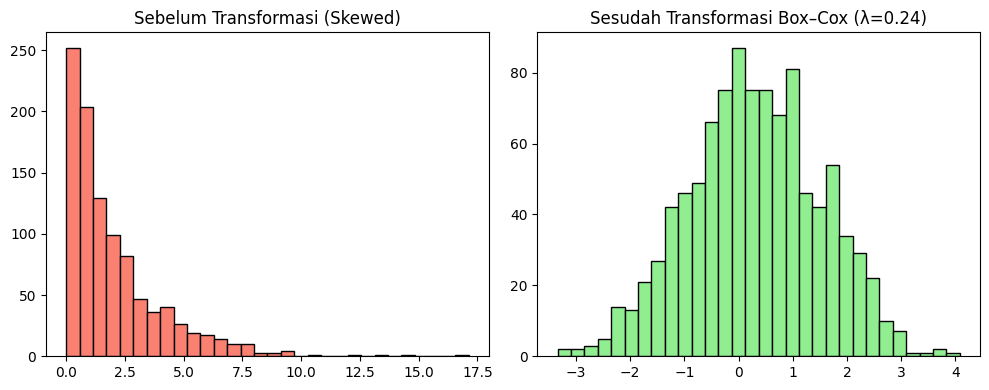

In [ ]:
# Bandingkan distribusi sebelum dan sesudah transformasi
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].hist(data, bins = 30, color = 'salmon', edgecolor='black')
ax[0].set_title("Sebelum Transformasi (Skewed)")

ax[1].hist(transformed_data, bins=30, color='lightgreen', edgecolor='black')
ax[1].set_title(f"Sesudah Transformasi Box–Cox (λ={fitted_lambda:.2f})")

plt.tight_layout()
plt.show()

##### Yeo-Johnson

**Definisi**

Yeo–Johnson transform adalah generalisasi dari **Box–Cox** yang dapat digunakan pada **data dengan nilai nol dan negatif**.

Jika Box–Cox hanya berlaku untuk $y > 0$, maka Yeo–Johnson memperluas idenya agar bisa menangani:

* data $y > 0$ (positif),
* data $y = 0$,
* dan data $y < 0$ (negatif).

Tujuannya **sama**:

* menstabilkan varians,
* membuat distribusi lebih mendekati normal,
* dan memperbaiki linearitas hubungan antar variabel.

$$ \ $$
**Intuisi**

* Bayangkan kamu punya data seperti:

  ```
  [-10, -3, 0, 1, 5, 20]
  ```

  Kalau kamu mau pakai Box–Cox → gagal, karena log dan pangkat untuk nilai negatif gak terdefinisi.

* Yeo–Johnson memperkenalkan cara untuk **mentransformasi bagian positif dan negatif secara simetris**:

  * Bagian positif → seperti Box–Cox biasa.
  * Bagian negatif → diberi transformasi yang mirip, tapi dengan tanda dan rumus yang menyesuaikan supaya tetap kontinu dan halus di nol.

> Jadi, Yeo–Johnson bisa dibilang **“versi Box–Cox dua arah”** — yang bisa bekerja di seluruh garis bilangan real.

$$ \ $$
**Rumus**

Untuk sembarang $y \in \mathbb{R}$:

$$
y^{(\lambda)} =
\begin{cases}
\dfrac{(y + 1)^{\lambda} - 1}{\lambda}, & \text{jika } y \ge 0, \ \lambda \neq 0\\
 \ \text{} \\
\ln(y + 1), & \text{jika } y \ge 0, \ \lambda = 0 \\
 \ \text{} \\
-\dfrac{(-y + 1)^{2 - \lambda} - 1}{2 - \lambda}, & \text{jika } y < 0, \ \lambda \neq 2 \\
  \ \text{} \\
-\ln(-y + 1), & \text{jika } y < 0, \ \lambda = 2
\end{cases}
$$
$$ \ $$
Keterangan:  

|y|Lambda|Rumus|Makna/Interpretasi|
|-|------|-----|---------------- |
| y > 0|$\lambda = 1$ | $y^{(\lambda)} = y$                    | Tidak ada transformasi                          |
| y > 0|$\lambda = 0$ | $y^{(\lambda)} = \ln(y + 1)$           | Kompresi kuat (seperti log)                     |
| y < 0|$\lambda = 2$ | $y^{(\lambda)} = -\ln(-y + 1)$         | Kompresi kuat sisi negatif                      |
| y < 0|$\lambda = 1$ | $y^{(\lambda)} = y$                    | Tidak ada transformasi                          |
| Umum      |             | Simetris antara sisi positif dan negatif | Distribusi dibuat lebih normal dan halus di nol |

$$ \ $$
**Asal Rumus dan Motivasi**

- Latar Belakang  
  Pada Box–Cox, data harus **positif**, karena:

  * saat $\lambda = 0$ → $\log(y)$
  * log tidak terdefinisi untuk $y \le 0$

  Namun, banyak data di dunia nyata (seperti perubahan harga, keuntungan/rugi, skor, residual regresi) mengandung nilai negatif.
  
  Yeo & Johnson (2000) ingin memperluas ide Box–Cox agar bisa:

  * bekerja untuk semua (y),
  * tetap *continuous* dan *smooth* di titik nol,
  * mempertahankan sifat menstabilkan varians dan menormalkan distribusi.

- Ide Dasar  
  Pisahkan domain menjadi dua bagian:

  * Untuk $y \ge 0 \to$ gunakan ide Box–Cox seperti biasa, tapi dengan (y + 1) agar nol tetap valid.
  * Untuk $y < 0 \to$ gunakan bentuk mirip Box–Cox, tapi dengan eksponen yang “dikompensasi” (2 - \lambda), dan tambahkan tanda negatif agar hasilnya tetap kontinu.

  > Dengan cara ini, bentuk fungsi halus di $y = 0$, tidak ada loncatan atau ketidakterusan.

- Turunan dan Koreksi Kepadatan (Jacobian)

  Untuk probabilitas (pdf), kita tetap harus menjaga total peluang = 1.
  
  Maka digunakan aturan perubahan variabel:
  $$ \ $$
  $$
  p_Y(y) = p_{Y^{(\lambda)}}(t) \cdot \left| \frac{dt}{dy} \right|
  $$
  $$ \ $$
  Turunan masing-masing bagian:
  $$ \ $$
  $$
  \frac{dt}{dy} =
  \begin{cases}
  (y + 1)^{\lambda - 1}, & y \ge 0\\
  \ & \ \\
  (-y + 1)^{1 - \lambda}, & y < 0
  \end{cases}
  $$
  $$ \ $$
  Sehingga bentuk pdf data asli menjadi:
  $$ \ $$
  $$
  p_Y(y) =
  \frac{1}{\sqrt{2\pi\sigma^2}}
  \exp\left(-\frac{(y^{(\lambda)} - \mu)^2}{2\sigma^2} \right)
  \cdot
  \begin{cases}
  (y + 1)^{\lambda - 1}, & y \ge 0 \\
  \ & \ \\
  (-y + 1)^{1 - \lambda}, & y < 0
  \end{cases}
  $$
  $$ \ $$

**Asumsi Probabilistik**

Yeo–Johnson juga mengasumsikan bahwa hasil transformasi sudah mengikuti distribusi normal:
$$ \ $$
$$
Y^{(\lambda)} \sim \mathcal{N}(\mu, \sigma^2)
$$
$$ \ $$
Artinya:

* Setelah ditransformasi, data dianggap *normal dan homoskedastik*.
* Tujuan kita tetap sama: cari λ yang membuat hasil transformasi *paling mendekati normal*.

$$ \ $$
**Log-Likelihood Function**

Untuk seluruh data $y_1, \dots, y_n$:
$$ \ $$
$$
\log L =
-\frac{n}{2}\log(2\pi\sigma^2)
-\frac{1}{2\sigma^2}\sum_{i=1}^n (y_i^{(\lambda)} - \mu)^2+ \sum_{i=1}^n \log\left|\frac{dt}{dy_i}\right|
  $$
$$ \ $$
Dimana:

* $\frac{dt}{dy_i}$ sesuai rumus di atas (berbeda untuk y positif dan negatif).
* λ dipilih agar log-likelihood ini maksimum.

$$ \ $$
**Intuisi Optimasi**

* λ berfungsi sebagai **pengendali bentuk transformasi**.
* Nilai λ yang berbeda akan:
  * menekan atau memperlebar data di sekitar nol,
  * menyesuaikan bentuk distribusi agar lebih normal,
  * dan menstabilkan varians di kedua sisi (positif dan negatif).

$$ \ $$
**Ringkasan dan Perbandingan**
$$ \ $$

| Aspek                            | Box–Cox                          | Yeo–Johnson                      |
| -------------------------------- | -------------------------------- | -------------------------------- |
| Domain                           | $y > 0$                        | $y \in \mathbb{R}$             |
| Perlakuan terhadap nol           | Tidak bisa                       | Bisa (karena pakai (y + 1))      |
| Perlakuan terhadap nilai negatif | Tidak bisa                       | Bisa, dengan simetri dan λ ganda |
| Sifat kontinu di 0               | ❌ Tidak dijamin                  | ✅ Halus dan kontinu              |
| Tujuan                           | Normalisasi & stabilisasi varian | Sama, tapi lebih umum            |
| Hubungan dengan Box–Cox          | -                                | Versi perluasan dari Box–Cox     |

$$ \ $$
**Implementasi**

In [ ]:
from sklearn.preprocessing import PowerTransformer

data = np.array([-5, -2, -1, 0, 1, 3, 10]).reshape(-1, 1)

# Inisialisasi transformasi Yeo-Johnson
pt = PowerTransformer(method='yeo-johnson', standardize=False)

# Fit dan transformasi data
data_trans = pt.fit_transform(data)

# λ optimal hasil fit
print("Nilai λ optimal:", pt.lambdas_)

Nilai λ optimal: [0.73940468]


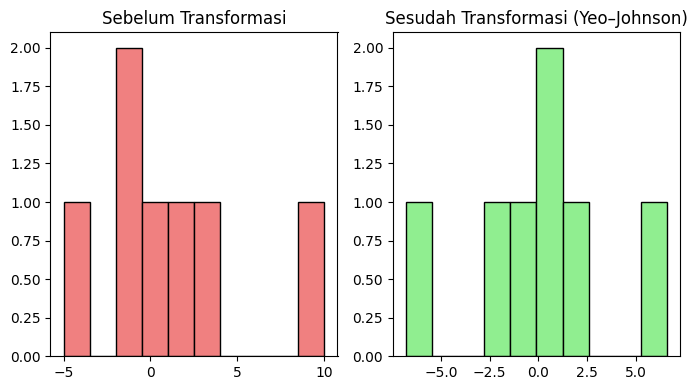

In [ ]:
# Visualisasi efek transformasi
plt.figure(figsize=(7,4))
plt.subplot(1,2,1)
plt.hist(data, bins=10, color='lightcoral', edgecolor='black')
plt.title("Sebelum Transformasi")

plt.subplot(1,2,2)
plt.hist(data_trans, bins=10, color='lightgreen', edgecolor='black')
plt.title("Sesudah Transformasi (Yeo–Johnson)")
plt.tight_layout()
plt.show()

#### Winsorization

**Konsep**

**Winsorization** adalah teknik *handling outlier* yang **tidak menghapus data ekstrem**, tetapi **mengganti nilai ekstrem** dengan nilai batas (threshold) tertentu dari distribusi — biasanya berdasarkan **persentil**.

Misal:

* Nilai di bawah *persentil 5%* diganti dengan nilai pada persentil 5%.
* Nilai di atas *persentil 95%* diganti dengan nilai pada persentil 95%.

**Intuisi**

Bayangkan kamu punya data pendapatan:

```
[5, 6, 7, 8, 9, 1000]
```

Nilai 1000 jelas ekstrem (outlier).
- Kalau kamu hapus → kehilangan informasi.
- Kalau kamu biarkan → rata-rata jadi sangat bias.

Solusi Winsorization:  
- Misal kamu tentukan batas 95% = 9  
- Maka nilai 1000 diganti jadi 9.

  Hasil:

  ```
  [5, 6, 7, 8, 9, 9]
  ```
  Sekarang distribusi lebih “sehat”, tapi semua data tetap ada → kamu **menekan pengaruh ekstrem** tanpa membuang observasi.

**Rumus Matematis**

Untuk data $x_1, x_2, \ldots, x_n$ (sudah diurutkan), dan parameter batas $\alpha$ (misal 0.05):
$$ \ $$
$$
x_i^{(w)} =
\begin{cases}
x_{(\alpha n)} & \text{jika } x_i < x_{(\alpha n)} \\
\ & \ \\
x_i & \text{jika } x_{(\alpha n)} \le x_i \le x_{((1-\alpha)n)} \\
\ & \ \\
x_{((1-\alpha)n)} & \text{jika } x_i > x_{((1-\alpha)n)}
\end{cases}
$$
$$ \ $$
di mana:

* $x_i^{(w)}$ = nilai hasil winsorization
* $x_{(\alpha n)}$ = nilai batas bawah (persentil α)
* $x_{((1-\alpha)n)}$ = nilai batas atas (persentil 1−α)


**Mengapa Ini Boleh Secara Matematik**

Secara matematis, Winsorization **menurunkan varian tanpa mengubah lokasi pusat distribusi terlalu banyak**, dan masih mempertahankan sifat statistik penting.
Dengan kata lain: kita “menjinakkan” ekor distribusi tanpa merusak bentuk utamanya.

- **Mengurangi Varians Ekstrem**

  Varians didefinisikan:
  $$ \ $$
  $$
  Var(X) = E[(X - \mu)^2]
  $$
  $$ \ $$
  Outlier besar membuat ((X - \mu)^2) menjadi sangat besar → menaikkan varian secara tidak proporsional.
  Ketika kita mengganti nilai ekstrem dengan nilai yang lebih moderat melalui winsorization, kita menurunkan kontribusi ekstrem itu terhadap varians:

  $$
  Var(X^{(w)}) < Var(X)
  $$

  Keterangan:  
  - Karena varians bergantung **kuadratik** terhadap jarak dari mean, satu nilai ekstrem (misal 100 kali lebih jauh dari rata-rata) dapat meningkatkan varian hingga $100^2 = 10{,}000$ kali lipat.
  - Dengan menggantinya ke nilai yang lebih dekat ke mean, kita mengontrol “ledakan” varian ini.
  - Secara formal, karena $(x_i^{(w)} - \mu)^2 \le (x_i - \mu)^2 $ untuk data ekstrem, maka rata-rata kuadratnya pun pasti berkurang → varian menurun.

- **Menjaga Ekspektasi agar Tetap Konsisten**

  Jika data berasal dari distribusi **simetris** (misal normal), maka:
  $$ \ $$
  $$
  E[X^{(w)}] \approx E[X]
  $$
  $$ \ $$

  Keterangan:
  - Ekspektasi adalah rata-rata tertimbang dari semua nilai.
  - Ketika kita winsorize, kita hanya mengganti sebagian kecil dari ekor (biasanya 1–5%) dengan nilai yang **masih dalam arah yang sama terhadap mean**.
  - Karena proporsinya kecil dan data simetris, kenaikan di satu sisi ekor diimbangi oleh penurunan di sisi lainnya → pergeseran mean hampir nol.

  Secara matematis, perbedaan ekspektasi dapat ditulis:
  $$ \ $$
  $$
  E[X^{(w)}] - E[X] = \int_{-\infty}^{\infty} (x^{(w)} - x) f(x) dx
  $$
  $$ \ $$
  Nilai integral ini kecil karena $x^{(w)} - x$ hanya berbeda di ekor, di mana $f(x)$ (probabilitas) juga sangat kecil. → Maka hasil integral mendekati nol.

- **Teorema Asimtotik dan Robust Estimator**

  Winsorized mean:
  $$\ $$
  $$
  \bar{x}_w = \frac{1}{n}\sum_{i=1}^{n}x_i^{(w)}
  $$
  $$ \ $$
  adalah estimator **robust** dari mean populasi.

  Keterangan:
  - Dalam teori robust statistics, suatu estimator dikatakan **robust** bila *influence function*-nya terbatas.
  - *Influence function* menggambarkan seberapa besar perubahan satu observasi dapat memengaruhi hasil estimasi.

  Untuk mean biasa:
  $$ \ $$
  $$
  IF(x; \bar{x}, F) = x - \mu
  $$
  $$ \ $$
  yang tidak terbatas → satu outlier besar bisa membuat mean rusak parah.

  Untuk **Winsorized mean**:
  $$ \ $$
  $$
  IF(x; \bar{x}_w, F) =
  \begin{cases}
  L - \mu, & x < L \\
  x - \mu, & L \le x \le U \\
  U - \mu, & x > U
  \end{cases}
  $$
  $$ \ $$
  → Nilainya dibatasi oleh (L) dan (U) (batas winsorization).
  Dengan demikian, satu nilai ekstrem **tidak bisa mengubah mean secara tak terbatas**, menjadikannya estimator yang valid dan stabil menurut teori asimtotik.

  $$ \ $$

Ringkasan:
$$ \ $$

| Aspek                    | Efek Matematis                | Alasan “Boleh” Secara Teoritis                                                    |
| ------------------------ | ----------------------------- | --------------------------------------------------------------------------------- |
| Varians                  | Turun terkendali              | Karena fungsi kuadrat varians membuat outlier punya efek tak proporsional         |
| Ekspektasi               | Hampir tak berubah            | Karena modifikasi hanya di ekor distribusi yang probabilitasnya kecil             |
| Konsistensi & Robustness | Tetap konsisten, lebih stabil | Karena influence function-nya terbatas, jadi estimasi tidak sensitif pada outlier |



**Efek Secara Matematis + Bukti Singkat**

- Efek terhadap Mean

  Sebelum winsorization:
  $$ \ $$
  $$
  \bar{x} = \frac{1}{n} \sum_{i=1}^n x_i
  $$
  $$ \ $$

  Sesudah winsorization:
  $$ \ $$
  $$
  \bar{x}_w = \frac{1}{n} \sum_{i=1}^n x_i^{(w)}
  $$
  $$ \ $$
  Kita tahu bahwa $x_i^{(w)} = x_i$ untuk sebagian besar data, kecuali $k = \alpha n$ data paling kecil dan $k = \alpha n$ data paling besar. Nyatakan Selisih Kedua Mean

  $$ \ $$
  $$
  \bar{x} - \bar{x}_w = \frac{1}{n}\sum_{i=1}^{n}(x_i - x_i^{(w)})
  $$
  $$ \ $$

  Karena untuk data yang **tidak ekstrem** $(x_i = x_i^{(w)})$, maka hanya data ekstrem yang berkontribusi pada selisih ini.
  Artinya:
  $$ \ $$
  $$
  \bar{x} - \bar{x}_w = \frac{1}{n} \left(\sum_{i=1}^{k}(x_i - L) + \sum_{i=n-k+1}^{n}(x_i - U)\right)
  $$
  $$ \ $$
  dengan:

  * $L = x_{(\alpha n)}$ → batas bawah winsorization
  * $U = x_{((1-\alpha)n)}$ → batas atas winsorization
  $$ \ $$

  Ambil Nilai Mutlaknya

  $$  \ $$
  $$
  |\bar{x} - \bar{x}_w| = \frac{1}{n} \left|\sum_{i=1}^{k}(x_i - L) + \sum_{i=n-k+1}^{n}(x_i - U)\right|
  $$
  $$ \ $$

  Gunakan **pertidaksamaan segitiga (triangle inequality)**:
  $$  \ $$
  $$
  |a - b| \le |a| + |b|
  $$
  $$ \ $$

  Maka:
  $$  \ $$
  $$
  |\bar{x} - \bar{x}_w| \le \frac{1}{n}\left(\sum_{i=1}^{k}|x_i - L| + \sum_{i=n-k+1}^{n}|x_i - U|\right)
  $$
  $$ \ $$

  Batasan Nilai Ekstrem

  - Untuk data di ekor bawah:

    Untuk $i\le k$ kita punya $x_{(i)}\le L$, jadi:
    $$ \ $$
    $$
    |x_{(i)}-L|=L-x_{(i)}.
    $$
    $$ \ $$
    Karena $x_{(1)}\le x_{(i)}\le L$, maksimum dari $L-x_{(i)}$ di antara $i\le k$ adalah $L-x_{(1)}$. Jadi
    $$ \ $$
    $$
    \sum_{i=1}^{k}|x_{(i)}-L| \le \sum_{i=1}^{k}(L-x_{(1)}) = k\big(L-x_{(1)}\big).
    $$
    $$ \ $$

    > Intuisi: semua selisih $L-x_{(i)}$ tidak melebihi $L-x_{(1)}$.

  - Untuk data di ekor atas:

    Untuk $i\ge n-k+1$ kita punya $x_{(i)}\ge U$, jadi
    $$ \ $$
    $$
    |x_{(i)}-U|=x_{(i)}-U.
    $$
    $$ \ $$
    Karena $U\le x_{(i)}\le x_{(n)}$, maksimum dari $x_{(i)}-U$ adalah $x_{(n)}-U$. Jadi
    $$ \ $$
    $$
    \sum_{i=n-k+1}^{n}|x_{(i)}-U| \le \sum_{i=n-k+1}^{n}(x_{(n)}-U) = k\big(x_{(n)}-U\big).
    $$
    $$ \ $$
  
  Gabungkan keduanya

  $$ \ $$
  $$
  \big|\bar x - \bar x_w\big|
  \le \frac{1}{n}\big( k(L-x_{(1)}) + k(x_{(n)}-U)\big) = \frac{k}{n}\big( (L-x_{(1)}) + (x_{(n)}-U)\big).
  $$
  $$ \ $$

  
  Interpretasi

  Winsorization hanya **mengganti sebagian kecil nilai di ujung distribusi (ekor bawah dan atas)** dengan nilai cutoff (L) dan (U). Setiap perubahan nilai ekstrem ini menyebabkan pergeseran pada rata-rata sebesar kira-kira **jarak nilai ekstrem ke batasnya**, lalu **dirata-ratakan kembali oleh jumlah total data (n)**.

    * Faktor $\frac{k}{n}$ menunjukkan **proporsi data yang diubah** — makin kecil bagian data yang diganti, makin kecil pula dampaknya terhadap mean.
    * Sementara $(L - x_{(1)}) + (x_{(n)} - U)$ menunjukkan **total jarak perubahan nilai ekstrem** yang diganti.
    * Jadi, gabungan keduanya menyatakan **“total efek bersih perubahan ekstrem terhadap rata-rata”**.

  Dengan kata lain, rumus ini menegaskan secara formal bahwa:

  > “Mean setelah Winsorization hanya akan bergeser sedikit, sejauh rata-rata proporsional terhadap berapa banyak dan seberapa jauh data ekstrem diganti.”

  **Makna Matematisnya:**

  * Winsorization **hanya memengaruhi mean sedikit**, sebanding dengan proporsi data ekstrem yang diganti $(k/n)$.
  * Tapi efeknya besar pada **stabilitas**, karena mean tidak lagi mudah bergeser akibat satu atau dua nilai ekstrem.

  $$ \ $$


- Efek terhadap Varian

  Dengan winsorization, varian menjadi:
  $$ \ $$
  $$
  Var(X^{(w)}) = E[(X^{(w)} - E[X^{(w)}])^2]
  $$
  $$ \ $$
  karena $X^{(w)}$ dibatasi di dua ujung, maka:
  $$ \ $$
  $$
  Var(X^{(w)}) \le Var(X)
  $$
  $$ \ $$
  (bukti formal dengan properti *truncation reduces variance*).

- Efek terhadap Skewness dan Kurtosis  

  * **Skewness** berkurang → distribusi lebih simetris.
  * **Kurtosis** berkurang → ekor distribusi lebih ringan (less heavy-tailed).

  Karena nilai ekstrem pada ekor dipotong, maka:
  $$ \ $$
  $$
  \text{Kurt}(X^{(w)}) < \text{Kurt}(X)
  $$
  dan
  $$
  |\text{Skew}(X^{(w)})| < |\text{Skew}(X)|
  $$



**Kegunaan Winsorization**
$$ \ $$

| Bidang                | Tujuan Penggunaan                                               |
| :-------------------- | :-------------------------------------------------------------- |
| **Statistik umum**    | Menstabilkan mean dan varian agar robust terhadap outlier       |
| **Machine Learning**  | Menghindari model overfit akibat outlier                        |
| **Finance / Ekonomi** | Menghindari distorsi ekstrem pada rasio (misal return saham)    |
| **Quality Control**   | Mengontrol nilai ekstrem yang berasal dari kesalahan pengukuran |

**Kelebihan dan Kekurangan**

- **Kelebihan**

  - **Tidak menghapus data** → menjaga ukuran sampel.
  - **Mengurangi pengaruh outlier** tanpa kehilangan konteks.
  - **Sederhana dan efisien** — hanya perlu menghitung persentil.
  - **Membuat estimasi robust** seperti mean dan varian lebih stabil.
  - **Mudah diterapkan** bahkan untuk dataset besar.
  $$ \ $$
- **Kekurangan**
  - **Menurunkan informasi asli** di ekor distribusi (karena “dipotong”).
  - **Tidak cocok untuk analisis distribusi penuh** (karena bentuk asli berubah).
  - **Pemilihan batas α subjektif** (misal 5% atau 1% bisa berbeda dampak).
  - **Tidak memecahkan penyebab outlier** (misalnya kesalahan sistematik).
  - **Tidak cocok untuk data kecil**, karena sedikit penggantian bisa berdampak besar.


**Hubungan dengan Metode Lain**

| Metode                         | Tindakan                      | Perbedaan                                                   |
| :----------------------------- | :---------------------------- | :---------------------------------------------------------- |
| **Trimming**                   | Buang data ekstrem            | Winsorization *menyesuaikan* nilai ekstrem, tidak menghapus |
| **Z-score Filtering**          | Hapus data di atas z tertentu | Winsorization tidak bergantung pada asumsi normalitas       |
| **Transformation (log, sqrt)** | Ubah skala data               | Winsorization mempertahankan skala asli, hanya potong ekor  |


**Implementasi**

In [ ]:
from scipy.stats.mstats import winsorize

# Data dengan outlier
data = np.random.randint(1, 50, 30)
outl = np.array([500, 601, 702, 803, 904, 1005])

# Winsorization: 5% bawah dan atas
data_winsor = winsorize(data, limits=[0.05, 0.05])

print("Sebelum :", data)
print("Sesudah :", data_winsor)

Sebelum : [18 30  7 29 11  6 37 37 21 23 11 44 31 15 49  2 41  8  6 16 42 33 24 15
 35 30 26  5  1 27]
Sesudah : [18 30  7 29 11  6 37 37 21 23 11 44 31 15 44  2 41  8  6 16 42 33 24 15
 35 30 26  5  2 27]


#### Imputasi Outlier

**Konsep**  

- Imputasi outlier adalah pendekatan yang mengganti nilai ekstrem (outlier) dengan nilai hasil estimasi yang lebih “masuk akal” berdasarkan pola umum data.

  > Artinya, outlier diperlakukan seperti data yang “hilang secara logis”, lalu diisi dengan nilai hasil prediksi (imputation).

- Bayangkan kamu sedang merekam suhu udara harian:

  ```
  [25, 26, 27, 28, 120, 29, 26]
  ```

  Keterangan:
  - Nilai 120°C jelas tidak mungkin — sensor error.
  - Jika kamu hapus → data bolong.
  - Kalau kamu biarkan → analisis rusak.
  - Kalau kamu imputasi → misalnya ganti 120 dengan nilai estimasi (misal, 27.2)berdasarkan data sekitar.

    Hasilnya tetap logis tanpa kehilangan observasi.

**Intuisi**

Imputasi untuk outlier didasari prinsip:

> “Outlier adalah informasi yang salah atau ekstrem; kita perbaiki nilainya agar tetap konsisten dengan pola distribusi data.”

Jadi, kita **menjadikan nilai outlier = nilai hasil estimasi** yang diharapkan muncul jika tidak terjadi penyimpangan ekstrem.

Intuisinya mirip seperti **memperbaiki sensor rusak** menggunakan pola perilaku sensor sebelumnya.


**Bentuk Umum dan Rumus Matematis**

Misalkan:

Dataset:
$$ \ $$
$$
x_1, x_2, \ldots, x_n
$$
$$ \ $$
Outlier terdeteksi pada $x_i$.

Maka dilakukan penggantian:
$$ \ $$
$$
x_i^* = \hat{x}_i
$$
$$ \ $$
di mana $\hat{x}_i$ adalah **nilai estimasi** dari $x_i$ berdasarkan metode tertentu.





**Jenis-Jenis Imputasi Outlier**
$$ \ $$
| Jenis                     | Estimator yang digunakan      | Rumus umum                                                                    | **Kriteria Pemilihan (Kapan Dipakai)**                                                                                                                                  |
| :------------------------ | :---------------------------- | :---------------------------------------------------------------------------- | :---------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
|**Mean Imputation**|Rata-rata keseluruhan| $x_i^* = \bar{x}$|- Data berdistribusi **simetris**<br>- Tidak ada outlier ekstrem besar<br>- Jangan dipakai bila data sangat skewed karena bisa bias|
|**Median Imputation** | Median keseluruhan|$x_i^* = \tilde{x}$    | - Distribusi **skewed / tidak normal**<br>- Banyak outlier ekstrem<br>- Butuh estimator yang **robust terhadap outlier**|
| **Group Mean Imputation** | Rata-rata per kelompok        |$x_i^* = \bar{x}_{group}$                                                  | - Ada **kategori alami** (mis. gender, region, class)<br>- Variasi antar kelompok signifikan<br>- Jangan dipakai jika tiap kelompok kecil                               |
| **Regression Imputation** | Hasil prediksi model regresi  | $x_i^* = \hat{\beta}_0 + \hat{\beta}_1x_{i1} + \ldots + \hat{\beta}_p x_{ip}$ | - Outlier dapat dijelaskan oleh variabel lain<br>- Hubungan antar fitur **linear atau hampir linear**<br>- Jangan dipakai jika multikolinearitas tinggi                 |
| **KNN Imputation**        | Rata-rata tetangga terdekat   | $x_i^* = \frac{1}{k}\sum_{j=1}^{k} x_{(j)}$                                   | - Fitur memiliki **kemiripan alami antar sampel**<br>- Pola lokal relevan (non-linear)<br>- Tidak cocok untuk data berdimensi sangat tinggi (curse of dimensionality)   |
| **Model-based (ML)**      | Hasil prediksi model kompleks | $x_i^* = f_\theta(X_i)$              | - Tersedia banyak data dan fitur prediktif<br>- Pola non-linear kompleks (mis. decision tree, neural net)<br>- Cocok untuk imputasi **berbasis prediksi probabilistik** |


**Mengapa Ini Boleh Secara Matematik**

- **Interpretasi Probabilistik**

  Imputasi outlier mengasumsikan bahwa:
  $$ \ $$
  $$
  x_i = \mu + \epsilon_i
  $$
  $$ \ $$
  dengan $\epsilon_i$ error acak kecil.

  Namun, pada outlier:
  $$ \ $$
  $$
  x_i = \mu + \epsilon_i + \delta_i
  $$
  $$ \ $$
  dengan $\delta_i$ = gangguan ekstrem (noise besar).

  Tujuan imputasi adalah **menghapus efek $\delta_i$**:
  $$ \ $$
  $$
  x_i^* = x_i - \delta_i \approx \mu + \epsilon_i
  $$
  $$ \ $$
  → secara matematik, ini **mengembalikan nilai ke distribusi normalnya**.



- **Asumsi Konsistensi Estimator**

  Jika $\hat{x}_i = E[X_i | X_{-i}]$,
  maka imputasi menjaga ekspektasi:
  $$ \ $$
  $$
  E[x_i^*] = E[\hat{x}_i] = E[X_i]
  $$
  $$ \ $$
  dan varian menjadi lebih kecil:
  $$ \ $$
  $$
  Var(x_i^*) < Var(x_i)
  $$
  $$ \ $$
  karena outlier ekstrem diganti dengan nilai dekat ekspektasi.


- **Hubungan dengan Estimator Robust**

  - Dalam statistik robust, imputasi adalah bentuk “pemangkasan lembut” (soft correction).
  - Kalau winsorization mengganti nilai berdasarkan kuantil, imputasi mengganti berdasarkan **struktur dependensi antar variabel**.
  - Kedua metode mengurangi pengaruh ekstrem, tapi imputasi **memanfaatkan informasi tambahan dari fitur lain**.


**Efek Secara Matematis + Bukti**

- **Efek terhadap Mean**

  Misal outlier $x_o$ diganti $\hat{x}_o$:

  $$ \ $$
  $$
  \bar{x}^* = \frac{1}{n}\left(\sum_{i \ne o} x_i + \hat{x}_o \right)
  $$
  $$ \ $$

  Perbedaan terhadap mean asli:
  $$ \ $$
  $$
  \Delta \bar{x} = \bar{x}^* - \bar{x} = \frac{\hat{x}_o - x_o}{n}
  $$
  $$ \ $$

  Karena $|\hat{x}_o - x_o|$ besar untuk outlier, tapi dibagi (n), maka efeknya kecil → **mean jadi lebih stabil**.
  $$ \ $$

- **Efek terhadap Varian**

  Varian setelah imputasi:
  $$ \ $$
  $$
  Var(X^*) = \frac{1}{n-1}\sum_{i=1}^{n}(x_i^* - \bar{x}^*)^2
  $$
  $$ \ $$

  Karena $|x_o^* - \bar{x}^*| < |x_o - \bar{x}|$,
  maka:
  $$ \ $$
  $$
  Var(X^*) < Var(X)
  $$
  $$ \ $$
  (ini secara formal membuktikan bahwa imputasi menurunkan varians akibat ekstremitas).
  $$ \ $$
- **Efek terhadap Distribusi**

  * **Skewness** menurun (karena ekstrem kanan/kiri diisi nilai tengah).
  * **Kurtosis** menurun (karena ekor distribusi dipangkas lembut).
  * Distribusi menjadi **lebih mendekati bentuk aslinya (trimmed)**.


**Kegunaan**

| Bidang                   | Tujuan                                               |
| :----------------------- | :--------------------------------------------------- |
| **Data Cleaning**        | Menjaga data utuh tanpa membuang observasi           |
| **Machine Learning**     | Menghindari model overfit akibat nilai ekstrem       |
| **Statistik Deskriptif** | Menstabilkan mean, varian, dan korelasi              |
| **Finance / Sensor**     | Mengoreksi pengukuran aneh karena error alat         |
| **Medis / Sosial**       | Mempertahankan struktur hubungan antar fitur penting |

**Kelebihan dan Kekurangan**

- **Kelebihan**

  - **Tidak membuang data** → jumlah observasi tetap.
  - **Lebih informatif** daripada winsorization karena memanfaatkan hubungan antar fitur.
  - **Menstabilkan statistik deskriptif** (mean, varian, korelasi).
  - **Dapat meniru struktur data asli** jika imputasi dilakukan dengan model yang tepat.
  - **Cocok untuk multivariate data**.

- **Kekurangan**

  - **Bias potensi tinggi** jika model imputasi salah.
  - **Menurunkan varians terlalu banyak** → bisa terlalu “halus”.
  - **Menyembunyikan outlier nyata** (yang valid secara ilmiah).
  - **Memerlukan komputasi lebih tinggi** (terutama untuk imputasi model-based).
  - **Sulit diterapkan untuk distribusi multimodal atau data kategorikal ekstrem**.


In [ ]:
from sklearn.linear_model import LinearRegression

# Data dengan outlier
data = pd.DataFrame({
    'X': [1, 2, 3, 4, 5, 6],
    'Y': [2, 4, 6, 8, 10, 100]  # 100 adalah outlier
})

# Deteksi outlier (iqr method)
q1 = np.quantile(data['Y'], 0.25)
q3 = np.quantile(data['Y'], 0.75)
iqr = q3 - q1
outlier_idx = (data['Y'] < q1 - 1.5 * iqr)|(data['Y'] > q3 + 1.5 * iqr)
outlier_idx

,Y
0,False
1,False
2,False
3,False
4,False
5,True


In [ ]:
# Model regresi Y ~ X untuk imputasi
model = LinearRegression()
model.fit(data.loc[~outlier_idx, ['X']], data.loc[~outlier_idx, 'Y'])

LinearRegression()

In [ ]:
# Ganti outlier dengan prediksi
data.loc[outlier_idx, 'Y'] = model.predict(data.loc[outlier_idx, ['X']])
data

,X,Y
0,1,2
1,2,4
2,3,6
3,4,8
4,5,10
5,6,12


### Model Robust

## Standardisasi & Normalisasi

### MinMax Scaling

**Konsep**
- Definisi

  Min–Max Scaling (kadang disebut *normalization*) adalah teknik **mengubah skala fitur** sehingga seluruh nilai data berada dalam **rentang tertentu**, biasanya $[0, 1]$ atau $[-1, 1]$.

  Rumus umum:
  $$ \ $$
  $$
  x' = \frac{x - x_{min}}{x_{max} - x_{min}}
  $$
  $$ \ $$

- Tujuan

  Supaya **setiap fitur punya skala setara**, dan **tidak ada fitur yang mendominasi** model hanya karena memiliki satuan atau rentang yang lebih besar.


**Intuisi**

Bayangkan kamu punya dua fitur:

* `Age` = 0–100
* `Income` = 0–1,000,000

Kalau kamu pakai jarak Euclidean:
$$ \ $$
$$
d = \sqrt{(age_1 - age_2)^2 + (income_1 - income_2)^2}
$$
$$ \ $$
Maka selisih kecil pada `income` (misal Rp 10.000) bisa jauh lebih besar daripada seluruh variasi `age`. Jadi *income* “mendominasi” metrik jarak.

Dengan min–max scaling, keduanya diubah ke rentang sama (misal [0,1]), sehingga tiap fitur punya **pengaruh seimbang terhadap jarak, gradien, dan bobot model**.


**Proses Transformasi**

- Rumus Utama:
  $$ \ $$
  $$
  \boxed{x' = \frac{x - x_{min}}{x_{max} - x_{min}}}
  $$
  $$ \ $$
  Setiap nilai (x):

  * dikurangi dengan nilai minimum → supaya titik awal jadi 0
  * lalu dibagi dengan rentang (max–min) → supaya panjang total jadi 1

- Asal Rumus:  
  Kita mau cari **bentuk garis (fungsi)** yang bisa **mengubah data asli jadi skala 0–1**. Kita sebut garis ini $f(x)$, dan garis itu harus patuh pada dua aturan:

  * Kalau nilai paling kecil masuk $( x = x_{\min} )$, keluarnya harus 0.
  * Kalau nilai paling besar masuk $( x = x_{\max} )$, keluarnya harus 1.

  Artinya kita lagi cari garis yang **melewati dua titik ini**:
  $$ \ $$
  $$
  (x_{\min}, 0) \quad \text{dan} \quad (x_{\max}, 1)
  $$
  $$ \ $$
  Nah, bentuk umum garis lurus selalu kayak gini:
  $$ \ $$
  $$
  x' = a x + b
  $$
  $$ \ $$

  Tugas kita sekarang:   
  Cari nilai $a$ dan $b$ supaya garis itu **pas banget** lewat dua titik tadi.


  - Langkah 1 - Masukkan kondisi pertama $(x = x_{min})$  
    $$ \ $$
    $
    0 = a x_{\min} + b
    \Rightarrow b = -a x_{\min}
    $
    $$ \ $$

  - Langkah 2 - Masukkan kondisi kedua $(x = x_{max})$  

    $$ \ $$
    $
    1 = a x_{\max} + b
    $
    $$ \ $$
    Substitusikan $b = -a x_{\min}$:
    $$ \ $$
    $
    1 = a x_{\max} - a x_{\min} = a (x_{\max} - x_{\min})
    $
    $$ \ $$
    $
    a = \frac{1}{x_{\max} - x_{\min}}
    $
    $$ \ $$

  - Langkah 3 - Dapatkan $b$

    $$ \ $$
    $
    b = -a x_{\min} = -\frac{x_{\min}}{x_{\max} - x_{\min}}
    $
    $$ \ $$

  - Gabungkan semuanya

    $$ \ $$
    $
    x' = a x + b = \frac{x}{x_{\max} - x_{\min}} - \frac{x_{\min}}{x_{\max} - x_{\min}}
    $
    $$ \ $$
    $
    x' = \frac{x - x_{\min}}{x_{\max} - x_{\min}}
    $
    $$ \ $$

  Intuisi:
  - Kita mau **mengubah garis asli** (yang nilainya bisa besar banget) jadi **garis baru** yang cuma dari 0 ke 1.
  - Jadi kita **cari persamaan garis baru** yang “melewati” titik (x_min, 0) dan (x_max, 1).
  - Dengan **turunan koefisien (a dan b)**, kita pastikan garis ini **naik dengan kecepatan yang pas** biar:
    - Ujung kiri tepat di 0
    - Ujung kanan tepat di 1  

    Garis itu punya bentuk umum $y = a x + b$. Nah, $a$ dan $b$ itu seperti “setir” yang kita atur biar garisnya pas nyentuh dua titik batas tadi.





**Bentuk Umum (Untuk Rentang Arbitrer [a,b])**
- Rumus  
  Kalau kamu ingin hasil scaling ke rentang lain, misalnya [-1, 1], rumusnya:
  $$ \ $$
  $$
  x' = a + \frac{(x - x_{min})(b - a)}{x_{max} - x_{min}}
  $$
  $$ \ $$

  Ini turunan langsung dari persamaan linear yang memetakan satu interval ke interval lain.

- Asal Rumus   
  Kita mau cari **bentuk garis (fungsi)** yang bisa **mengubah data asli jadi skala a–b**. Kita memiliki fungsi **linier**:
  $$ \ $$
  $$
  x' = m x + c
  $$
  
  Dan kondisi batasnya:
  $$ \ $$
  $$
  \begin{cases}
  x' = a, & \text{jika } x = x_{min} \\
  x' = b, & \text{jika } x = x_{max}
  \end{cases}
  $$
  $$ \ $$
  Cari m dan c-nya  
  
  
  $$ \ $$
  $
  a = m(x_{min}) + c
  $
  $$ \ $$
  $
  b = m(x_{max}) + c
  $
  $$ \ $$
  $
  b - a = m(x_{max}) - m(x_{min})
  $
  $$ \ $$
  $
  b - a = m (x_{max} - x_{min})
  $
  $$ \ $$
  $
  m = \frac{b-a}{x_{max} - x_{min}} $
  $$ \ $$
  $a = \frac{b-a}{x_{max} - x_{min}}\left(x_{min}\right) + c$
  $$ \ $$
  $c = a - \frac{b-a}{x_{max} - x_{min}}\left(x_{min}\right)$

  $$ \ $$
  Gabungkan semuanya
  $$ \ $$
  $
  x' = \frac{b-a}{x_{max} - x_{min}} x + \left(a - \frac{b-a}{x_{max} - x_{min}}x_{min}\right) = a + \frac{(x - x_{min})(b-a)}{x_{max} - x_{min}}
  $





**Pembenaran Teoritis: Kenapa Ini Sah Digunakan**

Secara teori, *Min–Max Scaling* adalah transformasi:
$$ \ $$
$$
x' = f(x) = \alpha x + \beta
$$
$$ \ $$

Jenis transformasi ini **tidak mengubah struktur topologis data**, karena:

* Urutan tetap → fungsi monotonik
* Proporsi jarak relatif terjaga
* Hubungan korelasi antar fitur tetap sama (karena korelasi invariant terhadap transformasi linier positif)

Jadi scaling **tidak mengubah hubungan antar fitur** — hanya menormalkan skala.
Itu sebabnya metode ini *matematis valid* untuk menjaga struktur informasi.

- Fungsi Monotonik  

  Monotonik naik berarti: kalau $x_1 < x_2$ maka $f(x_1) < f(x_2)$.

  Karena $f(x)=\alpha x+\beta \ $ dan $ \ \alpha=\dfrac{b-a}{x_{\max}-x_{\min}}$.
  $$ \ $$
  * Jika  $b>a$ dan $x_{\max}>x_{\min}$ maka $\alpha>0$.
  * Kalau $\alpha>0$, fungsi linear $\alpha x+\beta$ itu naik.  

  * Jadi  $x_1<x_2 \Rightarrow f(x_1)<f(x_2)$.

  **Intuisi**  
  Kalau angka kecil → tetap kecil setelah diubah; angka besar → tetap besar.

- Proporsi Jarak Relatif Terjaga

  Ambil dua nilai $x_1,x_2$. Jarak asli $|x_2-x_1|$. Setelah scaling:
  $$\ $$
  $$
  |x_2' - x_1'| = |\alpha x_2 + \beta - (\alpha x_1 + \beta)| = |\alpha|\cdot|x_2-x_1|
  $$
  $$ \ $$
  Karena $\alpha>0$ di Min–Max:
  $$\ $$
  $$
  |x_2' - x_1'| = \alpha |x_2-x_1|
  $$
  $$ \ $$
  Jadi **semua jarak dikalikan konstanta sama**. Oleh karena itu **rasio jarak** antar pasangan tetap:
  $$\ $$
  $$
  \frac{|x_2' - x_1'|}{|x_3' - x_1'|} = \frac{|x_2 - x_1|}{|x_3 - x_1|}
  $$
  $$ \ $$

  **Bahasa bayi:**   
  Semua selisih dikecil/besarkan sama rata.

- Korelasi Pearson tidak berubah (asalkan kita skala positif)

  Korelasi Pearson antara (X) dan (Y):
  $$ \ $$
  $$
  \rho_{X,Y} = \frac{\mathrm{Cov}(X,Y)}{\sigma_X \sigma_Y}
  $$
  $$ \ $$
  Jika kita ubah $X' = \alpha X + \beta$ dan $Y' = \gamma Y + \delta$ (dengan $(\alpha,\gamma>0)$), maka:

  Covariansi baru:
  $$ \ $$
  $$
  \mathrm{Cov}(X',Y') = \mathrm{Cov}(\alpha X + \beta, \gamma Y + \delta) = \alpha\gamma,\mathrm{Cov}(X,Y)
  $$
  $$ \ $$
  Standar deviasi baru:
  $$ \ $$
  $$
  \sigma_{X'} = \alpha\sigma_X,\quad \sigma_{Y'} = \gamma\sigma_Y
  $$
  $$ \ $$
  Maka korelasi baru:
  $$ \ $$
  $$
  \rho_{X',Y'} = \frac{\mathrm{Cov}(X',Y')}{\sigma_{X'}\sigma_{Y'}} = \frac{\alpha\gamma,\mathrm{Cov}(X,Y)}{(\alpha\sigma_X)(\gamma\sigma_Y)} = \frac{\mathrm{Cov}(X,Y)}{\sigma_X\sigma_Y} = \rho_{X,Y}
  $$
  $$ \ $$
  Jadi **korelasi tetap sama**.

  **Bahasa bayi:** kalau kamu pakai penggaris baru yang skala-nya digandakan untuk semua angka, hubungan antar-angka nggak berubah.


**Pengaruh ke rata-rata dan variansi**

Misal kolom asli (X) punya mean $(\mu)$ dan variance $(\sigma^2)$. Setelah transformasi linear $X'=\alpha X + \beta$:

* Mean baru:
  $$ \ $$
  $$
  \mu' = \mathbb{E}[X'] = \alpha \mathbb{E}[X] + \beta = \alpha \mu + \beta
  $$
  $$ \ $$
* Variansi baru:
  $$ \ $$
  $$
  \mathrm{Var}(X') = \mathrm{Var}(\alpha X + \beta) = \alpha^2 \mathrm{Var}(X) = \alpha^2 \sigma^2
  $$
  $$ \ $$

  **Intuisi:**   
  Rata-rata digeser dan diskalakan; sebarannya dikecil/besarkan sesuai $\alpha$.

**Kapan Sebaiknya Dipakai**
$$ \ $$

| Situasi                             | Pilihan Tepat            |
| ----------------------------------- | ------------------------ |
| Model berbasis jarak (KNN, K-Means) | ✅ Sangat disarankan      |
| Gradient descent (Neural Net)       | ✅ Membantu konvergensi   |
| Data tanpa outlier                  | ✅ Aman                   |
| Data dengan banyak outlier          | ❌ Gunakan Robust Scaling |

**Implementasi**

In [ ]:
from sklearn.preprocessing import MinMaxScaler

# Data mentah
X = np.array([[10], [15], [20], [19]])

# Rentang  0-1
scaler_1   = MinMaxScaler(feature_range=(0, 1))
X_scaled_1 = scaler_1.fit_transform(X)

# Rentang  -1-1
scaler_2   = MinMaxScaler(feature_range=(-1, 1))
X_scaled_2 = scaler_2.fit_transform(X)

In [ ]:
X_scaled_1

array([[0. ],
       [0.5],
       [1. ],
       [0.9]])

In [ ]:
X_scaled_2

array([[-1. ],
       [ 0. ],
       [ 1. ],
       [ 0.8]])

### Standard Scaling

**Konsep**  

Standardization adalah cara mengubah data supaya:

- Rata-ratanya jadi 0
- Standar deviasinya jadi 1

Rumusnya:

$$ \ $$
$$ x' = \frac{x - μ}{\sigma}$$

**Intuisi**

Bayangin kamu punya sekumpulan nilai ujian teman-temanmu.
Kamu pengin tahu:

> “Si A itu sebenarnya jauh lebih pintar dari rata-rata, atau cuma sedikit di atas rata-rata?”

Nah, standardization itu kayak mengukur seberapa jauh nilai seseorang dari rata-rata dalam satuan “standar deviasi”.

- Kalau hasilnya 0 → nilainya pas rata-rata
- Kalau hasilnya +1 → nilainya 1 standar deviasi di atas rata-rata (lebih tinggi)
- Kalau hasilnya −1 → nilainya 1 standar deviasi di bawah rata-rata (lebih rendah)

Jadi bukan cuma lihat angka mentah, tapi lihat “seberapa jauh dari pusat data”.

**Langkah Matematis**  

Kita punya data $x_1, x_2, ..., x_n$.
Kita mau “menyetarakan” semua nilai biar bisa dibandingkan.

Langkah-langkahnya kayak gini:

- **Cari rata-rata** (posisi tengah data):
  $$ \ $$
  $$
  \mu = \frac{1}{n} \sum_{i=1}^n x_i
  $$
  $$ \ $$

- **Kurangi semua data dengan rata-rata**
  $$ \ $$
  $$
  x - \mu
  $$
  $$ \ $$
  Ini bikin pusat data jadi 0 (data digeser ke tengah).

- **Bagi dengan standar deviasi**
  $$ \ $$
  $$
  \sigma = \sqrt{\frac{1}{n}\sum_{i=1}^n (x_i - \mu)^2}
  $$
  $$ \ $$
  Ini bikin lebar sebaran (varian) jadi 1.

  Akhirnya:
  $$ \ $$
  $$
  x' = \frac{x - \mu}{\sigma}
  $$

  Hasil:

  * Rata-rata (mean) baru = 0
  * Standar deviasi baru = 1
  * Bentuk distribusi (misalnya normal, miring, dsb.) **tetap sama**
  (karena cuma digeser dan diskalakan, gak diubah bentuknya)


**Bukti Matematis Kenapa Ini Benar**

Kita buktikan bahwa hasilnya benar-benar punya mean = 0 dan standar deviasi = 1.

- Buktikan Mean = 0

  Kita tahu:
  $$ \ $$
  $$
  x' = \frac{x - \mu}{\sigma}
  $$
  $$ \ $$
  Ambil rata-rata dari semua ( x' ):
  $$ \ $$
  $$
  \bar{x'} = \frac{1}{n} \sum_{i=1}^n \frac{x_i - \mu}{\sigma}
  $$
  $$ \ $$
  Karena (\sigma) konstan:
  $$ \ $$
  $$
  \bar{x'} = \frac{1}{\sigma} \cdot \frac{1}{n} \sum_{i=1}^n (x_i - \mu)
  $$
  $$ \ $$

  Tapi $\sum (x_i - \mu) = 0$ (karena μ itu rata-rata).
  Jadi:
  $$ \ $$
  $$
  \bar{x'} = 0
  $$
  $$ \ $$

- Buktikan Standar Deviasi = 1

  Hitung varians dari ( x' ):
  $$ \ $$
  $$
  Var(x') = \frac{1}{n} \sum_{i=1}^n (x'_i - \bar{x'})^2
  $$
  $$ \ $$
  Karena $\bar{x'} = 0$:
  $$ \ $$
  $$
  Var(x') = \frac{1}{n} \sum_{i=1}^n \left(\frac{x_i - \mu}{\sigma}\right)^2
  $$
  $$ \ $$
  $$
  Var(x') = \frac{1}{\sigma^2} \cdot \frac{1}{n} \sum_{i=1}^n (x_i - \mu)^2
  $$
  $$ \ $$
  Nah, $\frac{1}{n} \sum (x_i - \mu)^2 = \sigma^2$,
  jadi:
  $$ \ $$
  $$
  Var(x') = \frac{\sigma^2}{\sigma^2} = 1
  $$
  $$ \ $$

  Varians = 1 → standar deviasi = √1 = 1.
  $$ \ $$

Intuisi:  
- Kita geser semua data ke tengah (supaya rata-rata 0) $\to$ Itulah kenapa dikurang μ.
- Kita kecilin/besarin semua angka supaya lebar totalnya jadi “1 standar deviasi” $\to$ Itulah kenapa dibagi σ.
- Jadi data baru udah disetarakan: tengahnya di 0, dan lebarnya pas banget $\to$ Semua fitur bisa dibandingkan adil tanpa ada yang “mendominasi” karena satuannya besar.

**Landasan Matematis (Kenapa Ini “Sah” Dilakukan)**

Standardization = bentuk **linear transformation**, sama seperti Min–Max, tapi dengan parameter berbeda.

Secara umum:
$$ \ $$
$$
x' = a x + b
$$
$$ \ $$
Kita pengen:
$$ \ $$
$$
E[x'] = 0 \quad \text{dan} \quad Var(x') = 1
$$
$$ \ $$
Kita tahu:
$$ \ $$
$$
E[x'] = a E[x] + b = a \mu + b
$$
$$ \ $$
$$
Var(x') = a^2 Var(x) = a^2 \sigma^2
$$
$$ \ $$
Kita ingin:
$$ \ $$
$$
a \mu + b = 0 \Rightarrow b = -a \mu
$$
$$ \ $$
$$
a^2 \sigma^2 = 1 \Rightarrow a = \frac{1}{\sigma}
$$
$$ \ $$
Substitusi:
$$ \ $$
$$
x' = \frac{1}{\sigma}x - aμ = \frac{1}{\sigma}x - \frac{1}{\sigma}μ$$

$$x'= \frac{1}{\sigma}(x - μ) = \frac{x - \mu}{\sigma}$$
$$ \ $$
Jadi rumus ini bukan asal dipilih, tapi **hasil transformasi linier** yang memaksa mean = 0 dan var = 1 secara matematis sempurna.


**Kapan Digunakan?**

Gunakan **Standardization** saat:

* Fitur punya satuan yang berbeda-beda, dan kamu mau menyetarakan pengaruhnya (misal di KNN, PCA, SVM).
* Model sensitif terhadap jarak atau varian fitur.
* Data bisa punya nilai negatif atau tidak punya batas maksimum/minimum tetap.

**Implementasi**

In [ ]:
from sklearn.preprocessing import StandardScaler

# Data contoh
data = pd.DataFrame({
                    'income': [2500, 2700, 3000, 4000, 8000, 12000],
                    'age'   : [22, 25, 27, 35, 45, 52]
})

# Buat scaler
scaler = StandardScaler()

# Fit dan transform
scaled = scaler.fit_transform(data)

# Hasil dalam bentuk DataFrame biar rapi
scaled_df = pd.DataFrame(scaled, columns=data.columns)
scaled_df

,income,age
0,-0.817751,-1.126396
1,-0.760698,-0.852408
2,-0.675120,-0.669749
3,-0.389858,0.060886
4,0.751190,0.974180
5,1.892237,1.613486


### Robust Scaling

**Konsep**

Robust Scaling adalah cara men-scale data dengan **median** dan **IQR (Interquartile Range)**, bukan mean dan standar deviasi.

Rumusnya:
$$ \ $$
$$
x' = \frac{x - \text{median}(x)}{IQR}
$$
$$ \ $$
dengan
$$ \ $$
$$
IQR = Q_3 - Q_1
$$
$$ \ $$
(Q₁ = kuartil bawah, Q₃ = kuartil atas)


**Intuisi**

Kita udah tahu dua scaling sebelumnya:

* Min–Max bisa *terpengaruh banget* kalau ada outlier (karena x_max dan x_min bisa gila-gilaan).
* Standardization juga bisa kacau kalau mean dan σ ikut “ketarik” sama outlier.

Nah, Robust Scaling hadir kayak **versi tangguhnya Standardization**.

> “Dia nggak peduli sama data ekstrem (outlier), cuma fokus sama data di tengah-tengah.”

Median dan IQR itu kayak “ukuran tengah” dan “lebar tengah” yang gak gampang diganggu sama nilai aneh.

**Contoh**

Misal datamu:

```
[10, 12, 13, 14, 15, 1000]
```

* Median = 13.5
* Q₁ = 12
* Q₃ = 15
* IQR = 15 − 12 = 3

Outlier 1000 jelas jauh banget, tapi:

* Mean bakal ketarik tinggi
* Median tetap di tengah (13.5)
* IQR tetap lebar normal (3)

Kalau kamu scaling pakai **Standardization**, outlier bikin σ besar banget.
Kalau pakai **Robust Scaling**, dia tetap adem ayem.


Langkah Logika (Step by Step)

- **Geser data ke tengah median**
  $$ \ $$
  $$
  x - \text{median}(x)
  $$
  $$ \ $$
  ➜ Bikin data berpusat di median (tengahnya nol).

- **Skalakan berdasarkan lebar tengah (IQR)**
  $$ \ $$
  $$
  \frac{x - \text{median}(x)}{Q_3 - Q_1}
  $$
  $$ \ $$
  ➜ Biar sebaran utamanya (yang 50% tengah) punya “ukuran 1”.

  Jadi hasilnya:

  * Median baru = 0
  * Jarak dari Q₁ ke Q₃ jadi sekitar 1 unit total (setengah di kiri, setengah di kanan).

**Landasan Matematis (Kenapa Ini Benar)**

Kita anggap:
$$ \ $$
$$
x' = a x + b
$$
$$ \ $$

Kita mau dua hal terjadi setelah data diubah, yaitu **median data baru = 0** dan **IQR data baru = 1**

- Syarat pertama: median jadi 0  
  Untuk data yang diubah secara linier $(x' = a x + b)$:

  $$ \ $$
  $$
  \text{median}(x') = a \cdot \text{median}(x) + b
  $$
  $$ \ $$

  Kita pengen nilai tengah data (median) setelah diubah jadi **0**, maka:

  $$ \ $$
  $$
  0 = a \cdot \text{median}(x) + b
  \Rightarrow b = -a \cdot \text{median}(x)
  $$
  $$ \ $$

  Artinya:   
  Kita **geser data** supaya posisi tengahnya pas di angka nol 🎯

- Syarat kedua: IQR jadi 1

  Sekarang kita mau lebar tengah data (IQR) jadi **1**.
  Nah, IQR itu **jarak antara kuartil atas (Q₃) dan bawah (Q₁):**
  $$ \ $$
  $$
  IQR = Q_3 - Q_1
  $$
  $$ \ $$

  Kalau kita ubah data pakai transformasi linier (x' = a x + b),
  kuartil juga ikut berubah jadi:
  $$ \ $$
  $$
  Q_1' = a Q_1 + b, \quad Q_3' = a Q_3 + b
  $$
  $$ \ $$

  Jadi:
  $$ \ $$
  $$
  IQR' = Q_3' - Q_1' = (a Q_3 + b) - (a Q_1 + b) = a(Q_3 - Q_1)
  $$
  $$ \ $$

  Kalau (a) negatif, urutan data jadi kebalik tapi panjangnya tetap sama, jadi pakai **nilai mutlak:**
  $$ \ $$
  $$
  IQR' = |a| \cdot IQR
  $$
  $$ \ $$

  Kita pengen $IQR(x') = 1$, maka dari rumus tadi:

  $$ \ $$
  $$
  |a| = \frac{1}{IQR(x)}
  $$
  $$ \ $$

  Karena kita gak mau arah data kebalik, ambil nilai positif:
  $$ \ $$
  $$
  a = \frac{1}{IQR(x)}
  $$
  $$ \ $$

- Gabungkan semuanya

  Dari dua syarat yang udah kita punya:

  - $b = -a \cdot \text{median}(x)$
  - $a = \frac{1}{IQR(x)}$

  Kita dapat:
  $$ \ $$
  $$
  x' = \frac{1}{IQR(x)}x - \frac{\text{median}(x)}{IQR(x)} = \frac{x - \text{median}(x)}{IQR(x)}
  $$
  $$ \ $$

**Hubungan Matematis dengan Standardization**
$$ \ $$

| Aspek                      | Standardization    | Robust Scaling         |
| -------------------------- | ------------------ | ---------------------- |
| Pusat data                 | Mean               | Median                 |
| Ukuran sebaran             | Standard deviation | IQR                    |
| Sensitif outlier           | Ya                 | Tidak                  |
| Distribusi setelah scaling | Bisa terpengaruh   | Tetap stabil di tengah |
| Bentuk transformasi        | Linier             | Linier                 |

Jadi dua-duanya sama-sama **linear transformation**,
tapi **Robust Scaling mengganti pusat dan skala** jadi versi “tahan gangguan”.

**Implementasi**

In [ ]:
from sklearn.preprocessing import RobustScaler

# Data contoh
data = pd.DataFrame({
                    'income': [2500, 2700, 3000, 4000, 8000, 12000],
                    'age'   : [22, 25, 27, 35, 45, 52]
})

# Buat scaler
robust_scaler = RobustScaler()

# Fit dan transform
robust_scaled = robust_scaler.fit_transform(data)

# Hasil dalam DataFrame
robust_df = pd.DataFrame(robust_scaled, columns=data.columns)
robust_df

,income,age
0,-0.236686,-0.529412
1,-0.189349,-0.352941
2,-0.118343,-0.235294
3,0.118343,0.235294
4,1.065089,0.823529
5,2.011834,1.235294
